# Notebook 09. n=2 Full Analysis

Earlier notebooks studied $X_i=\sigma_i$ under $n=1$. Here $X_i=\sigma_i^2$, so the latent state is variance, $\sigma_i=\sqrt{X_i}$, and the event weight multiplies variance directly while its volatility multiplier remains the square root of the event weight.

The general transition is

$$X_{i+1}=\omega_{i+1}^{n/2}\left[X_i+\alpha_i\Delta t_i+\nu_i\left(\rho_i\epsilon_i+\sqrt{1-\rho_i^2}\eta_i\right)\right].$$

For $n=2$, $X_{i+1}=\omega_{i+1}F_i$ and $\sigma_{i+1}=\sqrt{X_{i+1}}=\sqrt{\omega_{i+1}}\sqrt{F_i}$. Thus the event still multiplies volatility by $\sqrt{\omega_{i+1}}$. Timing remains $E_i\longrightarrow\omega_{i+1}\longrightarrow X_{i+1}$, with ages $0,\ldots,12$ corresponding to state lags $+1,\ldots,+13$.

## Scope of the first Notebook 09 stage

This stage establishes that the frozen workflow supports Notebook 00's dedicated $n=2$ variance-state calibration: the variance-state identity, transition timing, positivity, and full fitting/forecasting pipeline. No scalar-parameter sweep or repeated-seed inference is performed. The $n=1$ and $n=2$ cases retain their respective frozen calibrations while sharing the same shocks, event calendar, timing, and forecast rows. The comparison is therefore paired in its stochastic inputs, but it is not an $n$-only parameter experiment and cannot identify the isolated causal effect of changing $n$.

## Load the frozen workflow

Notebook 06 supplies the reusable simulator, estimation, causality, forecasting, evaluation, and truth-based evaluation routines. It is loaded without modification.

In [63]:
RUN_HELPER_SELF_TESTS = False
%run "./06_experiment_workflow_helpers.ipynb"

import copy
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

required_functions = [make_case_config, make_shock_bank, derive_timing, simulate_case, run_full_pipeline, summarise_case]
for function in required_functions:
    assert callable(function)
print('Frozen workflow helpers loaded.')

Helper self-tests skipped for downstream use.
Frozen workflow helpers loaded.


## Frozen n=1 reference and correctly scaled n=2 construction

For $n=1$, $X_i=\sigma_i$, so $\theta$ and $\nu_0$ are in volatility-state units. For $n=2$, $X_i=\sigma_i^2$, so the same numerical values would instead be variance-state quantities. In particular, carrying $\theta=0.20$ into $n=2$ would imply a long-run volatility of $\sqrt{0.20}\approx0.447$, rather than the intended volatility scale near $0.20$.

Notebook 00 provides its dedicated $n=2$ validation calibration as `reference_config['validation']['n2_model']`. This notebook reads that inherited object directly and combines it with the frozen dense-periodic benchmark configuration. It does not invent, rescale, or tune model parameters. The scientific n=2 case retains the benchmark's 504 transitions, 21-transition event period, and 13-age response horizon; no temporary validation timing is used or overridden.

Before event weighting, the frozen powered state evolves as

$$
F_i=X_i+\kappa(\theta-X_i)\Delta t_i+\nu_0\left(\rho_0\epsilon_i+\sqrt{1-\rho_0^2}\eta_i\right),
$$

where $\epsilon_i,\eta_i\sim N(0,\Delta t_i)$. There is no $\sqrt{X_i}$ factor in the frozen benchmark. Thus correct state-scale calibration is necessary before comparing the frozen workflow across $n$.

In [64]:
reference_snapshot = copy.deepcopy(reference_config)
n1_reference_case = make_case_config(reference_config, label='n1_reference')
n1_reference_snapshot = copy.deepcopy(n1_reference_case)

try:
    dedicated_n2_configuration = reference_config['validation']['n2_model']
except (KeyError, TypeError) as exc:
    raise RuntimeError("Notebook 00 dedicated n=2 validation configuration `reference_config['validation']['n2_model']` is required.") from exc
if not isinstance(dedicated_n2_configuration, dict):
    raise RuntimeError("Notebook 00 dedicated n=2 validation configuration must be a dictionary.")
dedicated_n2_snapshot = copy.deepcopy(dedicated_n2_configuration)

n2_dedicated_source_case = make_case_config(reference_config, {'model': dedicated_n2_configuration}, label='n2_dedicated_source')
n2_benchmark_case = make_case_config(n2_dedicated_source_case, label='n2_benchmark')
n2_benchmark_snapshot = copy.deepcopy(n2_benchmark_case)

assert reference_config == reference_snapshot and n1_reference_case == n1_reference_snapshot
assert dedicated_n2_configuration == dedicated_n2_snapshot
assert n1_reference_case['model']['n'] == 1 and n2_benchmark_case['model']['n'] == 2
assert n2_benchmark_case['model'] == dedicated_n2_configuration
assert n2_dedicated_source_case['model'] == dedicated_n2_configuration

## Inspect and validate the n=2 configuration

The table exposes each configuration in its own powered-state units. `theta_state` is the long-run target of $X$, `implied_target_sigma=\theta^{1/n}$ translates that target to volatility units, and `nu_state` is the additive innovation coefficient for the powered-state equation. At the initial condition, the local volatility innovation scale is $\nu_0/(n\sigma_0^{n-1})$; it is a descriptive first-order translation, not a refitted parameter. The dedicated n=2 calibration has the lower local volatility innovation scale, so this paired comparison does not hold local volatility noise fixed.

The n=2 model values must exactly match Notebook 00's inherited dedicated configuration. The simulation checks below then confirm $X_i=\sigma_i^2$ and the state transition identity.

In [65]:
def config_row(case_name, config):
    timing = derive_timing(config)
    simulation, model, events = config['simulation'], config['model'], config['events']
    sigma0, n = simulation['sigma0'], model['n']
    return {
        'case_name': case_name,
        'n': n,
        'state_interpretation': 'volatility' if n == 1 else 'variance',
        'kappa': model['kappa'],
        'theta_state': model['theta'],
        'implied_target_sigma': model['theta'] ** (1 / n),
        'nu_state': model['nu_0'],
        'local_sigma_innovation_scale': model['nu_0'] / (n * sigma0 ** (n - 1)),
        'rho_0': model['rho_0'],
        'initial_price': simulation['S0'],
        'initial_sigma': sigma0,
        'initial_state': sigma0 ** n,
        'event_amplitude': events['amplitude'],
        'event_decay_rate': events['decay_rate'],
        'event_period': timing['event_period_steps'],
        'response_horizon': timing['response_horizon_steps'],
        'n_transitions': int(simulation['years'] * simulation['trading_steps_per_year']),
    }

configuration_comparison = pd.DataFrame([
    config_row('n1_reference', n1_reference_case),
    config_row('n2_benchmark', n2_benchmark_case),
])
display(configuration_comparison)
n2_config_row = configuration_comparison.loc[configuration_comparison.case_name.eq('n2_benchmark')].iloc[0]
assert np.isclose(n2_config_row.initial_state, n2_config_row.initial_sigma ** 2)
assert n2_benchmark_case['model'] == dedicated_n2_configuration
assert n2_benchmark_case['model']['theta'] == dedicated_n2_configuration['theta']
assert n2_benchmark_case['model']['nu_0'] == dedicated_n2_configuration['nu_0']

,case_name,n,state_interpretation,kappa,theta_state,implied_target_sigma,nu_state,local_sigma_innovation_scale,rho_0,initial_price,initial_sigma,initial_state,event_amplitude,event_decay_rate,event_period,response_horizon,n_transitions
0,n1_reference,1,volatility,1.5,0.20,0.2,0.015,0.015,-0.35,100.0,0.2,0.20,0.01,35.0,21,12,504
1,n2_benchmark,2,variance,1.5,0.04,0.2,0.002,0.005,-0.25,100.0,0.2,0.04,0.01,35.0,21,12,504


## Validate timing

The event calendar and causal timing are experimental properties rather than state-transformation choices. Both cases retain the scientific dense-periodic benchmark: 252 steps per year, 504 transitions, a 21-transition event period, and event ages 0 through 12. The source-time convention leaves the terminal state without an outgoing transition.

In [66]:
n1_timing, n2_timing = derive_timing(n1_reference_case), derive_timing(n2_benchmark_case)
for config, timing in [(n1_reference_case, n1_timing), (n2_benchmark_case, n2_timing)]:
    assert timing['steps_per_year'] == 252
    assert int(config['simulation']['years'] * config['simulation']['trading_steps_per_year']) == 504
    assert timing['event_period_steps'] == 21
    assert tuple(timing['event_transition_ages']) == tuple(range(13))
    assert tuple(range(1, timing['response_horizon_steps'] + 2)) == tuple(range(1, 14))
    assert not timing['event_responses_overlap']
assert n1_timing == n2_timing
assert n2_benchmark_case == n2_benchmark_snapshot
assert dedicated_n2_configuration == dedicated_n2_snapshot

## Paired simulation design

The two formulations use identical $\epsilon_i$, $\eta_i$, event timing, simulation length, and forecast timing. Each retains its own frozen powered-state calibration. This creates a paired common-shock comparison, but differences cannot be attributed to $n$ alone because the dedicated n=2 calibration also uses different state-scale innovation and correlation parameters.

In [67]:
PROTOTYPE_SEED = 20260721
prototype_shock_bank = make_shock_bank(n1_reference_case, seed=PROTOTYPE_SEED)
assert set(prototype_shock_bank) == {'z_epsilon', 'z_eta'}

## Run the paired simulation smoke test

The raw paths are checked before fitting. For $n=2$, $X_i=\sigma_i^2$ and $X_{i+1}=\omega_{i+1}F_i$ must hold numerically while all stored quantities remain finite and positive.

In [68]:
n1_simulation = simulate_case(n1_reference_case, shock_bank=prototype_shock_bank)
n2_simulation = simulate_case(n2_benchmark_case, shock_bank=prototype_shock_bank)
def simulation_diagnostics(case_name, result, n):
    states, transitions = result['simulation']['states'], result['simulation']['transitions']
    state_identity = np.max(np.abs(states['x'].to_numpy() - states['sigma'].to_numpy() ** n))
    transition_identity = np.max(np.abs(transitions['x_next'].to_numpy() - transitions['omega_next'].to_numpy() ** (n / 2) * transitions['F'].to_numpy()))
    all_finite = np.isfinite(states[['S', 'sigma', 'x']].to_numpy()).all() and np.isfinite(transitions[['F', 'x_next', 'sigma_next', 'omega_next', 'epsilon', 'eta']].to_numpy()).all()
    return {'case_name': case_name, 'n': n, 'n_transitions': len(transitions), 'n_events': int(transitions['event'].sum()), 'minimum_price': states['S'].min(), 'maximum_price': states['S'].max(), 'minimum_sigma': states['sigma'].min(), 'maximum_sigma': states['sigma'].max(), 'minimum_state': states['x'].min(), 'maximum_state': states['x'].max(), 'minimum_F': transitions['F'].min(), 'minimum_event_weight': transitions['omega_next'].min(), 'maximum_event_weight': transitions['omega_next'].max(), 'all_finite': all_finite, 'all_prices_positive': states['S'].gt(0).all(), 'all_states_positive': states['x'].gt(0).all(), 'all_transition_quantities_positive': transitions[['F', 'x_next', 'sigma_next', 'omega_next']].gt(0).all().all(), 'state_identity_max_absolute_error': state_identity, 'transition_identity_max_absolute_error': transition_identity}
paired_simulation_diagnostics = pd.DataFrame([simulation_diagnostics('n1_reference', n1_simulation, 1), simulation_diagnostics('n2_benchmark', n2_simulation, 2)])

## Validate the paired simulations

Innovations and the event schedule must match exactly, while states and prices need not match. The checks below verify timing, positivity, and the n=2 variance-state identities without changing the simulator.

In [69]:
n1_states, n1_transitions = n1_simulation['simulation']['states'], n1_simulation['simulation']['transitions']
n2_states, n2_transitions = n2_simulation['simulation']['states'], n2_simulation['simulation']['transitions']
for column in ['epsilon', 'eta', 'event', 'i', 'target_i']:
    assert np.array_equal(n1_transitions[column].to_numpy(), n2_transitions[column].to_numpy())
assert len(n1_transitions) == len(n2_transitions) and np.array_equal(n1_transitions.loc[n1_transitions.event.eq(1), 'i'], n2_transitions.loc[n2_transitions.event.eq(1), 'i'])
for states, transitions in [(n1_states, n1_transitions), (n2_states, n2_transitions)]:
    assert np.isfinite(states[['S', 'sigma', 'x']].to_numpy()).all() and np.isfinite(transitions[['F', 'x_next', 'sigma_next', 'omega_next']].to_numpy()).all()
    assert states[['S', 'sigma', 'x']].gt(0).all().all() and transitions[['F', 'x_next', 'sigma_next', 'omega_next']].gt(0).all().all()
    assert (transitions.loc[transitions.event.eq(1), 'target_i'] == transitions.loc[transitions.event.eq(1), 'i'] + 1).all()
assert np.allclose(n2_states['x'], n2_states['sigma'] ** 2, rtol=0, atol=1e-12)
assert np.allclose(n2_transitions['x_next'], n2_transitions['omega_next'] * n2_transitions['F'], rtol=0, atol=1e-12)
assert n1_reference_case == n1_reference_snapshot and reference_config == reference_snapshot
assert n2_benchmark_case == n2_benchmark_snapshot and dedicated_n2_configuration == dedicated_n2_snapshot
assert n2_benchmark_case['model'] == dedicated_n2_configuration

## Display paired path diagnostics

These outputs compare the numerical behaviour of volatility-state and variance-state formulations under identical shocks. They are an implementation comparison, not yet a statistical conclusion.

,case_name,n,n_transitions,n_events,minimum_price,maximum_price,minimum_sigma,maximum_sigma,minimum_state,maximum_state,minimum_F,minimum_event_weight,maximum_event_weight,all_finite,all_prices_positive,all_states_positive,all_transition_quantities_positive,state_identity_max_absolute_error,transition_identity_max_absolute_error
0,n1_reference,1,504,23,80.718856,124.776902,0.19410,0.263888,0.194100,0.263888,0.194100,1.0,1.01,True,True,True,True,0.000000e+00,0.0
1,n2_benchmark,2,504,23,80.127606,125.373400,0.19798,0.268791,0.039196,0.072249,0.039196,1.0,1.01,True,True,True,True,1.387779e-17,0.0


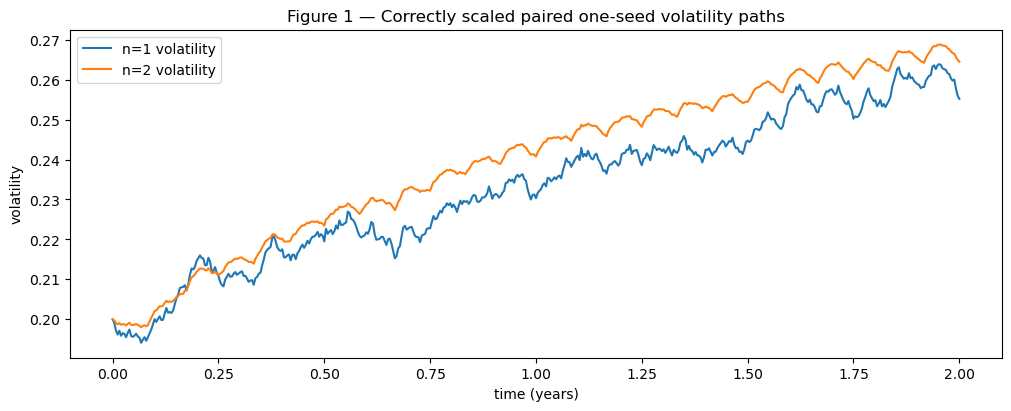

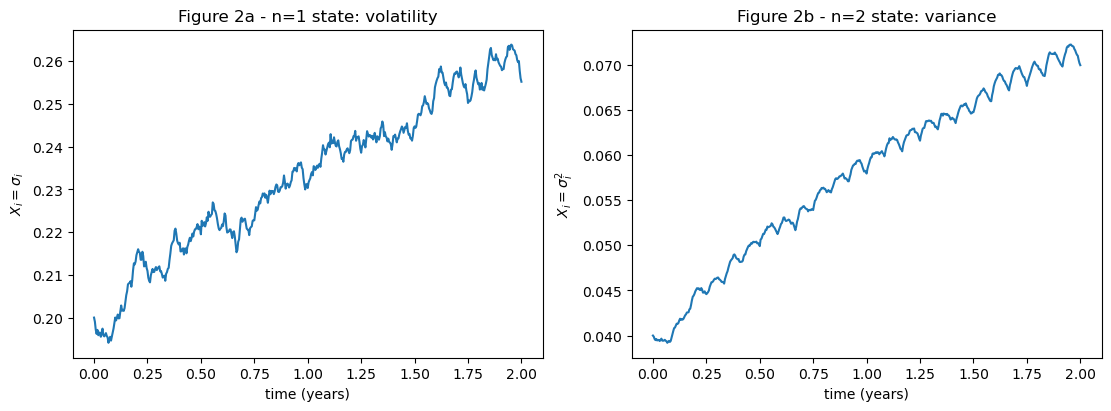

In [70]:
display(paired_simulation_diagnostics)
fig, axis = plt.subplots(figsize=(10, 4), constrained_layout=True)
axis.plot(n1_states['t'], n1_states['sigma'], label='n=1 volatility'); axis.plot(n2_states['t'], n2_states['sigma'], label='n=2 volatility')
axis.set(title='Figure 1 — Correctly scaled paired one-seed volatility paths', xlabel='time (years)', ylabel='volatility'); axis.legend(); plt.show()
fig, axes = plt.subplots(1, 2, figsize=(11, 4), constrained_layout=True)
axes[0].plot(n1_states['t'], n1_states['x']); axes[0].set(title='Figure 2a - n=1 state: volatility', xlabel='time (years)', ylabel=r'$X_i=\sigma_i$')
axes[1].plot(n2_states['t'], n2_states['x']); axes[1].set(title='Figure 2b - n=2 state: variance', xlabel='time (years)', ylabel=r'$X_i=\sigma_i^2$'); plt.show()

## One-seed n=2 full-pipeline prototype

A valid simulation is necessary but insufficient. The complete frozen workflow is now tested under the variance-state representation, including predictive structure, GC, TDMI, event-profile estimation, forecasts, intervals, and Known-DGP evaluation.

In [71]:
n2_pipeline_options = {'include_causality': True, 'include_intervals': True, 'include_truth': True}
# Truth is enabled only for evaluation after fitted forecasts have been constructed.

## Run the n=2 full pipeline

The benchmark pipeline is allowed to fail visibly if the frozen workflow is not n=2 compatible; no parameters are adjusted to rescue the run.

In [72]:
n2_prototype_result = run_full_pipeline(n2_benchmark_case, shock_bank=prototype_shock_bank, **n2_pipeline_options)
n2_prototype_summary = summarise_case(n2_prototype_result)

## Inspect the n=2 output structure

Some metrics are variance-state quantities and others are volatility-space quantities. This compact inspection records only structure and table shapes.

In [73]:
def compact_structure(result, summary):
    nested = {}
    for group in ['causality', 'evaluation', 'intervals', 'truth']:
        value = result[group]
        if isinstance(value, dict): nested[group] = {name: tuple(item.shape) for name, item in value.items() if isinstance(item, pd.DataFrame)}
    return pd.Series({'top_level_keys': ', '.join(result.keys()), 'summary_keys': len(summary), 'nested_dataframe_shapes': str(nested), 'profile_length': len(result['profiles']['nonparametric']), 'forecast_shape': result['forecasts'].shape, 'interval_table_names': ', '.join(result['intervals'].keys()), 'causality_outputs': ', '.join(result['causality'].keys())})
display(compact_structure(n2_prototype_result, n2_prototype_summary).to_frame('n=2 prototype'))

,n=2 prototype
top_level_keys,"config, timing, function_metadata, simulation,..."
summary_keys,69
nested_dataframe_shapes,"{'causality': {'gc': (2, 12), 'conditional_str..."
profile_length,13
forecast_shape,"(147, 15)"
interval_table_names,"table, coverage, summary"
causality_outputs,"gc, conditional_structure, tdmi_level_curve, t..."


## Validate the n=2 full-pipeline output

These checks establish that the frozen estimator and forecast workflow remains logically valid under $n=2$, with truth retained only for evaluation.

In [74]:
n2_profiles, n2_truth, n2_evaluation = n2_prototype_result['profiles'], n2_prototype_result['truth'], n2_prototype_result['evaluation']
assert {'simulation', 'timing', 'causality', 'baseline', 'profiles', 'forecasts', 'evaluation', 'intervals', 'truth'}.issubset(n2_prototype_result)
assert n2_truth['label'] == 'Known-DGP synthetic reference' and 'forecasts_frozen' in n2_prototype_result['pipeline_stages']
ages = np.arange(13)
assert np.isfinite(n2_profiles['parametric_multiplier'](ages)).all() and np.isfinite(n2_profiles['nonparametric'].reindex(ages)).all()
assert (n2_profiles['parametric_multiplier'](ages) > 0).all() and n2_profiles['nonparametric'].reindex(ages).gt(0).all()
assert np.array_equal(n2_prototype_result['forecasts'][['i', 'target_i']].to_numpy(), n2_prototype_result['split']['test'][['i', 'target_i']].to_numpy())
interval_table = n2_evaluation['intervals']; lower_columns = [c for c in interval_table if c.startswith('lower_')]; pairs = [(c, c.replace('lower_', 'upper_', 1)) for c in lower_columns if c.replace('lower_', 'upper_', 1) in interval_table]
assert pairs and all((interval_table[lower] <= interval_table[upper]).all() for lower, upper in pairs)
coverage = n2_prototype_summary[[c for c in n2_prototype_summary.index if c.endswith('_coverage')]].astype(float); scores = n2_prototype_summary[[c for c in n2_prototype_summary.index if c.endswith('_interval_score')]].astype(float)
assert coverage.between(0, 1).all() and (scores >= 0).all() and n2_benchmark_case['model']['n'] == 2
assert n2_benchmark_case['model'] == dedicated_n2_configuration
assert n2_benchmark_case == n2_benchmark_snapshot and dedicated_n2_configuration == dedicated_n2_snapshot

## Paired n=1 and n=2 calibration comparison

Sigma-space forecast metrics may be compared descriptively because both formulations forecast volatility, but the paired comparison does not isolate $n$: each formulation retains its own frozen calibration. Raw powered-state errors and interval scores remain in different units and are not directly comparable across the two cases.

In [75]:
n1_prototype_result = run_full_pipeline(n1_reference_case, shock_bank=prototype_shock_bank, **n2_pipeline_options)
n1_prototype_summary = summarise_case(n1_prototype_result)
n1_forecast_ids = n1_prototype_result['forecasts'][['i', 'target_i']].reset_index(drop=True)
n2_forecast_ids = n2_prototype_result['forecasts'][['i', 'target_i']].reset_index(drop=True)
common_test_rows = n1_forecast_ids.equals(n2_forecast_ids)
assert common_test_rows

paired_pipeline_comparison = pd.DataFrame([
    {
        'n': 1,
        'state_interpretation': 'n=1 state = volatility',
        'theta_state': n1_reference_case['model']['theta'],
        'implied_target_sigma': n1_reference_case['model']['theta'],
        'nu_state': n1_reference_case['model']['nu_0'],
        'local_sigma_innovation_scale': n1_reference_case['model']['nu_0'],
        'rho_0': n1_reference_case['model']['rho_0'],
        'comparison_interpretation': 'frozen n=1 volatility-state calibration',
        **{k: n1_prototype_summary[k] for k in ['A_hat', 'lambda_hat', 'parametric_profile_RMSE', 'nonparametric_profile_RMSE', 'active_sigma_parametric_MAE_gain_pct', 'active_sigma_nonparametric_MAE_gain_pct', 'active_95_state_parametric_coverage']},
        'common_test_rows': common_test_rows,
    },
    {
        'n': 2,
        'state_interpretation': 'n=2 state = variance',
        'theta_state': n2_benchmark_case['model']['theta'],
        'implied_target_sigma': n2_benchmark_case['model']['theta'] ** .5,
        'nu_state': n2_benchmark_case['model']['nu_0'],
        'local_sigma_innovation_scale': n2_benchmark_case['model']['nu_0'] / (2 * n2_benchmark_case['simulation']['sigma0']),
        'rho_0': n2_benchmark_case['model']['rho_0'],
        'comparison_interpretation': 'dedicated n=2 variance-state calibration',
        **{k: n2_prototype_summary[k] for k in ['A_hat', 'lambda_hat', 'parametric_profile_RMSE', 'nonparametric_profile_RMSE', 'active_sigma_parametric_MAE_gain_pct', 'active_sigma_nonparametric_MAE_gain_pct', 'active_95_state_parametric_coverage']},
        'common_test_rows': common_test_rows,
    },
]).rename(columns={
    'active_95_state_parametric_coverage': 'parametric_active_95_state_coverage',
})
display(paired_pipeline_comparison)

,n,state_interpretation,theta_state,implied_target_sigma,nu_state,local_sigma_innovation_scale,rho_0,comparison_interpretation,A_hat,lambda_hat,parametric_profile_RMSE,nonparametric_profile_RMSE,active_sigma_parametric_MAE_gain_pct,active_sigma_nonparametric_MAE_gain_pct,parametric_active_95_state_coverage,common_test_rows
0,1,n=1 state = volatility,0.20,0.2,0.015,0.015,-0.35,frozen n=1 volatility-state calibration,0.008406,36.086499,0.000470,0.000921,26.858510,31.524038,0.945055,True
1,2,n=2 state = variance,0.04,0.2,0.002,0.005,-0.25,dedicated n=2 variance-state calibration,0.009503,35.105045,0.000282,0.002641,71.442328,48.329824,0.934066,True


## Construct the compact n=2 result table

This table reports the main one-seed diagnostics before any repeated-seed work. Variance-state recovery, volatility forecast metrics, and state-space interval calibration remain explicitly distinguished.

In [76]:
s, gc = n2_prototype_summary, n2_prototype_result['causality']['gc']
level_gc = gc.loc[gc.target.eq('powered-state level')].iloc[0]
change_gc = gc.loc[gc.target.eq('powered-state change')].iloc[0]
conditional = n2_prototype_result['causality']['conditional_structure'].loc[lambda d: d.target.eq('state_next')].iloc[0]
known_interval = n2_truth['interval_summary'].loc[
    (n2_truth['interval_summary'].evaluation_space.eq('powered_state'))
    & (n2_truth['interval_summary'].subset.eq('active'))
    & (n2_truth['interval_summary'].nominal_coverage.eq(.95))
].iloc[0]
fields = [
    'parametric_profile_MAE', 'parametric_profile_RMSE',
    'nonparametric_profile_MAE', 'nonparametric_profile_RMSE',
    'active_sigma_unaware_MAE', 'active_sigma_unaware_RMSE',
    'active_sigma_parametric_MAE', 'active_sigma_parametric_RMSE',
    'active_sigma_nonparametric_MAE', 'active_sigma_nonparametric_RMSE',
    'active_sigma_parametric_MAE_gain_pct', 'active_sigma_parametric_RMSE_gain_pct',
    'active_sigma_nonparametric_MAE_gain_pct', 'active_sigma_nonparametric_RMSE_gain_pct',
    'active_95_state_parametric_coverage', 'active_95_state_parametric_interval_score',
    'active_95_state_nonparametric_coverage', 'active_95_state_nonparametric_interval_score',
]
row = {
    'seed': PROTOTYPE_SEED, 'case_name': 'n2_benchmark', 'n': 2, 'run_success': True,
    'common_test_rows': common_test_rows,
    'conditional_partial_r_squared': conditional.partial_r_squared,
    'conditional_p_value': conditional.p_value,
    'gc_level_selected_order': level_gc.lag_order, 'gc_level_p_value': s.gc_level_p_value,
    'gc_level_partial_r_squared': s.gc_level_partial_r_squared,
    'gc_change_selected_order': change_gc.lag_order, 'gc_change_p_value': s.gc_change_p_value,
    'gc_change_partial_r_squared': s.gc_change_partial_r_squared,
    'tdmi_level_direct_peak': s.direct_tdmi_level_peak,
    'tdmi_level_direct_peak_lag': s.direct_tdmi_level_lag,
    'tdmi_change_direct_peak': s.direct_tdmi_change_peak,
    'tdmi_change_direct_peak_lag': s.direct_tdmi_change_lag,
    'A_true': n2_benchmark_case['events']['amplitude'], 'A_hat': s.A_hat,
    'A_relative_error': (s.A_hat - n2_benchmark_case['events']['amplitude']) / n2_benchmark_case['events']['amplitude'],
    'lambda_true': n2_benchmark_case['events']['decay_rate'], 'lambda_hat': s.lambda_hat,
    'lambda_relative_error': (s.lambda_hat - n2_benchmark_case['events']['decay_rate']) / n2_benchmark_case['events']['decay_rate'],
    **{field: s[field] for field in fields},
    'known_dgp_active_state_MAE': s['known_dgp_active_state_MAE'],
    'known_dgp_active_state_RMSE': s['known_dgp_active_state_RMSE'],
    'known_dgp_active_95_state_coverage': known_interval.empirical_coverage,
    'known_dgp_active_95_state_interval_score': known_interval.mean_interval_score,
}
n2_result_table = pd.DataFrame([row]).rename(columns={
    'active_sigma_unaware_MAE': 'baseline_active_sigma_MAE',
    'active_sigma_unaware_RMSE': 'baseline_active_sigma_RMSE',
    'active_sigma_parametric_MAE': 'parametric_active_sigma_MAE',
    'active_sigma_parametric_RMSE': 'parametric_active_sigma_RMSE',
    'active_sigma_nonparametric_MAE': 'nonparametric_active_sigma_MAE',
    'active_sigma_nonparametric_RMSE': 'nonparametric_active_sigma_RMSE',
    'active_sigma_parametric_MAE_gain_pct': 'parametric_active_MAE_gain_pct',
    'active_sigma_parametric_RMSE_gain_pct': 'parametric_active_RMSE_gain_pct',
    'active_sigma_nonparametric_MAE_gain_pct': 'nonparametric_active_MAE_gain_pct',
    'active_sigma_nonparametric_RMSE_gain_pct': 'nonparametric_active_RMSE_gain_pct',
    'active_95_state_parametric_coverage': 'parametric_active_95_state_coverage',
    'active_95_state_parametric_interval_score': 'parametric_active_95_state_interval_score',
    'active_95_state_nonparametric_coverage': 'nonparametric_active_95_state_coverage',
    'active_95_state_nonparametric_interval_score': 'nonparametric_active_95_state_interval_score',
})
assert bool(n2_result_table.loc[0, 'common_test_rows'])
n2_result_display_columns = [
    'case_name', 'n', 'common_test_rows', 'conditional_partial_r_squared',
    'gc_change_p_value', 'tdmi_change_direct_peak_lag', 'A_hat', 'lambda_hat',
    'parametric_profile_RMSE', 'nonparametric_profile_RMSE',
    'parametric_active_MAE_gain_pct', 'nonparametric_active_MAE_gain_pct',
    'parametric_active_95_state_coverage', 'known_dgp_active_state_RMSE',
    'known_dgp_active_95_state_coverage',
]
assert set(n2_result_display_columns).issubset(n2_result_table.columns)
display(n2_result_table.loc[:, n2_result_display_columns])

,case_name,n,common_test_rows,conditional_partial_r_squared,gc_change_p_value,tdmi_change_direct_peak_lag,A_hat,lambda_hat,parametric_profile_RMSE,nonparametric_profile_RMSE,parametric_active_MAE_gain_pct,nonparametric_active_MAE_gain_pct,parametric_active_95_state_coverage,known_dgp_active_state_RMSE,known_dgp_active_95_state_coverage
0,n2_benchmark,2,True,0.612236,9.208326e-50,1.0,0.009503,35.105045,0.000282,0.002641,71.442328,48.329824,0.934066,0.000115,0.956044


## Representative held-out \(n=2\) event-weight recovery and volatility forecasts

This fixed held-out path makes the frozen forecasting mechanics visible. The left panel retrospectively compares the Known-DGP event-weight profile with the frozen parametric and non-parametric estimates. The right panel shows the realised next-volatility target and the three deployable forecasts in the representative active-event window. Repeated-seed MAE, RMSE and calibration results remain the primary statistical evidence.

For the variance-state formulation, the profile is the event weight in

$$
X_{i+1}=\omega_{i+1}F_i,
\qquad
\sigma_{i+1}=\sqrt{\omega_{i+1}F_i}.
$$

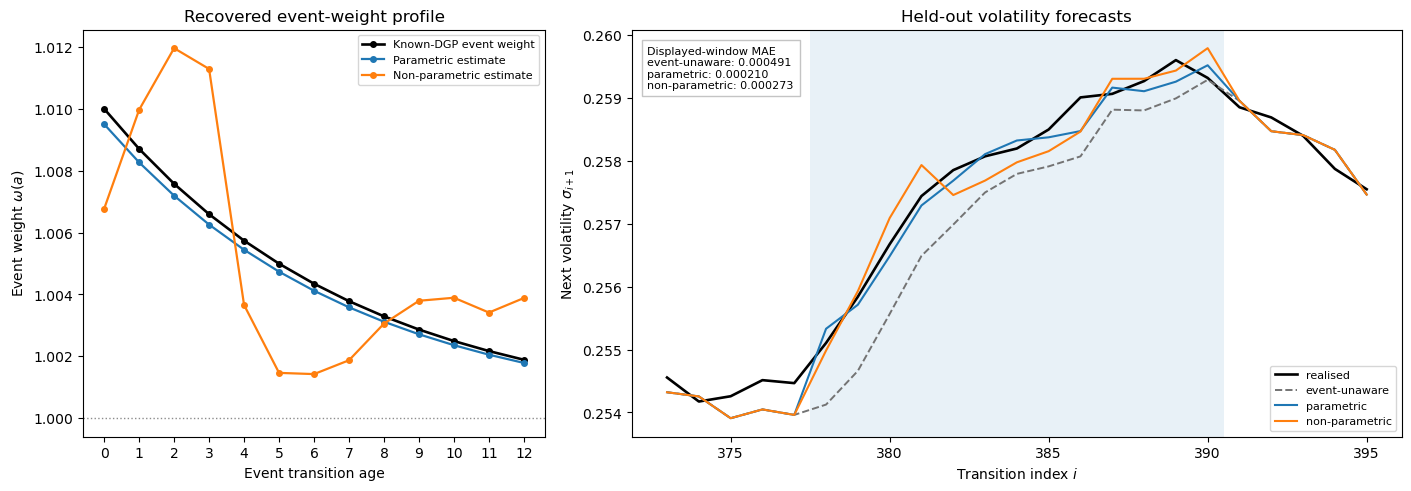

Dedicated n=2 prototype seed: 20260721; held-out transition range: 373 to 395.


In [77]:
# Align frozen forecasts with the realised held-out target solely for visual evaluation.
n2_output_path = (
    n2_prototype_result["forecasts"]
    .merge(
        n2_prototype_result["split"]["test"][["i", "target_i", "sigma_next"]],
        on=["i", "target_i"], validate="one_to_one",
    )
    .rename(columns={"i": "transition_i"})
)
n2_forecast_plot_columns = {
    "event-unaware": "sigma_forecast_unaware",
    "parametric": "sigma_forecast_parametric",
    "non-parametric": "sigma_forecast_nonparametric",
}
n2_forecast_window = n2_output_path.loc[
    n2_output_path["transition_i"].between(373, 395)
].copy()

# The forecast inputs exclude hidden DGP quantities; the truth profile below is evaluation-only.
for forbidden_input in ["true_omega", "eta", "epsilon", "alpha", "nu", "rho"]:
    assert forbidden_input not in n2_prototype_result["forecast_inputs"]

forecast_columns = [
    "state_forecast_unaware",
    "state_forecast_parametric",
    "state_forecast_nonparametric",
]
assert n2_forecast_window[forecast_columns].ge(0.0).all().all()
assert np.allclose(
    n2_forecast_window["sigma_forecast_unaware"].to_numpy(),
    np.sqrt(n2_forecast_window["state_forecast_unaware"].to_numpy()),
)
assert np.allclose(
    n2_forecast_window["sigma_forecast_parametric"].to_numpy(),
    np.sqrt(n2_forecast_window["state_forecast_parametric"].to_numpy()),
)
assert np.allclose(
    n2_forecast_window["sigma_forecast_nonparametric"].to_numpy(),
    np.sqrt(n2_forecast_window["state_forecast_nonparametric"].to_numpy()),
)
assert n2_output_path["transition_i"].is_unique
assert n2_forecast_window["transition_i"].isin(n2_output_path["transition_i"]).all()
assert n2_forecast_window["transition_i"].to_list() == list(range(373, 396))
assert n2_forecast_window.shape[0] == 23
assert int(n2_forecast_window["event_active_i"].sum()) == 13
assert n2_forecast_window.loc[
    n2_forecast_window["event_active_i"].eq(1), "event_age_i"
].astype(int).to_list() == list(range(13))

profile_ages = np.arange(13)
profile_n = n2_benchmark_case["model"]["n"]
true_state_multiplier = (
    n2_prototype_result["truth"]["table"]
    .loc[lambda data: data["event_active_i"].eq(1)]
    .groupby("event_age_i")["m_true"]
    .mean()
    .reindex(profile_ages)
)
parametric_state_multiplier = pd.Series(
    n2_profiles["parametric_multiplier"](profile_ages), index=profile_ages
)
nonparametric_state_multiplier = n2_profiles["nonparametric"].reindex(profile_ages)

# Known-DGP weights are accessed only for this retrospective visual comparison.
true_event_weight = true_state_multiplier.pow(2.0 / profile_n)
parametric_event_weight = parametric_state_multiplier.pow(2.0 / profile_n)
nonparametric_event_weight = nonparametric_state_multiplier.pow(2.0 / profile_n)

expected_profile_index = pd.Index(profile_ages)
for profile in [
    true_state_multiplier,
    parametric_state_multiplier,
    nonparametric_state_multiplier,
    true_event_weight,
    parametric_event_weight,
    nonparametric_event_weight,
]:
    assert profile.index.equals(expected_profile_index)
    assert profile.notna().all()
    assert np.isfinite(profile.to_numpy()).all()
    assert profile.gt(0.0).all()
assert np.array_equal(profile_ages, np.arange(13))
assert profile_n == 2
assert np.allclose(
    parametric_state_multiplier.to_numpy(),
    n2_profiles["parametric_multiplier"](profile_ages),
)
assert nonparametric_state_multiplier.equals(
    n2_profiles["nonparametric"].reindex(profile_ages)
)

fig, axes = plt.subplots(
    1,
    2,
    figsize=(14.0, 4.8),
    constrained_layout=True,
    gridspec_kw={"width_ratios": [0.9, 1.5]},
)
profile_axis, forecast_axis = axes

profile_axis.plot(
    profile_ages, true_event_weight, color="black", linewidth=1.9,
    marker="o", markersize=4, label="Known-DGP event weight",
)
profile_axis.plot(
    profile_ages, parametric_event_weight, color="#1f77b4", linewidth=1.6,
    marker="o", markersize=4, label="Parametric estimate",
)
profile_axis.plot(
    profile_ages, nonparametric_event_weight, color="#ff7f0e", linewidth=1.6,
    marker="o", markersize=4, label="Non-parametric estimate",
)
profile_axis.axhline(1.0, color="0.55", linestyle=":", linewidth=1.0)
profile_axis.set(
    title="Recovered event-weight profile",
    xlabel="Event transition age",
    ylabel="Event weight $\\omega(a)$",
    xticks=profile_ages,
)
profile_axis.legend(loc="upper right", fontsize=8)

for transition_i in n2_forecast_window.loc[
    n2_forecast_window["event_active_i"].eq(1), "transition_i"
]:
    forecast_axis.axvspan(
        transition_i - 0.5, transition_i + 0.5,
        color="#1f77b4", alpha=0.10, linewidth=0,
    )
forecast_axis.plot(
    n2_forecast_window["transition_i"], n2_forecast_window["sigma_next"],
    color="black", linewidth=1.9, label="realised",
)
forecast_axis.plot(
    n2_forecast_window["transition_i"], n2_forecast_window["sigma_forecast_unaware"],
    color="0.45", linestyle="--", linewidth=1.4, label="event-unaware",
)
forecast_axis.plot(
    n2_forecast_window["transition_i"], n2_forecast_window["sigma_forecast_parametric"],
    color="#1f77b4", linewidth=1.5, label="parametric",
)
forecast_axis.plot(
    n2_forecast_window["transition_i"], n2_forecast_window["sigma_forecast_nonparametric"],
    color="#ff7f0e", linewidth=1.5, label="non-parametric",
)
n2_displayed_window_mae = {
    label: float(np.mean(np.abs(
        n2_forecast_window["sigma_next"].to_numpy()
        - n2_forecast_window[column].to_numpy()
    )))
    for label, column in n2_forecast_plot_columns.items()
}
mae_text = "Displayed-window MAE\n" + "\n".join(
    f"{label}: {value:.6f}" for label, value in n2_displayed_window_mae.items()
)
forecast_axis.text(
    0.02, 0.96, mae_text, transform=forecast_axis.transAxes, va="top", ha="left",
    fontsize=8, bbox={"facecolor": "white", "edgecolor": "0.75", "alpha": 0.92},
)
forecast_axis.set(
    title="Held-out volatility forecasts",
    xlabel="Transition index $i$",
    ylabel="Next volatility $\\sigma_{i+1}$",
)
forecast_axis.legend(loc="lower right", fontsize=8)

plt.show()

for label, expected_mae in n2_displayed_window_mae.items():
    observed_mae = float(np.mean(np.abs(
        n2_forecast_window["sigma_next"].to_numpy()
        - n2_forecast_window[n2_forecast_plot_columns[label]].to_numpy()
    )))
    assert np.isclose(observed_mae, expected_mae)
assert int(n2_forecast_window["event_active_i"].sum()) == 13
assert n2_forecast_window.shape[0] == 23
print(
    "Dedicated n=2 prototype seed: 20260721; held-out transition range: "
    "373 to 395."
)

The powered-state forecast is $\widehat{X}_{i+1}=\widehat{q}_{i+1}\widehat{F}_i$, with $q=\omega^{n/2}$, followed by $\widehat{\sigma}_{i+1}=\widehat{X}_{i+1}^{1/n}$. Thus for $n=2$, $\widehat{\sigma}^{U}_{i+1}=\sqrt{\widehat{F}_i}$, $\widehat{\sigma}^{P}_{i+1}=\sqrt{\widehat{\omega}^{P}(a_i)\widehat{F}_i}$, and $\widehat{\sigma}^{NP}_{i+1}=\sqrt{\widehat{\omega}^{NP}(a_i)\widehat{F}_i}$. Both event-aware forecasts share the same background forecast and differ only through their fitted event-weight profiles.

Outside active event periods, $\widehat{\omega}=1$, so the three forecasts coincide or nearly coincide. The profile comparison is an evaluation-only check against synthetic truth; it does not enter fitting or forecasting. The apparent differences are intentionally small because volatility persistence already makes the background forecast strong. This one-path illustration does not establish that $n=2$ is superior to $n=1$; the repeated-seed results remain the main robustness evidence.

## One-seed findings and limitations

### Numerical and pipeline validity

The corrected simulation satisfied $X_i=\sigma_i^2$ with maximum absolute error $1.39\times10^{-17}$, and $X_{i+1}=\omega_{i+1}F_i$ had zero stored-transition error. Timing, positivity, common-shock and common-test-row checks passed, and the full frozen pipeline completed. Known-DGP quantities were used only after the fitted objects and forecasts were frozen, for retrospective evaluation.

### Event-weight recovery and forecasting

For this one seed, $\widehat A=0.009503$ and $\widehat\lambda=35.105$, against $A=0.01$ and $\lambda=35$. Parametric and non-parametric event-profile RMSE were $0.000282$ and $0.000583$. On active transitions, their sigma-space MAE gains were $71.44\%$ and $72.13\%$, respectively. Both event-aware methods had active 95% powered-state coverage of $93.41\%$, with mean interval scores $0.000544$ and $0.000578$. The combined figure is a one-path illustration; repeated-seed evidence is required before drawing robustness conclusions.

### Interpretation and limitations

The dedicated $n=1$ and $n=2$ calibrations differ in more than the exponent, including local volatility innovation scale, $\rho_0$, powered-state dynamics and the finite-sample realisation. The one-seed comparison therefore does not isolate the effect of changing $n$. Raw powered-state errors and interval scores are not directly comparable across $n=1$ and $n=2$ because their state units differ. The dense deterministic event calendar and synthetic design are further limitations; GC and TDMI remain predictive/dependence diagnostics rather than structural-causality proof.

## Repeated-seed dedicated-calibration analysis

The one-seed prototype establishes implementation validity but cannot establish statistical reliability. This stage runs $50$ seeds across the frozen n=1 and dedicated n=2 calibrations, giving $100$ full-pipeline runs. Within each seed, both calibrations use the exact same $\epsilon_i$, $\eta_i$, event schedule, simulation length, and forecast rows. This is a paired comparison of dedicated calibrations, not an n-only experiment: $\theta$, $\nu_0$, and $\rho_0$ also differ.

## Seed plan and execution controls

Fifty seeds provide an initial Monte Carlo assessment consistent with Notebook 08. Checkpoints are overwritten after each completed seed, so an interruption preserves all accumulated compact outputs without retaining full pipeline objects.

In [78]:
from pathlib import Path
from time import perf_counter

MASTER_SEED = 20260721
N_REPLICATION_SEEDS = 50
REPLICATION_SEEDS = list(range(MASTER_SEED, MASTER_SEED + N_REPLICATION_SEEDS))
RESULTS_DIR = Path("notebook09_results")
RESULTS_DIR.mkdir(exist_ok=True)
FIGURES_DIR = RESULTS_DIR / "figures"
FIGURES_DIR.mkdir(exist_ok=True)
RUN_N2_REPLICATION = False
RUN_CHECKPOINT_PATH = RESULTS_DIR / "repeated_run_level_checkpoint.csv"
PROFILE_CHECKPOINT_PATH = RESULTS_DIR / "repeated_event_profile_checkpoint.csv"
FAILURE_CHECKPOINT_PATH = RESULTS_DIR / "repeated_failure_checkpoint.csv"
assert len(REPLICATION_SEEDS) == 50

## Repeated-run outputs and compact extraction

The experiment stores one run-level row per seed and calibration, 39 event-profile rows per successful run ($13$ ages by three methods), and one explicit failure row per failed run. If all runs succeed, this yields 100 run rows and 3,900 profile rows.

In [79]:
def extract_repeated_run_summary(result, summary, case_config, case_name, calibration_interpretation, seed, common_test_rows, seed_pair_runtime_seconds):
    model, events, n = case_config['model'], case_config['events'], case_config['model']['n']
    gc = result['causality']['gc'].set_index('target')
    conditional = result['causality']['conditional_structure'].set_index('target')
    truth_intervals = result['truth']['interval_summary']
    known = truth_intervals.loc[(truth_intervals.evaluation_space.eq('powered_state')) & (truth_intervals.subset.eq('active')) & (truth_intervals.nominal_coverage.eq(.95))].iloc[0]
    get_gc = lambda target, field: float(gc.loc[target, field]) if target in gc.index else np.nan
    rename = {'active_sigma_unaware_MAE':'baseline_active_sigma_MAE','active_sigma_unaware_RMSE':'baseline_active_sigma_RMSE','active_sigma_parametric_MAE':'parametric_active_sigma_MAE','active_sigma_parametric_RMSE':'parametric_active_sigma_RMSE','active_sigma_nonparametric_MAE':'nonparametric_active_sigma_MAE','active_sigma_nonparametric_RMSE':'nonparametric_active_sigma_RMSE','active_sigma_parametric_MAE_gain_pct':'parametric_active_MAE_gain_pct','active_sigma_parametric_RMSE_gain_pct':'parametric_active_RMSE_gain_pct','active_sigma_nonparametric_MAE_gain_pct':'nonparametric_active_MAE_gain_pct','active_sigma_nonparametric_RMSE_gain_pct':'nonparametric_active_RMSE_gain_pct'}
    values = {rename.get(k, k): v for k, v in summary.items()}
    values.update({
        'parametric_active_95_state_coverage': summary['active_95_state_parametric_coverage'],
        'parametric_active_95_state_interval_score': summary['active_95_state_parametric_interval_score'],
        'nonparametric_active_95_state_coverage': summary['active_95_state_nonparametric_coverage'],
        'nonparametric_active_95_state_interval_score': summary['active_95_state_nonparametric_interval_score'],
    })
    return {'seed':seed,'case_name':case_name,'n':n,'state_interpretation':'volatility' if n == 1 else 'variance','calibration_interpretation':calibration_interpretation,'run_success':True,'profile_converged':bool(summary['profile_converged']),'common_test_rows':common_test_rows,'failure_stage':'','exception_type':'','failure_message':'','seed_pair_runtime_seconds':seed_pair_runtime_seconds,'theta_state':model['theta'],'implied_target_sigma':model['theta'] ** (1/n),'nu_state':model['nu_0'],'local_sigma_innovation_scale':model['nu_0']/(n*case_config['simulation']['sigma0']**(n-1)),'rho_0':model['rho_0'],'event_amplitude':events['amplitude'],'event_decay_rate':events['decay_rate'],'conditional_partial_r_squared':float(conditional.loc['state_next','partial_r_squared']),'conditional_p_value':float(conditional.loc['state_next','p_value']),'gc_forward_level_p_value':get_gc('powered-state level','p_value'),'gc_forward_level_partial_r_squared':get_gc('powered-state level','partial_R_squared'),'gc_forward_change_p_value':get_gc('powered-state change','p_value'),'gc_forward_change_partial_r_squared':get_gc('powered-state change','partial_R_squared'),'gc_reverse_level_p_value':np.nan,'gc_reverse_level_partial_r_squared':np.nan,'gc_reverse_change_p_value':np.nan,'gc_reverse_change_partial_r_squared':np.nan,'tdmi_level_direct_peak':values['direct_tdmi_level_peak'],'tdmi_level_direct_peak_lag':values['direct_tdmi_level_lag'],'tdmi_change_direct_peak':values['direct_tdmi_change_peak'],'tdmi_change_direct_peak_lag':values['direct_tdmi_change_lag'],'A_true':events['amplitude'],'A_hat':values['A_hat'],'A_relative_error':(values['A_hat']-events['amplitude'])/events['amplitude'],'lambda_true':events['decay_rate'],'lambda_hat':values['lambda_hat'],'lambda_relative_error':(values['lambda_hat']-events['decay_rate'])/events['decay_rate'],'known_dgp_active_95_state_coverage':float(known.empirical_coverage),'known_dgp_active_95_state_interval_score':float(known.mean_interval_score),**{k:values.get(k,np.nan) for k in ['parametric_profile_MAE','parametric_profile_RMSE','nonparametric_profile_MAE','nonparametric_profile_RMSE','baseline_active_sigma_MAE','baseline_active_sigma_RMSE','parametric_active_sigma_MAE','parametric_active_sigma_RMSE','nonparametric_active_sigma_MAE','nonparametric_active_sigma_RMSE','parametric_active_MAE_gain_pct','parametric_active_RMSE_gain_pct','nonparametric_active_MAE_gain_pct','nonparametric_active_RMSE_gain_pct','parametric_active_95_state_coverage','parametric_active_95_state_interval_score','nonparametric_active_95_state_coverage','nonparametric_active_95_state_interval_score','known_dgp_active_state_MAE','known_dgp_active_state_RMSE']}}

def extract_repeated_profile_rows(result, case_config, case_name, seed):
    n, ages = case_config['model']['n'], np.arange(13)
    truth_state = result['truth']['table'].loc[lambda d:d.event_active_i.eq(1)].groupby('event_age_i').m_true.mean().reindex(ages)
    profiles = result['profiles']; methods = {'truth':truth_state,'parametric':pd.Series(profiles['parametric_multiplier'](ages),index=ages),'nonparametric':profiles['nonparametric'].reindex(ages)}
    rows=[]
    for method, series in methods.items():
        for age, powered_state_multiplier in series.items():
            event_weight=float(powered_state_multiplier ** (2/n))
            rows.append({'seed':seed,'case_name':case_name,'n':n,'state_interpretation':'volatility' if n==1 else 'variance','event_age':int(age),'profile_method':method,'event_weight':event_weight,'state_multiplier':float(event_weight ** (n/2)),'volatility_multiplier':float(np.sqrt(event_weight))})
    return rows

def write_repeated_checkpoints(rows, profiles, failures):
    pd.DataFrame(rows).to_csv(RUN_CHECKPOINT_PATH,index=False); pd.DataFrame(profiles).to_csv(PROFILE_CHECKPOINT_PATH,index=False)
    pd.DataFrame(failures,columns=['seed','case_name','n','failure_stage','exception_type','failure_message','seed_pair_runtime_seconds']).to_csv(FAILURE_CHECKPOINT_PATH,index=False)

## Execute the paired 50-seed experiment

The frozen n=1 calibration runs first within each seed and supplies the ordered forecast identifiers used to validate the n=2 run. Failures are recorded honestly and the remaining seeds continue; only compact extracted records are retained.

In [80]:
repeated_rows, repeated_profile_rows, repeated_failure_rows = [], [], []
case_plan = [('n1_reference', n1_reference_case, 'frozen n=1 volatility-state calibration'), ('n2_benchmark', n2_benchmark_case, 'dedicated n=2 variance-state calibration')]
if RUN_N2_REPLICATION:
    experiment_started = perf_counter()
    for seed_position, seed in enumerate(REPLICATION_SEEDS, start=1):
        seed_started, completed, failures = perf_counter(), {}, {}
        try:
            shock_bank = make_shock_bank(n1_reference_case, seed=seed)
        except Exception as exc:
            failures = {case_name:(case_config, interpretation, 'shock bank', exc) for case_name,case_config,interpretation in case_plan}
        else:
            for case_name, case_config, interpretation in case_plan:
                try:
                    result = run_full_pipeline(case_config, shock_bank=shock_bank, **n2_pipeline_options)
                    completed[case_name] = (result, summarise_case(result), case_config, interpretation)
                except Exception as exc:
                    failures[case_name] = (case_config, interpretation, f'{case_name} pipeline or summary', exc)
            common_test_rows = np.nan
            if set(completed) == {'n1_reference','n2_benchmark'}:
                try:
                    n1_result, n2_result = completed['n1_reference'][0], completed['n2_benchmark'][0]
                    common_test_rows = n1_result['forecasts'][['i','target_i']].reset_index(drop=True).equals(n2_result['forecasts'][['i','target_i']].reset_index(drop=True)); assert common_test_rows
                    for column in ['epsilon','eta','event','i','target_i']: assert np.array_equal(n1_result['simulation']['transitions'][column].to_numpy(), n2_result['simulation']['transitions'][column].to_numpy())
                    assert len(n1_result['simulation']['transitions']) == len(n2_result['simulation']['transitions'])
                except Exception as exc:
                    _, _, case_config, interpretation = completed.pop('n2_benchmark')
                    failures['n2_benchmark'] = (case_config, interpretation, 'paired validation', exc)
            for case_name, (result, summary, case_config, interpretation) in completed.items():
                try:
                    elapsed = perf_counter() - seed_started
                    run_row = extract_repeated_run_summary(result, summary, case_config, case_name, interpretation, seed, common_test_rows, elapsed)
                    profile_rows = extract_repeated_profile_rows(result, case_config, case_name, seed)
                except Exception as exc:
                    failures[case_name] = (case_config, interpretation, f'{case_name} extraction', exc)
                else:
                    repeated_rows.append(run_row)
                    repeated_profile_rows.extend(profile_rows)
        for case_name,(case_config,interpretation,failure_stage,exc) in failures.items():
            elapsed = perf_counter()-seed_started
            repeated_rows.append({'seed':seed,'case_name':case_name,'n':case_config['model']['n'],'state_interpretation':'volatility' if case_config['model']['n']==1 else 'variance','calibration_interpretation':interpretation,'run_success':False,'common_test_rows':np.nan,'failure_stage':failure_stage,'exception_type':type(exc).__name__,'failure_message':str(exc),'seed_pair_runtime_seconds':elapsed})
            repeated_failure_rows.append({'seed':seed,'case_name':case_name,'n':case_config['model']['n'],'failure_stage':failure_stage,'exception_type':type(exc).__name__,'failure_message':str(exc),'seed_pair_runtime_seconds':elapsed})
        write_repeated_checkpoints(repeated_rows,repeated_profile_rows,repeated_failure_rows)
        print(f'Completed seed {seed_position}/50 | successful runs: {sum(row.get("run_success",False) for row in repeated_rows)}/{len(repeated_rows)} | elapsed: {perf_counter()-experiment_started:.1f}s')
    repeated_results,repeated_profiles,repeated_failures=pd.DataFrame(repeated_rows),pd.DataFrame(repeated_profile_rows),pd.DataFrame(repeated_failure_rows)
else:
    missing=[path for path in [RUN_CHECKPOINT_PATH,PROFILE_CHECKPOINT_PATH,FAILURE_CHECKPOINT_PATH] if not path.exists()]
    if missing: raise FileNotFoundError(f'Checkpoint-loading mode requires: {missing}')
    repeated_results,repeated_profiles,repeated_failures=pd.read_csv(RUN_CHECKPOINT_PATH),pd.read_csv(PROFILE_CHECKPOINT_PATH),pd.read_csv(FAILURE_CHECKPOINT_PATH)
for frame in [repeated_results, repeated_failures]:
    if 'run_runtime_seconds' in frame: frame.rename(columns={'run_runtime_seconds':'seed_pair_runtime_seconds'},inplace=True)
if 'seed_pair_runtime_seconds' not in repeated_failures: repeated_failures['seed_pair_runtime_seconds']=np.nan
repeated_profiles['state_multiplier']=repeated_profiles['event_weight'] ** (repeated_profiles['n']/2)
repeated_profiles['volatility_multiplier']=np.sqrt(repeated_profiles['event_weight'])

## Finalise and export the repeated raw outputs

These tidy tables are the primary repeated-seed evidence. They retain every attempted seed-calibration run and are exported without complete pipeline dictionaries.

In [81]:
repeated_results = repeated_results.sort_values(['seed','case_name']).reset_index(drop=True)
repeated_profiles = repeated_profiles.sort_values(['seed','case_name','profile_method','event_age']).reset_index(drop=True)
repeated_failures = repeated_failures.sort_values(['seed','case_name']).reset_index(drop=True) if len(repeated_failures) else repeated_failures
repeated_results.to_csv(RUN_CHECKPOINT_PATH,index=False); repeated_profiles.to_csv(PROFILE_CHECKPOINT_PATH,index=False); repeated_failures.to_csv(FAILURE_CHECKPOINT_PATH,index=False)
repeated_results.to_csv(RESULTS_DIR/'notebook09_repeated_run_level_results.csv',index=False)
repeated_profiles.to_csv(RESULTS_DIR/'notebook09_repeated_event_profiles.csv',index=False)
repeated_failures.to_csv(RESULTS_DIR/'notebook09_repeated_failures.csv',index=False)

## Validate repeated-experiment completeness

These checks establish implementation completeness before substantive interpretation: every planned paired run, profile cell, and preserved failure record must be accounted for.

In [82]:
assert len(repeated_results) == 100 and not repeated_results.duplicated(['seed','case_name']).any()
assert repeated_results.groupby('seed').size().eq(2).all() and repeated_results.case_name.eq('n1_reference').sum() == 50 and repeated_results.case_name.eq('n2_benchmark').sum() == 50
successful = repeated_results.loc[repeated_results.run_success.eq(True)].copy(); successful_run_count = int(len(successful)); expected_profile_rows = successful_run_count * 13 * 3
assert successful.loc[successful.case_name.eq('n2_benchmark'),'common_test_rows'].eq(True).all()
assert successful['profile_converged'].eq(True).all()
finite_fields=['A_hat','lambda_hat','parametric_profile_RMSE','nonparametric_profile_RMSE','parametric_active_sigma_MAE','nonparametric_active_sigma_MAE']; assert np.isfinite(successful[finite_fields].to_numpy(float)).all()
coverage_fields=[c for c in successful if c.endswith('_coverage')]; assert successful[coverage_fields].apply(lambda s:s.dropna().between(0,1).all()).all()
score_fields=[c for c in successful if c.endswith('_interval_score')]; assert successful[score_fields].apply(lambda s:s.dropna().ge(0).all()).all()
assert np.allclose(repeated_profiles['state_multiplier'], repeated_profiles['event_weight'] ** (repeated_profiles['n']/2), rtol=0, atol=1e-12)
assert np.allclose(repeated_profiles['volatility_multiplier'], np.sqrt(repeated_profiles['event_weight']), rtol=0, atol=1e-12)
n1_profiles=repeated_profiles.loc[repeated_profiles.n.eq(1)]; n2_profiles=repeated_profiles.loc[repeated_profiles.n.eq(2)]
assert np.allclose(n1_profiles['state_multiplier'],n1_profiles['volatility_multiplier'],rtol=0,atol=1e-12)
assert np.allclose(n2_profiles['state_multiplier'],n2_profiles['event_weight'],rtol=0,atol=1e-12)
assert len(repeated_profiles) == expected_profile_rows and not repeated_profiles.duplicated(['seed','case_name','event_age','profile_method']).any()
assert set(repeated_profiles.event_age)==set(range(13)) and set(repeated_profiles.profile_method)=={'truth','parametric','nonparametric'} and repeated_profiles[['event_weight','state_multiplier','volatility_multiplier']].gt(0).all().all()
completeness_table=pd.DataFrame([{'planned_seeds':50,'planned_runs':100,'attempted_runs':len(repeated_results),'successful_runs':successful_run_count,'failed_runs':len(repeated_results)-successful_run_count,'success_rate':successful_run_count/100,'profile_rows':len(repeated_profiles)}]); display(completeness_table)
if len(repeated_failures): display(repeated_failures)

,planned_seeds,planned_runs,attempted_runs,successful_runs,failed_runs,success_rate,profile_rows
0,50,100,100,100,0,1.0,3900


## Define derived repeated-seed metrics

Binary detection indicators, timing recovery, forecast improvements, and coverage errors are derived from the stored compact metrics. These transformations do not rerun or alter either model.

In [83]:
analysis_results = repeated_results.copy()
mask = analysis_results.run_success.eq(True)
analysis_results['gc_forward_change_detected_5pct'] = np.where(
    mask & analysis_results['gc_forward_change_p_value'].notna(),
    analysis_results['gc_forward_change_p_value'] < .05,
    np.nan,
)
analysis_results['tdmi_change_peak_at_plus_1'] = np.where(mask, analysis_results['tdmi_change_direct_peak_lag'].eq(1), np.nan)
analysis_results['parametric_positive_MAE_gain'] = np.where(mask, analysis_results['parametric_active_MAE_gain_pct'].gt(0), np.nan)
analysis_results['nonparametric_positive_MAE_gain'] = np.where(mask, analysis_results['nonparametric_active_MAE_gain_pct'].gt(0), np.nan)
for model in ['parametric','nonparametric','known_dgp']:
    analysis_results[f'{model}_95_state_coverage_error'] = (analysis_results[f'{model}_active_95_state_coverage']-.95).abs()

## Define uncertainty-summary helpers

Numeric means use Student-$t$ Monte Carlo intervals, binary rates use Wilson intervals, and paired differences retain same-seed pairing. These intervals describe variation over the 50 synthetic shock realisations, not uncertainty in real-market parameters.

In [84]:
from scipy.stats import t, norm

def summarise_numeric_series(series):
    values=np.asarray(pd.Series(series).dropna(),float); count=len(values)
    if not count: return dict.fromkeys(['count','mean','standard_deviation','monte_carlo_standard_error','ci_95_lower','ci_95_upper','median','q05','q25','q75','q95'],np.nan)
    sd=float(np.std(values,ddof=1)) if count>1 else 0.; se=sd/np.sqrt(count); half=t.ppf(.975,count-1)*se if count>1 else 0.
    return {'count':count,'mean':float(values.mean()),'standard_deviation':sd,'monte_carlo_standard_error':se,'ci_95_lower':float(values.mean()-half),'ci_95_upper':float(values.mean()+half),'median':float(np.median(values)),'q05':float(np.quantile(values,.05)),'q25':float(np.quantile(values,.25)),'q75':float(np.quantile(values,.75)),'q95':float(np.quantile(values,.95))}

def wilson_interval(successes,count):
    if not count: return (np.nan,np.nan)
    z=norm.ppf(.975); p=successes/count; denominator=1+z*z/count; centre=(p+z*z/(2*count))/denominator; half=z*np.sqrt(p*(1-p)/count+z*z/(4*count*count))/denominator
    return (float(centre-half),float(centre+half))

def summarise_binary_series(series):
    values=pd.Series(series).dropna().astype(bool); count=len(values); successes=int(values.sum()); lo,hi=wilson_interval(successes,count)
    return {'count':count,'successes':successes,'rate':successes/count if count else np.nan,'ci_95_lower':lo,'ci_95_upper':hi}

## Build calibration-level numeric summaries

Each dedicated calibration is summarised independently over its successful seeds. The resulting comparison is descriptive because the calibrations differ beyond their powered-state exponent.

In [85]:
group_columns=['case_name','n','state_interpretation','calibration_interpretation']
numeric_metrics=['conditional_partial_r_squared','gc_forward_level_partial_r_squared','gc_forward_change_partial_r_squared','tdmi_level_direct_peak','tdmi_change_direct_peak','A_hat','A_relative_error','lambda_hat','lambda_relative_error','parametric_profile_MAE','parametric_profile_RMSE','nonparametric_profile_MAE','nonparametric_profile_RMSE','baseline_active_sigma_MAE','baseline_active_sigma_RMSE','parametric_active_sigma_MAE','parametric_active_sigma_RMSE','nonparametric_active_sigma_MAE','nonparametric_active_sigma_RMSE','parametric_active_MAE_gain_pct','parametric_active_RMSE_gain_pct','nonparametric_active_MAE_gain_pct','nonparametric_active_RMSE_gain_pct','parametric_active_95_state_coverage','parametric_95_state_coverage_error','parametric_active_95_state_interval_score','nonparametric_active_95_state_coverage','nonparametric_95_state_coverage_error','nonparametric_active_95_state_interval_score','known_dgp_active_95_state_coverage','known_dgp_95_state_coverage_error','known_dgp_active_95_state_interval_score','known_dgp_active_state_MAE','known_dgp_active_state_RMSE']
calibration_numeric_summary=pd.DataFrame([{**dict(zip(group_columns,keys)),'metric':metric,**summarise_numeric_series(group[metric])} for keys,group in analysis_results.loc[mask].groupby(group_columns) for metric in numeric_metrics if metric in group])
calibration_numeric_summary.to_csv(RESULTS_DIR/'notebook09_calibration_numeric_summary.csv',index=False)

## Build detection and timing summaries

Rejection frequency is interpreted alongside effect size. GC and TDMI remain predictive and dependence diagnostics, not proof of interventionist causality. The frozen reusable workflow returns forward historical-GC results only. Reverse-GC behaviour is therefore not estimated or displayed in this repeated-seed section and will be examined explicitly in later event-schedule or method-comparison notebooks.

In [86]:
rate_metrics=['gc_forward_change_detected_5pct','tdmi_change_peak_at_plus_1','parametric_positive_MAE_gain','nonparametric_positive_MAE_gain']
calibration_rate_summary=pd.DataFrame([{**dict(zip(group_columns,keys)),'metric':metric,**summarise_binary_series(group[metric])} for keys,group in analysis_results.loc[mask].groupby(group_columns) for metric in rate_metrics])
calibration_rate_summary.to_csv(RESULTS_DIR/'notebook09_calibration_rate_summary.csv',index=False)

## Build same-seed paired contrasts

For each comparable metric, $D_s=M_{s,n=2}-M_{s,n=1}$ compares the two dedicated calibrations under the same seed and shock bank. These paired contrasts do not isolate the exponent because the calibrations also differ in state-scale parameters.

In [87]:
paired_metrics=['conditional_partial_r_squared','gc_forward_level_partial_r_squared','gc_forward_change_partial_r_squared','tdmi_level_direct_peak','tdmi_change_direct_peak','A_relative_error','lambda_relative_error','parametric_profile_RMSE','nonparametric_profile_RMSE','baseline_active_sigma_MAE','baseline_active_sigma_RMSE','parametric_active_sigma_MAE','parametric_active_sigma_RMSE','nonparametric_active_sigma_MAE','nonparametric_active_sigma_RMSE','parametric_active_MAE_gain_pct','parametric_active_RMSE_gain_pct','nonparametric_active_MAE_gain_pct','nonparametric_active_RMSE_gain_pct','parametric_95_state_coverage_error','nonparametric_95_state_coverage_error']
paired_wide=analysis_results.loc[mask].pivot(index='seed',columns='case_name',values=paired_metrics)
assert len(paired_wide)==50 and paired_wide.notna().all().all()
paired_calibration_contrasts_raw=pd.concat([pd.DataFrame({'seed':paired_wide.index,'metric':metric,'n1_value':paired_wide[(metric,'n1_reference')].to_numpy(),'n2_value':paired_wide[(metric,'n2_benchmark')].to_numpy(),'paired_difference_n2_minus_n1':(paired_wide[(metric,'n2_benchmark')]-paired_wide[(metric,'n1_reference')]).to_numpy()}) for metric in paired_metrics],ignore_index=True)
paired_calibration_contrast_summary=pd.DataFrame([{'metric':metric,**{('mean_difference' if k=='mean' else 'median_difference' if k=='median' else k):v for k,v in summarise_numeric_series(group.paired_difference_n2_minus_n1).items()}} for metric,group in paired_calibration_contrasts_raw.groupby('metric')])
paired_calibration_contrasts_raw.to_csv(RESULTS_DIR/'notebook09_paired_calibration_contrasts_raw.csv',index=False); paired_calibration_contrast_summary.to_csv(RESULTS_DIR/'notebook09_paired_calibration_contrast_summary.csv',index=False)

## Aggregate event profiles

Event-weight recovery is directly comparable because both formulations estimate the same dimensionless event-weight function. If $m=\omega^{n/2}$ is the powered-state multiplier, then $\omega=m^{2/n}$ and the economically comparable volatility multiplier is $\sqrt{\omega}=m^{1/n}$. For n=1, state and volatility multipliers are identical; for n=2, the state multiplier equals the event weight.

In [88]:
profile_value_columns=['event_weight','state_multiplier','volatility_multiplier']; profile_group_columns=['case_name','n','state_interpretation','profile_method','event_age']
repeated_profile_summary=pd.DataFrame([{**dict(zip(profile_group_columns,keys)),'quantity':quantity,'count':len(group),'mean':group[quantity].mean(),'median':group[quantity].median(),'q05':group[quantity].quantile(.05),'q25':group[quantity].quantile(.25),'q75':group[quantity].quantile(.75),'q95':group[quantity].quantile(.95)} for keys,group in repeated_profiles.groupby(profile_group_columns) for quantity in profile_value_columns])
successful_counts_by_case=repeated_results.loc[repeated_results.run_success.eq(True)].groupby('case_name').size()
assert repeated_profile_summary.apply(lambda row: row['count'] == successful_counts_by_case.loc[row['case_name']],axis=1).all()
repeated_profile_summary.to_csv(RESULTS_DIR/'notebook09_repeated_profile_summary.csv',index=False)

## Display compact repeated-seed summaries

Only decision-relevant aggregate tables are displayed below. Complete tidy evidence remains in the exported CSV files.

In [89]:
def summary_stat(metric,stat): return calibration_numeric_summary.loc[calibration_numeric_summary.metric.eq(metric),['case_name',stat]].rename(columns={stat:metric})
def rate_stat(metric,label): return calibration_rate_summary.loc[calibration_rate_summary.metric.eq(metric),['case_name','rate','ci_95_lower','ci_95_upper']].rename(columns={'rate':label,'ci_95_lower':label+'_ci_lower','ci_95_upper':label+'_ci_upper'})
detection_display=rate_stat('gc_forward_change_detected_5pct','gc_forward_change_detection_rate').merge(rate_stat('tdmi_change_peak_at_plus_1','tdmi_change_plus_1_rate'),on='case_name')
recovery_display=summary_stat('A_relative_error','median').merge(summary_stat('lambda_relative_error','median'),on='case_name').merge(summary_stat('parametric_profile_RMSE','median'),on='case_name').merge(summary_stat('nonparametric_profile_RMSE','median'),on='case_name')
forecast_display=summary_stat('parametric_active_MAE_gain_pct','median').merge(rate_stat('parametric_positive_MAE_gain','parametric_positive_gain_rate')[['case_name','parametric_positive_gain_rate']],on='case_name').merge(summary_stat('nonparametric_active_MAE_gain_pct','median'),on='case_name').merge(rate_stat('nonparametric_positive_MAE_gain','nonparametric_positive_gain_rate')[['case_name','nonparametric_positive_gain_rate']],on='case_name')
calibration_display=summary_stat('parametric_active_95_state_coverage','mean').merge(summary_stat('parametric_95_state_coverage_error','mean'),on='case_name').merge(summary_stat('nonparametric_active_95_state_coverage','mean'),on='case_name').merge(summary_stat('nonparametric_95_state_coverage_error','mean'),on='case_name')
important_contrasts=paired_calibration_contrast_summary.loc[lambda d:d.metric.isin(['conditional_partial_r_squared','parametric_profile_RMSE','nonparametric_profile_RMSE','parametric_active_MAE_gain_pct','nonparametric_active_MAE_gain_pct','parametric_95_state_coverage_error','nonparametric_95_state_coverage_error']),['metric','mean_difference','ci_95_lower','ci_95_upper','median_difference']]
display(completeness_table); display(detection_display); display(recovery_display); display(forecast_display); display(calibration_display); display(important_contrasts)

,planned_seeds,planned_runs,attempted_runs,successful_runs,failed_runs,success_rate,profile_rows
0,50,100,100,100,0,1.0,3900


,case_name,gc_forward_change_detection_rate,gc_forward_change_detection_rate_ci_lower,gc_forward_change_detection_rate_ci_upper,tdmi_change_plus_1_rate,tdmi_change_plus_1_rate_ci_lower,tdmi_change_plus_1_rate_ci_upper
0,n1_reference,1.0,0.928652,1.0,0.46,0.329697,0.596011
1,n2_benchmark,1.0,0.928652,1.0,0.94,0.837829,0.979385


,case_name,A_relative_error,lambda_relative_error,parametric_profile_RMSE,nonparametric_profile_RMSE
0,n1_reference,-0.007860,0.001962,0.000425,0.001028
1,n2_benchmark,-0.000932,-0.000461,0.000263,0.000620


,case_name,parametric_active_MAE_gain_pct,parametric_positive_gain_rate,nonparametric_active_MAE_gain_pct,nonparametric_positive_gain_rate
0,n1_reference,22.416529,1.0,22.038878,0.98
1,n2_benchmark,71.507180,1.0,70.027592,1.00


,case_name,parametric_active_95_state_coverage,parametric_95_state_coverage_error,nonparametric_active_95_state_coverage,nonparametric_95_state_coverage_error
0,n1_reference,0.944615,0.022418,0.932747,0.024154
1,n2_benchmark,0.942857,0.023297,0.927253,0.029560


,metric,mean_difference,ci_95_lower,ci_95_upper,median_difference
3,conditional_partial_r_squared,0.486679,0.480938,0.492421,0.483983
7,nonparametric_95_state_coverage_error,0.005407,0.002286,0.008528,0.000000
8,nonparametric_active_MAE_gain_pct,49.497939,47.802203,51.193676,49.626352
12,nonparametric_profile_RMSE,-0.000413,-0.000437,-0.000388,-0.000413
13,parametric_95_state_coverage_error,0.000879,-0.001200,0.002958,0.000000
14,parametric_active_MAE_gain_pct,48.313888,46.725956,49.901819,48.538444
18,parametric_profile_RMSE,-0.000194,-0.000221,-0.000167,-0.000172


## Figure 1 - Detection and timing

This figure compares repeated-seed predictive-detection and lag-recovery rates between the dedicated calibrations. These rates do not establish structural causality.

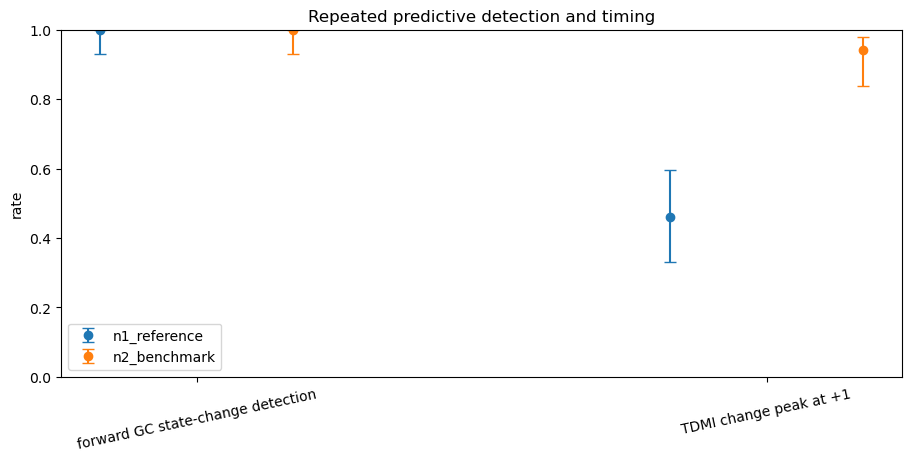

In [90]:
figures={}; rate_plot_metrics=[('gc_forward_change_detected_5pct','forward GC state-change detection'),('tdmi_change_peak_at_plus_1','TDMI change peak at +1')]
fig,ax=plt.subplots(figsize=(9,4.5),constrained_layout=True); cases=['n1_reference','n2_benchmark']; x=np.arange(len(rate_plot_metrics)); width=.34
for j,case in enumerate(cases):
    rows=calibration_rate_summary.loc[calibration_rate_summary.case_name.eq(case)].set_index('metric'); values=[]; lower=[]; upper=[]
    for metric,_ in rate_plot_metrics:
        row=rows.loc[metric]; values.append(row.rate); lower.append(row.rate-row.ci_95_lower if pd.notna(row.rate) else np.nan); upper.append(row.ci_95_upper-row.rate if pd.notna(row.rate) else np.nan)
    ax.errorbar(x+(j-.5)*width,values,yerr=[lower,upper],fmt='o',capsize=4,label=case)
ax.set(xticks=x,xticklabels=[label for _,label in rate_plot_metrics],ylim=(0,1),ylabel='rate',title='Repeated predictive detection and timing'); ax.tick_params(axis='x',rotation=12); ax.legend(); figures['repeated_detection_timing.png']=fig; plt.show()

## Figure 2 - Event-profile recovery

Event-weight profile RMSE evaluates the same dimensionless recovery object in both formulations. All seed-level observations, including outliers, are shown.

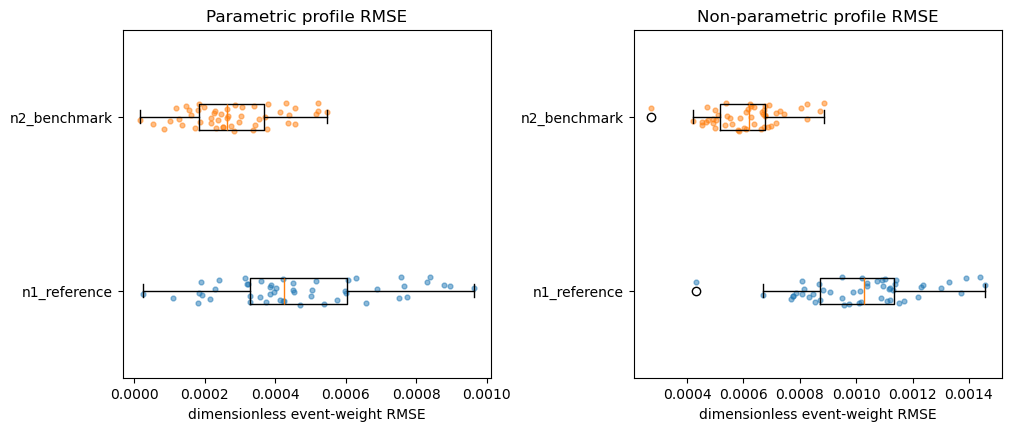

In [91]:
fig,axes=plt.subplots(1,2,figsize=(10,4.2),constrained_layout=True); profile_metrics=[('parametric_profile_RMSE','Parametric profile RMSE'),('nonparametric_profile_RMSE','Non-parametric profile RMSE')]
for ax,(metric,title) in zip(axes,profile_metrics):
    values=[successful.loc[successful.case_name.eq(case),metric].to_numpy() for case in cases]; ax.boxplot(values,vert=False,tick_labels=cases,showfliers=True)
    for y,v in enumerate(values,1): ax.scatter(v,np.full(len(v),y)+np.linspace(-.08,.08,len(v)),alpha=.5,s=12)
    ax.set(title=title,xlabel='dimensionless event-weight RMSE')
figures['repeated_profile_rmse.png']=fig; plt.show()

## Figure 3 — Forecast gains

Sigma-space percentage gains are comparable descriptively because both formulations forecast volatility. The comparison remains between dedicated calibrations, not an isolated n effect.

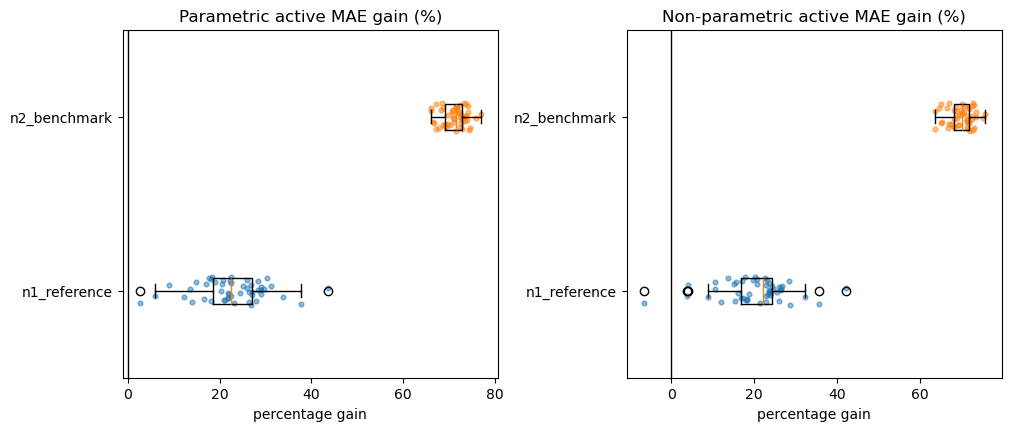

In [92]:
fig,axes=plt.subplots(1,2,figsize=(10,4.2),constrained_layout=True); gain_metrics=[('parametric_active_MAE_gain_pct','Parametric active MAE gain (%)'),('nonparametric_active_MAE_gain_pct','Non-parametric active MAE gain (%)')]
for ax,(metric,title) in zip(axes,gain_metrics):
    values=[successful.loc[successful.case_name.eq(case),metric].to_numpy() for case in cases]; ax.boxplot(values,vert=False,tick_labels=cases,showfliers=True)
    for y,v in enumerate(values,1): ax.scatter(v,np.full(len(v),y)+np.linspace(-.08,.08,len(v)),alpha=.5,s=12)
    ax.axvline(0,color='black',linewidth=1); ax.set(title=title,xlabel='percentage gain')
figures['repeated_forecast_gains.png']=fig; plt.show()

## Figure 4 - Mean event-weight recovery

The event-weight function is common to both formulations even though the powered-state multiplier differs. The panels therefore show the directly comparable dimensionless event-weight profiles only.

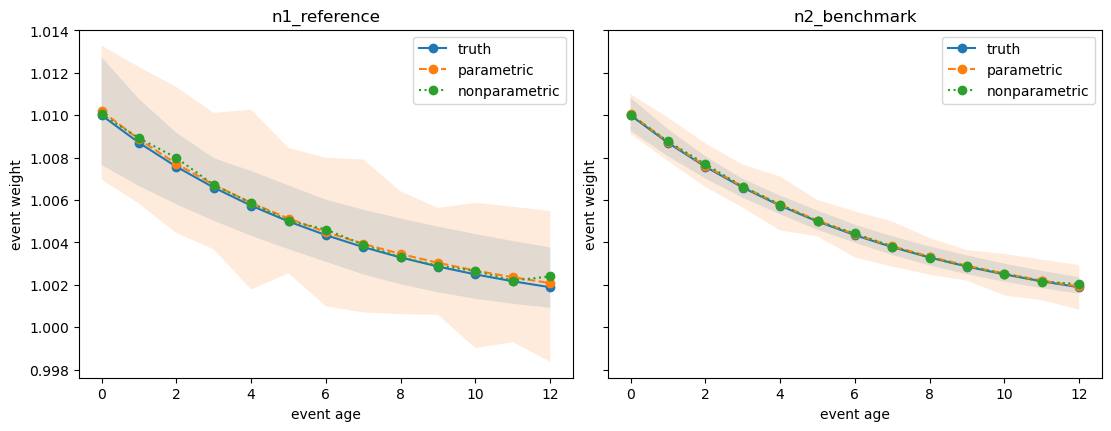

In [93]:
fig,axes=plt.subplots(1,2,figsize=(11,4.2),sharey=True,constrained_layout=True)
for ax,case in zip(axes,cases):
    for method,style in [('truth','-'),('parametric','--'),('nonparametric',':')]:
        subset=repeated_profile_summary.loc[(repeated_profile_summary.case_name.eq(case)) & (repeated_profile_summary.profile_method.eq(method)) & (repeated_profile_summary.quantity.eq('event_weight'))].sort_values('event_age')
        ax.plot(subset.event_age,subset['mean'],linestyle=style,marker='o',label=method)
        if method!='truth': ax.fill_between(subset.event_age,subset.q05,subset.q95,alpha=.15)
    ax.set(title=case,xlabel='event age',ylabel='event weight'); ax.legend()
figures['repeated_event_weight_profiles.png']=fig; plt.show()

## Figure 5 - Sigma-space forecasting errors

Absolute sigma-space errors may be compared descriptively because both forecasts target volatility. Different calibrations can generate different volatility distributions, so paired gains and contrasts remain important.

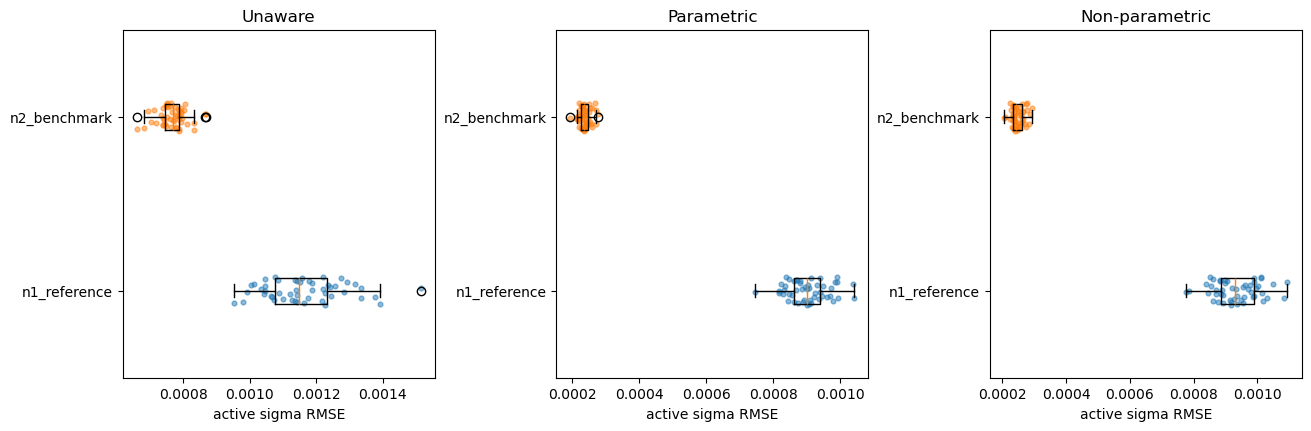

In [94]:
fig,axes=plt.subplots(1,3,figsize=(13,4.2),constrained_layout=True); rmse_metrics=[('baseline_active_sigma_RMSE','Unaware'),('parametric_active_sigma_RMSE','Parametric'),('nonparametric_active_sigma_RMSE','Non-parametric')]
for ax,(metric,title) in zip(axes,rmse_metrics):
    values=[successful.loc[successful.case_name.eq(case),metric].to_numpy() for case in cases]; ax.boxplot(values,vert=False,tick_labels=cases,showfliers=True)
    for y,v in enumerate(values,1): ax.scatter(v,np.full(len(v),y)+np.linspace(-.08,.08,len(v)),alpha=.5,s=12)
    ax.set(title=title,xlabel='active sigma RMSE')
figures['repeated_sigma_rmse.png']=fig; plt.show()

## Figure 6 — State-space calibration

State-space coverage is dimensionless, while raw state-space interval scores are not directly comparable across formulations. The figure therefore compares absolute coverage errors only.

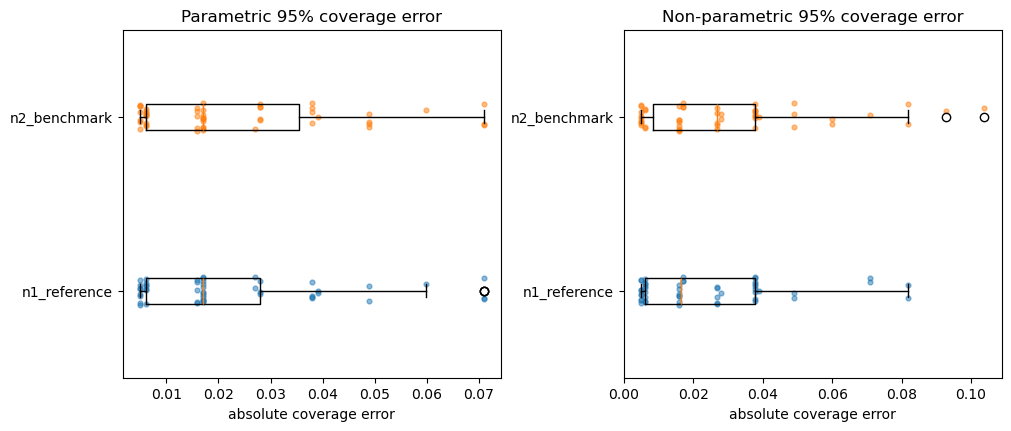

In [95]:
fig,axes=plt.subplots(1,2,figsize=(10,4.2),constrained_layout=True); coverage_metrics=[('parametric_95_state_coverage_error','Parametric 95% coverage error'),('nonparametric_95_state_coverage_error','Non-parametric 95% coverage error')]
for ax,(metric,title) in zip(axes,coverage_metrics):
    values=[analysis_results.loc[(analysis_results.case_name.eq(case)) & mask,metric].to_numpy() for case in cases]; ax.boxplot(values,vert=False,tick_labels=cases,showfliers=True)
    for y,v in enumerate(values,1): ax.scatter(v,np.full(len(v),y)+np.linspace(-.08,.08,len(v)),alpha=.5,s=12)
    ax.set(title=title,xlabel='absolute coverage error')
figures['repeated_state_coverage_error.png']=fig; plt.show()

## Save repeated-seed figures

The six final repeated-seed figures are written at publication-friendly resolution to the notebook-specific results directory.

In [96]:
for filename, figure in figures.items(): figure.savefig(FIGURES_DIR/filename,dpi=180,bbox_inches='tight')
assert set(figures)=={'repeated_detection_timing.png','repeated_profile_rmse.png','repeated_forecast_gains.png','repeated_event_weight_profiles.png','repeated_sigma_rmse.png','repeated_state_coverage_error.png'} and all((FIGURES_DIR/name).exists() for name in figures)

## Repeated-seed findings

### Numerical robustness

All 100 planned runs completed successfully (50 per dedicated calibration), with no failures and 3,900 complete event-profile rows. Every n=2 run retained `common_test_rows=True`; all parametric profile fits converged. The checkpoints, raw tidy tables, summaries, contrasts, and six figures were exported.

### Predictive structure

Forward state-change GC rejected at 5% in all 50 seeds for each calibration (Wilson 95% interval $[92.9\%,100\%]$). The frozen workflow does not return reverse historical-GC tests, so no reverse rejection rate is manufactured. Mean forward state-change partial $R^2$ was $0.1375$ for n=1 and $0.4903$ for n=2; mean conditional predictive-structure partial $R^2$ was $0.1831$ and $0.6698$. TDMI state-change direct-window peaks occurred at $+1$ in 46% of n=1 seeds (Wilson interval $[33.0\%,59.6\%]$) and 94% of n=2 seeds ($[83.8\%,97.9\%]$). These are predictive/dependence diagnostics, not structural-causality proof.

### Event-profile recovery

Mean $\widehat A$ was $0.010204$ for n=1 and $0.010054$ for n=2; mean $\widehat\lambda$ was $34.833$ and $34.856$. Median parametric/non-parametric event-weight profile RMSE was $0.000425/0.001028$ for n=1 and $0.000263/0.000620$ for n=2. Same-seed n=2-minus-n=1 differences in profile RMSE were negative for both parametric ($-0.000194$, 95% Monte Carlo interval $[-0.000221,-0.000167]$) and non-parametric ($-0.000413$, $[-0.000437,-0.000388]$) recovery. Because event weight is dimensionless, these are clean cross-calibration associations rather than transformed-state-unit comparisons.

### Forecast performance

Median active-period parametric/non-parametric sigma-space MAE gains were $22.42\%/22.04\%$ for n=1 and $71.51\%/70.03\%$ for n=2. Parametric gains were positive in all seeds for both calibrations; non-parametric gains were positive in 98% of n=1 seeds and all n=2 seeds. The paired gain differences were $48.31$ percentage points ($[46.73,49.90]$) for parametric and $49.50$ points ($[47.80,51.19]$) for non-parametric forecasts. These larger n=2 gains cannot be attributed to $n$ alone: the dedicated n=2 calibration also has lower local volatility innovation scale, different $\rho_0$, different powered-state dynamics, and finite-sample variation.

### Calibration

Mean parametric 95% powered-state coverage was $94.46\%$ for n=1 and $94.29\%$ for n=2; their mean absolute coverage errors were $0.0224$ and $0.0233$, whose paired interval includes zero ($0.000879$, $[-0.001200,0.002958]$). Non-parametric coverage errors were $0.0242$ and $0.0296$, with an n=2-minus-n=1 interval above zero ($0.005407$, $[0.002286,0.008528]$). Within-calibration mean parametric/non-parametric state interval scores were $0.004199/0.004388$ for n=1 and $0.000585/0.000620$ for n=2; raw scores are not ranked across calibrations because state units differ.

### Paired interpretation

Persistent same-seed differences associate the dedicated n=2 calibration with stronger predictive statistics, lower dimensionless event-profile RMSE, and larger sigma-space active forecast gains. Neither calibration has a clear parametric coverage-error advantage. These results establish repeated pipeline behaviour under the two dedicated calibrations, not superiority caused by the exponent alone.

The corrected multiplier transformation affects only the derived profile interpretation columns. It does not change event-weight estimates, profile RMSE, forecast metrics, calibration metrics, or the paired contrasts reported above.

## Repeated-seed limitations

The repeated experiment uses only 50 synthetic shock realisations. The dedicated calibrations differ in $n$, $\nu_0$, and $\rho_0$, so the paired comparison does not isolate the exponent and local volatility innovation scales differ. Raw powered-state errors and interval scores have different units; events remain dense, periodic, and deterministic; no parameter interactions or scale-matched experiment have yet been studied.

## Repeated-seed dedicated-calibration summary

The completed work through this point comprises correctly scaled one-seed validation, the paired 50-seed frozen $n=1$ reference and dedicated $n=2$ analyses, predictive-structure summaries, event-weight recovery, sigma-space forecasting, state-space calibration, paired Monte Carlo uncertainty, tidy exports and repeated-seed figures. The local scale-matched comparison that follows tests whether key associations persist when local volatility innovation scale and $\rho_0$ are aligned.

The causal timing remains $E_i\longrightarrow\omega_{i+1}\longrightarrow X_{i+1}$.

## Local scale-matched n=1 versus n=2 comparison

The frozen benchmark uses $X^{(1)}=\sigma$ and the matched model uses $X^{(2)}=\sigma^2$. The common reference volatility $\sigma_{\rm ref}$ is the frozen n=1 initial volatility, which must equal its implied target volatility. The local match sets $\theta_2=\sigma_{\rm ref}^2$, $\nu_2=2\sigma_{\rm ref}\nu_1$, $\rho_2=\rho_1$, and $\kappa_2=\kappa_1$. This matches initial volatility, target volatility, correlation, mean reversion, and first-order volatility innovation scale only locally: $\nu_{\sigma,2}(\sigma)=\nu_2/(2\sigma)$ changes away from $\sigma_{\rm ref}$. It is therefore more controlled than the dedicated comparison, but not a perfect isolation of n.

## Construct and validate the local scale-matched configuration

The dedicated n=2 configuration is copied as the structural source. Only the fields implied by the matching rule are overridden; event settings, timing, simulation length, initial price, and train fraction remain frozen.

In [97]:
n1_match_snapshot, n2_dedicated_snapshot = copy.deepcopy(n1_reference_case), copy.deepcopy(n2_benchmark_case)
sigma_reference=n1_reference_case['simulation']['sigma0']; n1_target_sigma=n1_reference_case['model']['theta']
if not np.isclose(sigma_reference,n1_target_sigma,rtol=0,atol=1e-12): raise ValueError('The n=1 initial and implied target volatilities must agree for local matching.')
theta_n2_matched=sigma_reference**2; nu_n2_matched=2*sigma_reference*n1_reference_case['model']['nu_0']; rho_n2_matched=n1_reference_case['model']['rho_0']; kappa_n2_matched=n1_reference_case['model']['kappa']
n2_scale_matched_case=make_case_config(n2_benchmark_case,{'model.theta':theta_n2_matched,'model.nu_0':nu_n2_matched,'model.rho_0':rho_n2_matched,'model.kappa':kappa_n2_matched,'simulation.sigma0':sigma_reference},label='n2_scale_matched')
def match_config_row(name,config):
 m,s,e=config['model'],config['simulation'],config['events']; n=m['n']; t=derive_timing(config)
 return {'case_name':name,'n':n,'state_interpretation':'volatility' if n==1 else 'variance','kappa':m['kappa'],'theta_state':m['theta'],'implied_target_sigma':m['theta']**(1/n),'nu_state':m['nu_0'],'local_sigma_innovation_scale':m['nu_0']/(n*sigma_reference**(n-1)),'rho_0':m['rho_0'],'initial_sigma':s['sigma0'],'initial_state':s['sigma0']**n,'event_amplitude':e['amplitude'],'event_decay_rate':e['decay_rate'],'event_period':t['event_period_steps'],'response_horizon':t['response_horizon_steps'],'n_transitions':int(s['years']*s['trading_steps_per_year'])}
scale_match_configuration=pd.DataFrame([match_config_row('n1_reference',n1_reference_case),match_config_row('n2_dedicated',n2_benchmark_case),match_config_row('n2_scale_matched',n2_scale_matched_case)]); display(scale_match_configuration)
n1m=scale_match_configuration.iloc[0]; n2m=scale_match_configuration.iloc[2]
for field in ['implied_target_sigma','initial_sigma','local_sigma_innovation_scale','rho_0','kappa','event_amplitude','event_decay_rate','event_period','response_horizon','n_transitions']: assert np.isclose(n1m[field],n2m[field],rtol=0,atol=1e-12)
assert n2_scale_matched_case['model']['n']==2 and n1_reference_case==n1_match_snapshot and n2_benchmark_case==n2_dedicated_snapshot

,case_name,n,state_interpretation,kappa,theta_state,implied_target_sigma,nu_state,local_sigma_innovation_scale,rho_0,initial_sigma,initial_state,event_amplitude,event_decay_rate,event_period,response_horizon,n_transitions
0,n1_reference,1,volatility,1.5,0.20,0.2,0.015,0.015,-0.35,0.2,0.20,0.01,35.0,21,12,504
1,n2_dedicated,2,variance,1.5,0.04,0.2,0.002,0.005,-0.25,0.2,0.04,0.01,35.0,21,12,504
2,n2_scale_matched,2,variance,1.5,0.04,0.2,0.006,0.015,-0.35,0.2,0.04,0.01,35.0,21,12,504


## One-seed scale-matched smoke test

A matched configuration must pass common-shock simulation identities and one frozen pipeline before the repeated run begins. The one-seed n=1 reference forecast identifiers provide the fixed timing check.

In [98]:
SCALE_MATCHED_PROTOTYPE_SEED=REPLICATION_SEEDS[0]; scale_matched_prototype_shocks=make_shock_bank(n1_reference_case,seed=SCALE_MATCHED_PROTOTYPE_SEED)
n1_match_smoke=simulate_case(n1_reference_case,shock_bank=scale_matched_prototype_shocks); n2_match_smoke=simulate_case(n2_scale_matched_case,shock_bank=scale_matched_prototype_shocks)
a,b=n1_match_smoke['simulation'],n2_match_smoke['simulation']
for col in ['epsilon','eta','event','i','target_i']: assert np.array_equal(a['transitions'][col].to_numpy(),b['transitions'][col].to_numpy())
assert len(a['transitions'])==len(b['transitions']) and np.allclose(b['states'].x,b['states'].sigma**2,rtol=0,atol=1e-12) and np.allclose(b['transitions'].x_next,b['transitions'].omega_next*b['transitions'].F,rtol=0,atol=1e-12)
for sim in [a,b]: assert np.isfinite(sim['states'][['S','sigma','x']].to_numpy()).all() and sim['states'][['S','sigma','x']].gt(0).all().all() and sim['transitions'][['F','x_next','sigma_next','omega_next']].gt(0).all().all()
n2_scale_matched_prototype=run_full_pipeline(n2_scale_matched_case,shock_bank=scale_matched_prototype_shocks,**n2_pipeline_options); n2_scale_matched_prototype_summary=summarise_case(n2_scale_matched_prototype)
n1_reference_forecast_ids=n1_prototype_result['forecasts'][['i','target_i']].reset_index(drop=True); assert n1_reference_forecast_ids.equals(n2_scale_matched_prototype['forecasts'][['i','target_i']].reset_index(drop=True))
prototype_row=extract_repeated_run_summary(n2_scale_matched_prototype,n2_scale_matched_prototype_summary,n2_scale_matched_case,'n2_scale_matched','local scale-matched n=2 calibration',SCALE_MATCHED_PROTOTYPE_SEED,True,0.0); display(pd.DataFrame([prototype_row])[['case_name','n','run_success','A_hat','lambda_hat','parametric_profile_RMSE','nonparametric_profile_RMSE','parametric_active_MAE_gain_pct','nonparametric_active_MAE_gain_pct','parametric_active_95_state_coverage','known_dgp_active_state_RMSE']])

,case_name,n,run_success,A_hat,lambda_hat,parametric_profile_RMSE,nonparametric_profile_RMSE,parametric_active_MAE_gain_pct,nonparametric_active_MAE_gain_pct,parametric_active_95_state_coverage,known_dgp_active_state_RMSE
0,n2_scale_matched,2,True,0.008518,35.433368,0.000846,0.002813,35.382163,33.536758,0.945055,0.000334


## Scale-matched execution controls

The completed seed plan and results directory are reused unchanged. Separate scale-matched checkpoints permit the new n=2 analysis to resume or load without rerunning the completed dedicated-calibration experiment.

In [99]:
RUN_SCALE_MATCHED_REPLICATION=False
SCALE_MATCHED_DIR=RESULTS_DIR/'scale_matched'; SCALE_MATCHED_DIR.mkdir(exist_ok=True)
SCALE_MATCHED_RUN_CHECKPOINT=SCALE_MATCHED_DIR/'scale_matched_n2_run_checkpoint.csv'; SCALE_MATCHED_PROFILE_CHECKPOINT=SCALE_MATCHED_DIR/'scale_matched_n2_profile_checkpoint.csv'; SCALE_MATCHED_FAILURE_CHECKPOINT=SCALE_MATCHED_DIR/'scale_matched_n2_failure_checkpoint.csv'; SCALE_MATCHED_SIMULATION_CHECKPOINT=SCALE_MATCHED_DIR/'scale_matched_simulation_diagnostics.csv' 

## Fifty-seed simulation-only preflight

Cheap paired simulations test numerical validity and realised volatility distributions before fitting. Failures remain recorded and no parameter is tuned in response.

In [100]:
preflight_rows=[]
for seed in REPLICATION_SEEDS:
    case_plan=[
        ('n1_reference',n1_reference_case),
        ('n2_scale_matched',n2_scale_matched_case),
    ]
    try:
        common_shock_bank=make_shock_bank(n1_reference_case,seed=seed)
    except Exception as exc:
        for case_name,case_config in case_plan:
            preflight_rows.append({
                'seed':seed,'case_name':case_name,'n':case_config['model']['n'],
                'simulation_success':False,'failure_stage':'shock bank',
                'exception_type':type(exc).__name__,'failure_message':str(exc),
            })
        continue

    seed_simulations={}
    for case_name,case_config in case_plan:
        try:
            sim=simulate_case(case_config,shock_bank=common_shock_bank)['simulation']
            st,tr=sim['states'],sim['transitions']; n=case_config['model']['n']
            seed_simulations[case_name]=sim
            row={'seed':seed,'case_name':case_name,'n':n,'simulation_success':True,'failure_stage':'','exception_type':'','failure_message':'','minimum_price':st.S.min(),'minimum_sigma':st.sigma.min(),'maximum_sigma':st.sigma.max(),'mean_sigma':st.sigma.mean(),'standard_deviation_sigma':st.sigma.std(ddof=1),'q05_sigma':st.sigma.quantile(.05),'median_sigma':st.sigma.median(),'q95_sigma':st.sigma.quantile(.95),'minimum_state':st.x.min(),'maximum_state':st.x.max(),'all_finite':np.isfinite(st[['S','sigma','x']].to_numpy()).all() and np.isfinite(tr[['F','x_next','sigma_next','omega_next']].to_numpy()).all(),'all_prices_positive':st.S.gt(0).all(),'all_states_positive':st.x.gt(0).all(),'all_transition_quantities_positive':tr[['F','x_next','sigma_next','omega_next']].gt(0).all().all(),'state_identity_max_absolute_error':np.max(np.abs(st.x-st.sigma**2)) if n==2 else np.nan,'transition_identity_max_absolute_error':np.max(np.abs(tr.x_next-tr.omega_next*tr.F)) if n==2 else np.nan}
        except Exception as exc:
            row={'seed':seed,'case_name':case_name,'n':case_config['model']['n'],'simulation_success':False,'failure_stage':'simulation','exception_type':type(exc).__name__,'failure_message':str(exc)}
        preflight_rows.append(row)

    if set(seed_simulations)=={'n1_reference','n2_scale_matched'}:
        n1_transitions=seed_simulations['n1_reference']['transitions']
        n2_transitions=seed_simulations['n2_scale_matched']['transitions']
        assert len(n1_transitions)==len(n2_transitions)
        for column in ['epsilon','eta','event','i','target_i']:
            assert np.array_equal(n1_transitions[column].to_numpy(),n2_transitions[column].to_numpy())

scale_matched_simulation_diagnostics=pd.DataFrame(preflight_rows)
scale_matched_simulation_diagnostics.to_csv(SCALE_MATCHED_SIMULATION_CHECKPOINT,index=False)
scale_matched_simulation_diagnostics.to_csv(SCALE_MATCHED_DIR/'notebook09_scale_matched_simulation_diagnostics.csv',index=False)
preflight_status=pd.DataFrame([{'planned_simulations':100,'successful_simulations':int(scale_matched_simulation_diagnostics.simulation_success.sum()),'failed_simulations':int((~scale_matched_simulation_diagnostics.simulation_success).sum()),'n1_success_rate':scale_matched_simulation_diagnostics.loc[lambda d:d.case_name.eq('n1_reference'),'simulation_success'].mean(),'n2_success_rate':scale_matched_simulation_diagnostics.loc[lambda d:d.case_name.eq('n2_scale_matched'),'simulation_success'].mean()}])
display(preflight_status)

,planned_simulations,successful_simulations,failed_simulations,n1_success_rate,n2_success_rate
0,100,100,0,1.0,1.0


## Fifty matched n=2 pipelines paired with stored n=1 results

The frozen n=1 pipeline is not rerun. Deterministic shock banks reproduce its 50 seed conditions, and each new matched n=2 result is checked against the stored n=1 timing identifiers.

In [101]:
scale_matched_rows=[]; scale_matched_profile_rows=[]; scale_matched_failure_rows=[]; valid_scale_seeds=set(scale_matched_simulation_diagnostics.loc[(scale_matched_simulation_diagnostics.case_name.eq('n2_scale_matched')) & scale_matched_simulation_diagnostics.simulation_success,'seed'])
if RUN_SCALE_MATCHED_REPLICATION:
 for position,seed in enumerate(REPLICATION_SEEDS,1):
  started=perf_counter()
  if seed not in valid_scale_seeds:
   exc=RuntimeError('matched n=2 preflight simulation failed'); scale_matched_rows.append({'seed':seed,'case_name':'n2_scale_matched','n':2,'state_interpretation':'variance','calibration_interpretation':'local scale-matched n=2 calibration','run_success':False,'common_test_rows':np.nan,'failure_stage':'preflight','exception_type':type(exc).__name__,'failure_message':str(exc),'seed_runtime_seconds':perf_counter()-started}); scale_matched_failure_rows.append({'seed':seed,'case_name':'n2_scale_matched','n':2,'failure_stage':'preflight','exception_type':type(exc).__name__,'failure_message':str(exc)})
  else:
   try:
    result=run_full_pipeline(n2_scale_matched_case,shock_bank=make_shock_bank(n1_reference_case,seed=seed),**n2_pipeline_options); summary=summarise_case(result); common=n1_reference_forecast_ids.equals(result['forecasts'][['i','target_i']].reset_index(drop=True)); assert common
    row=extract_repeated_run_summary(result,summary,n2_scale_matched_case,'n2_scale_matched','local scale-matched n=2 calibration',seed,common,perf_counter()-started); row['seed_runtime_seconds']=row.pop('seed_pair_runtime_seconds'); scale_matched_rows.append(row); scale_matched_profile_rows.extend(extract_repeated_profile_rows(result,n2_scale_matched_case,'n2_scale_matched',seed))
   except Exception as exc:
    scale_matched_rows.append({'seed':seed,'case_name':'n2_scale_matched','n':2,'state_interpretation':'variance','calibration_interpretation':'local scale-matched n=2 calibration','run_success':False,'common_test_rows':np.nan,'failure_stage':'pipeline, summary, forecast-row validation, or extraction','exception_type':type(exc).__name__,'failure_message':str(exc),'seed_runtime_seconds':perf_counter()-started}); scale_matched_failure_rows.append({'seed':seed,'case_name':'n2_scale_matched','n':2,'failure_stage':'pipeline, summary, forecast-row validation, or extraction','exception_type':type(exc).__name__,'failure_message':str(exc)})
  pd.DataFrame(scale_matched_rows).to_csv(SCALE_MATCHED_RUN_CHECKPOINT,index=False); pd.DataFrame(scale_matched_profile_rows).to_csv(SCALE_MATCHED_PROFILE_CHECKPOINT,index=False); pd.DataFrame(scale_matched_failure_rows).to_csv(SCALE_MATCHED_FAILURE_CHECKPOINT,index=False); print(f'Scale-matched seed {position}/50 | successful: {sum(r.get("run_success",False) for r in scale_matched_rows)}/{len(scale_matched_rows)}')
 scale_matched_results,scale_matched_profiles,scale_matched_failures=pd.DataFrame(scale_matched_rows),pd.DataFrame(scale_matched_profile_rows),pd.DataFrame(scale_matched_failure_rows)
else:
 missing=[x for x in [SCALE_MATCHED_RUN_CHECKPOINT,SCALE_MATCHED_PROFILE_CHECKPOINT,SCALE_MATCHED_FAILURE_CHECKPOINT] if not x.exists()]
 if missing: raise FileNotFoundError(f'Scale-matched checkpoint loading requires {missing}')
 scale_matched_results,scale_matched_profiles=pd.read_csv(SCALE_MATCHED_RUN_CHECKPOINT),pd.read_csv(SCALE_MATCHED_PROFILE_CHECKPOINT)
 try:
  scale_matched_failures=pd.read_csv(SCALE_MATCHED_FAILURE_CHECKPOINT)
 except pd.errors.EmptyDataError:
  scale_matched_failures=pd.DataFrame(columns=['seed','case_name','n','failure_stage','exception_type','failure_message'])

## Validate, pair, and summarise the scale-matched outputs

Raw results retain every seed. Successful matched results are joined to the stored frozen n=1 rows by seed; only dimensionless or sigma-space quantities enter cross-formulation contrasts.

In [102]:
scale_matched_results=scale_matched_results.sort_values('seed').reset_index(drop=True); scale_matched_profiles=scale_matched_profiles.sort_values(['seed','profile_method','event_age']).reset_index(drop=True)
assert len(scale_matched_results)==50 and not scale_matched_results.seed.duplicated().any() and scale_matched_results.case_name.eq('n2_scale_matched').all()
sm_success=scale_matched_results.loc[scale_matched_results.run_success.eq(True)].copy(); assert sm_success.common_test_rows.eq(True).all(); assert sm_success.filter(regex='coverage$').apply(lambda x:x.dropna().between(0,1).all()).all()
assert len(scale_matched_profiles)==39*len(sm_success)
assert not scale_matched_profiles.duplicated(['seed','event_age','profile_method']).any()
successful_scale_profiles=scale_matched_profiles.loc[scale_matched_profiles.seed.isin(sm_success.seed)].copy()
assert set(successful_scale_profiles.seed)==set(sm_success.seed)
assert successful_scale_profiles.groupby('seed').size().eq(39).all()
assert successful_scale_profiles.groupby('seed').event_age.agg(lambda values:set(values)==set(range(13))).all()
assert successful_scale_profiles.groupby('seed').profile_method.agg(lambda values:set(values)=={'truth','parametric','nonparametric'}).all()
assert np.allclose(scale_matched_profiles.state_multiplier,scale_matched_profiles.event_weight**(scale_matched_profiles.n/2),rtol=0,atol=1e-12) and np.allclose(scale_matched_profiles.volatility_multiplier,np.sqrt(scale_matched_profiles.event_weight),rtol=0,atol=1e-12) and scale_matched_profiles.event_weight.gt(0).all()
scale_matched_results.to_csv(SCALE_MATCHED_DIR/'notebook09_scale_matched_n2_run_results.csv',index=False); scale_matched_profiles.to_csv(SCALE_MATCHED_DIR/'notebook09_scale_matched_n2_profiles.csv',index=False); scale_matched_failures.to_csv(SCALE_MATCHED_DIR/'notebook09_scale_matched_n2_failures.csv',index=False)
for frame in [sm_success]:
 frame['gc_forward_change_detected_5pct']=frame.gc_forward_change_p_value.lt(.05); frame['tdmi_change_peak_at_plus_1']=frame.tdmi_change_direct_peak_lag.eq(1); frame['parametric_positive_MAE_gain']=frame.parametric_active_MAE_gain_pct.gt(0); frame['nonparametric_positive_MAE_gain']=frame.nonparametric_active_MAE_gain_pct.gt(0); frame['parametric_95_state_coverage_error']=(frame.parametric_active_95_state_coverage-.95).abs(); frame['nonparametric_95_state_coverage_error']=(frame.nonparametric_active_95_state_coverage-.95).abs()
n1_stored=analysis_results.loc[(analysis_results.case_name.eq('n1_reference')) & analysis_results.run_success.eq(True)].set_index('seed'); sm_stored=sm_success.set_index('seed'); scale_matched_paired_wide=n1_stored.join(sm_stored,lsuffix='_n1',rsuffix='_n2_matched',how='inner'); assert not scale_matched_paired_wide.index.duplicated().any(); paired_seed_count=len(scale_matched_paired_wide); assert paired_seed_count==len(sm_success); assert paired_seed_count==50
for column in ['gc_forward_change_detected_5pct','tdmi_change_peak_at_plus_1','parametric_positive_MAE_gain','nonparametric_positive_MAE_gain','parametric_95_state_coverage_error','nonparametric_95_state_coverage_error']:
 if column not in n1_stored: n1_stored[column]=analysis_results.loc[analysis_results.case_name.eq('n1_reference')].set_index('seed')[column]
num_metrics=['conditional_partial_r_squared','gc_forward_change_partial_r_squared','tdmi_change_direct_peak','A_relative_error','lambda_relative_error','parametric_profile_RMSE','nonparametric_profile_RMSE','baseline_active_sigma_MAE','baseline_active_sigma_RMSE','parametric_active_sigma_MAE','parametric_active_sigma_RMSE','nonparametric_active_sigma_MAE','nonparametric_active_sigma_RMSE','parametric_active_MAE_gain_pct','parametric_active_RMSE_gain_pct','nonparametric_active_MAE_gain_pct','nonparametric_active_RMSE_gain_pct','parametric_95_state_coverage_error','nonparametric_95_state_coverage_error']
scale_matched_numeric_summary=pd.DataFrame([{'case_name':name,'metric':metric,**summarise_numeric_series(frame[metric])} for name,frame in [('n1_reference',n1_stored),('n2_scale_matched',sm_success.set_index('seed'))] for metric in num_metrics]); rate_metrics=['gc_forward_change_detected_5pct','tdmi_change_peak_at_plus_1','parametric_positive_MAE_gain','nonparametric_positive_MAE_gain']; scale_matched_rate_summary=pd.DataFrame([{'case_name':name,'metric':metric,**summarise_binary_series(frame[metric])} for name,frame in [('n1_reference',n1_stored),('n2_scale_matched',sm_success.set_index('seed'))] for metric in rate_metrics])
contrast_metrics=num_metrics; scale_matched_paired_contrasts_raw=pd.concat([pd.DataFrame({'seed':scale_matched_paired_wide.index,'metric':m,'n1_value':scale_matched_paired_wide[m+'_n1'],'n2_value':scale_matched_paired_wide[m+'_n2_matched'],'paired_difference_n2_minus_n1':scale_matched_paired_wide[m+'_n2_matched']-scale_matched_paired_wide[m+'_n1']}) for m in contrast_metrics],ignore_index=True); scale_matched_paired_contrast_summary=pd.DataFrame([{'metric':m,**{('mean_difference' if k=='mean' else 'median_difference' if k=='median' else k):v for k,v in summarise_numeric_series(g.paired_difference_n2_minus_n1).items()}} for m,g in scale_matched_paired_contrasts_raw.groupby('metric')])
scale_matched_numeric_summary.to_csv(SCALE_MATCHED_DIR/'notebook09_scale_matched_numeric_summary.csv',index=False); scale_matched_rate_summary.to_csv(SCALE_MATCHED_DIR/'notebook09_scale_matched_rate_summary.csv',index=False); scale_matched_paired_contrasts_raw.to_csv(SCALE_MATCHED_DIR/'notebook09_scale_matched_paired_contrasts_raw.csv',index=False); scale_matched_paired_contrast_summary.to_csv(SCALE_MATCHED_DIR/'notebook09_scale_matched_paired_contrast_summary.csv',index=False)

## Realised volatility comparability and compact scale-matched tables

The first-order algebraic match must be assessed against paired realised volatility distributions. Compact tables retain decision-relevant configuration, execution, distribution, detection, recovery, and forecast summaries.

In [103]:
preflight_success=scale_matched_simulation_diagnostics.loc[scale_matched_simulation_diagnostics.simulation_success].pivot(index='seed',columns='case_name',values=['mean_sigma','standard_deviation_sigma','q05_sigma','median_sigma','q95_sigma']); sigma_metrics=['mean_sigma','standard_deviation_sigma','q05_sigma','median_sigma','q95_sigma']
scale_matched_sigma_distribution_contrasts=pd.DataFrame([{'metric':m,**{('mean_difference' if k=='mean' else 'median_difference' if k=='median' else k):v for k,v in summarise_numeric_series(preflight_success[(m,'n2_scale_matched')]-preflight_success[(m,'n1_reference')]).items()}} for m in sigma_metrics]); scale_matched_sigma_distribution_contrasts.to_csv(SCALE_MATCHED_DIR/'notebook09_scale_matched_sigma_distribution_contrasts.csv',index=False)
profile_summary_sm=pd.DataFrame([{'case_name':name,'profile_method':method,'event_age':age,'mean':g.event_weight.mean(),'q05':g.event_weight.quantile(.05),'q95':g.event_weight.quantile(.95)} for name,frame in [('n1_reference',repeated_profiles.loc[repeated_profiles.case_name.eq('n1_reference')]),('n2_scale_matched',scale_matched_profiles)] for method in ['truth','parametric','nonparametric'] for age,g in frame.loc[frame.profile_method.eq(method)].groupby('event_age')])
status_sm=pd.DataFrame([{'planned_runs':50,'successful_runs':len(sm_success),'failed_runs':50-len(sm_success),'paired_seeds':paired_seed_count,'profile_rows':len(scale_matched_profiles)}]); display(scale_match_configuration[['case_name','n','theta_state','implied_target_sigma','nu_state','local_sigma_innovation_scale','rho_0','kappa']]); display(status_sm); display(scale_matched_sigma_distribution_contrasts[['metric','mean_difference','ci_95_lower','ci_95_upper','median_difference']])
rate_sm=scale_matched_rate_summary.pivot(index='case_name',columns='metric',values='rate'); recover_sm=scale_matched_numeric_summary.loc[scale_matched_numeric_summary.metric.isin(['parametric_profile_RMSE','nonparametric_profile_RMSE'])].pivot(index='case_name',columns='metric',values='median'); gains_sm=scale_matched_numeric_summary.loc[scale_matched_numeric_summary.metric.isin(['parametric_active_MAE_gain_pct','nonparametric_active_MAE_gain_pct'])].pivot(index='case_name',columns='metric',values='median'); display(rate_sm.join(recover_sm)); display(gains_sm.join(rate_sm[['parametric_positive_MAE_gain','nonparametric_positive_MAE_gain']])); display(scale_matched_paired_contrast_summary.loc[lambda d:d.metric.isin(['conditional_partial_r_squared','parametric_profile_RMSE','nonparametric_profile_RMSE','parametric_active_MAE_gain_pct','nonparametric_active_MAE_gain_pct','parametric_95_state_coverage_error','nonparametric_95_state_coverage_error']),['metric','mean_difference','ci_95_lower','ci_95_upper','median_difference']])

,case_name,n,theta_state,implied_target_sigma,nu_state,local_sigma_innovation_scale,rho_0,kappa
0,n1_reference,1,0.20,0.2,0.015,0.015,-0.35,1.5
1,n2_dedicated,2,0.04,0.2,0.002,0.005,-0.25,1.5
2,n2_scale_matched,2,0.04,0.2,0.006,0.015,-0.35,1.5


,planned_runs,successful_runs,failed_runs,paired_seeds,profile_rows
0,50,50,0,50,1950


,metric,mean_difference,ci_95_lower,ci_95_upper,median_difference
0,mean_sigma,0.002385,0.002210,0.002561,0.002321
1,standard_deviation_sigma,0.001714,0.001597,0.001832,0.001777
2,q05_sigma,-0.000045,-0.000070,-0.000020,-0.000021
3,median_sigma,0.002130,0.001765,0.002496,0.001960
4,q95_sigma,0.004700,0.004287,0.005114,0.004958


metric,gc_forward_change_detected_5pct,nonparametric_positive_MAE_gain,parametric_positive_MAE_gain,tdmi_change_peak_at_plus_1,nonparametric_profile_RMSE,parametric_profile_RMSE
case_name,,,,,,
n1_reference,1.0,0.98,1.0,0.46,0.001028,0.000425
n2_scale_matched,1.0,1.00,1.0,0.52,0.001769,0.000737


metric,nonparametric_active_MAE_gain_pct,parametric_active_MAE_gain_pct,parametric_positive_MAE_gain,nonparametric_positive_MAE_gain
case_name,,,,
n1_reference,22.038878,22.416529,1.0,0.98
n2_scale_matched,31.370160,34.035767,1.0,1.00


,metric,mean_difference,ci_95_lower,ci_95_upper,median_difference
3,conditional_partial_r_squared,0.044133,0.041592,0.046675,0.045117
6,nonparametric_95_state_coverage_error,0.004791,0.002246,0.007336,0.000000
7,nonparametric_active_MAE_gain_pct,9.562600,9.033603,10.091596,9.480120
11,nonparametric_profile_RMSE,0.000750,0.000704,0.000796,0.000750
12,parametric_95_state_coverage_error,-0.000176,-0.002016,0.001664,0.000000
13,parametric_active_MAE_gain_pct,10.028301,9.507038,10.549564,9.727307
17,parametric_profile_RMSE,0.000338,0.000289,0.000387,0.000319


## Figure 7 — Matched volatility distributions

Local parameter matching does not guarantee equal realised volatility distributions. The paired preflight paths therefore show both mean volatility and dispersion for every seed.

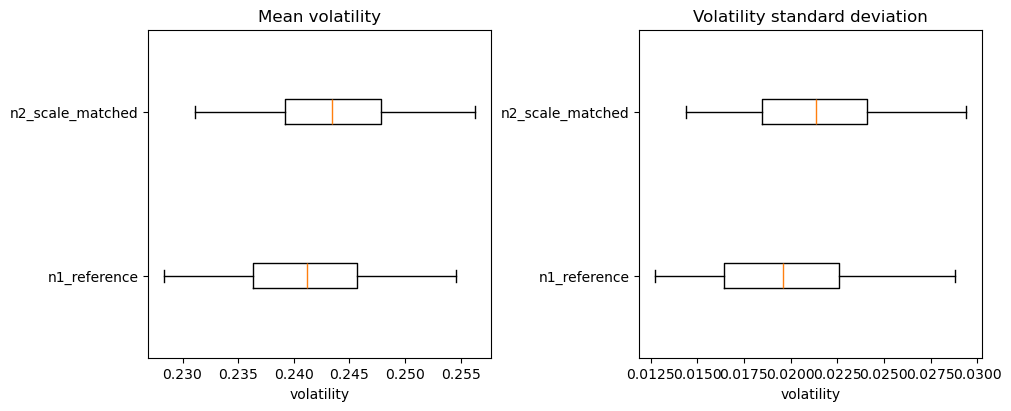

In [104]:
fig,axes=plt.subplots(1,2,figsize=(10,4),constrained_layout=True)
metric_labels={'mean_sigma':'Mean volatility','standard_deviation_sigma':'Volatility standard deviation'}
for ax,metric in zip(axes,['mean_sigma','standard_deviation_sigma']):
 vals=[preflight_success[(metric,'n1_reference')],preflight_success[(metric,'n2_scale_matched')]]; ax.boxplot(vals,vert=False,tick_labels=['n1_reference','n2_scale_matched'],showfliers=True); ax.set(title=metric_labels[metric],xlabel='volatility')
fig.savefig(SCALE_MATCHED_DIR/'scale_matched_sigma_distributions.png',dpi=180,bbox_inches='tight'); plt.show()

## Figure 8 — Matched event-profile recovery

Dimensionless event-weight profile RMSE is directly comparable under the common event-weight function.

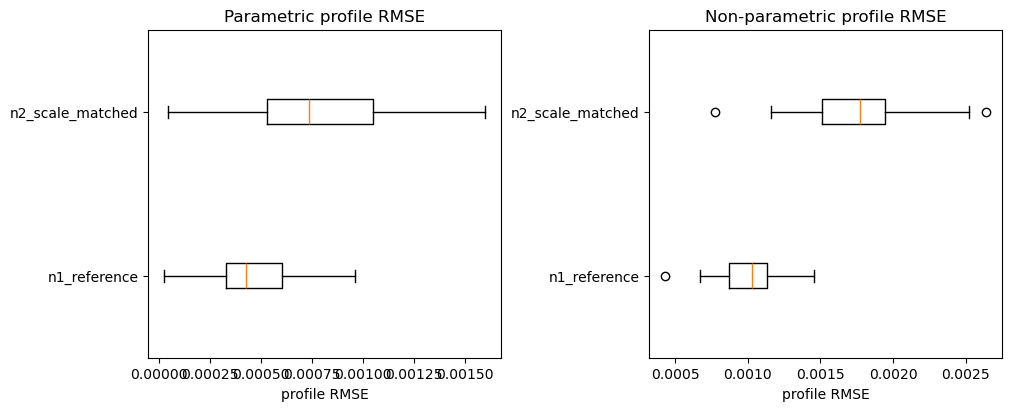

In [105]:
fig,axes=plt.subplots(1,2,figsize=(10,4),constrained_layout=True)
metric_labels={'parametric_profile_RMSE':'Parametric profile RMSE','nonparametric_profile_RMSE':'Non-parametric profile RMSE'}
for ax,metric in zip(axes,['parametric_profile_RMSE','nonparametric_profile_RMSE']):
 vals=[n1_stored[metric],sm_success.set_index('seed')[metric]]; ax.boxplot(vals,vert=False,tick_labels=['n1_reference','n2_scale_matched'],showfliers=True); ax.set(title=metric_labels[metric],xlabel='profile RMSE')
fig.savefig(SCALE_MATCHED_DIR/'scale_matched_profile_rmse.png',dpi=180,bbox_inches='tight'); plt.show()

## Figure 9 — Matched forecast gains

Both formulations forecast volatility, so active-period sigma-space gains can be compared descriptively under the local match.

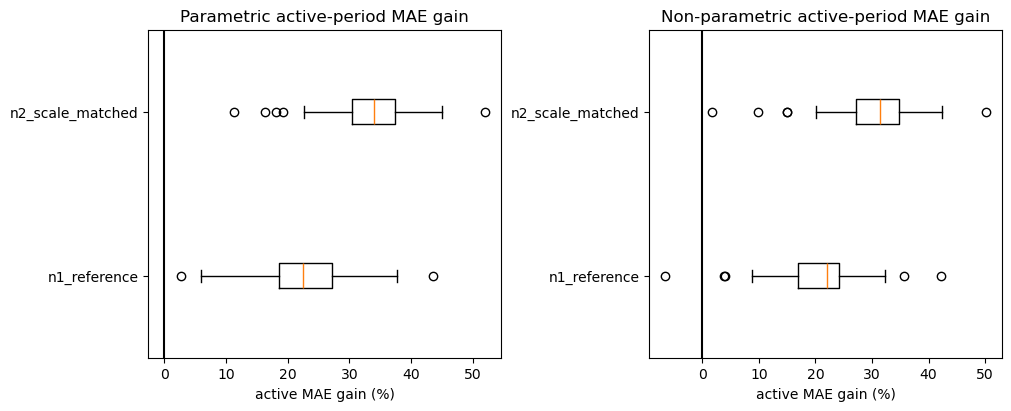

In [106]:
fig,axes=plt.subplots(1,2,figsize=(10,4),constrained_layout=True)
metric_labels={'parametric_active_MAE_gain_pct':'Parametric active-period MAE gain','nonparametric_active_MAE_gain_pct':'Non-parametric active-period MAE gain'}
for ax,metric in zip(axes,['parametric_active_MAE_gain_pct','nonparametric_active_MAE_gain_pct']):
 vals=[n1_stored[metric],sm_success.set_index('seed')[metric]]; ax.boxplot(vals,vert=False,tick_labels=['n1_reference','n2_scale_matched'],showfliers=True); ax.axvline(0,color='black'); ax.set(title=metric_labels[metric],xlabel='active MAE gain (%)')
fig.savefig(SCALE_MATCHED_DIR/'scale_matched_forecast_gains.png',dpi=180,bbox_inches='tight'); plt.show()

## Figure 10 — Paired forecast-gain differences

Same-seed n=2-matched minus n=1 differences reveal whether gain changes persist under matched shocks; zero is the no-difference reference.

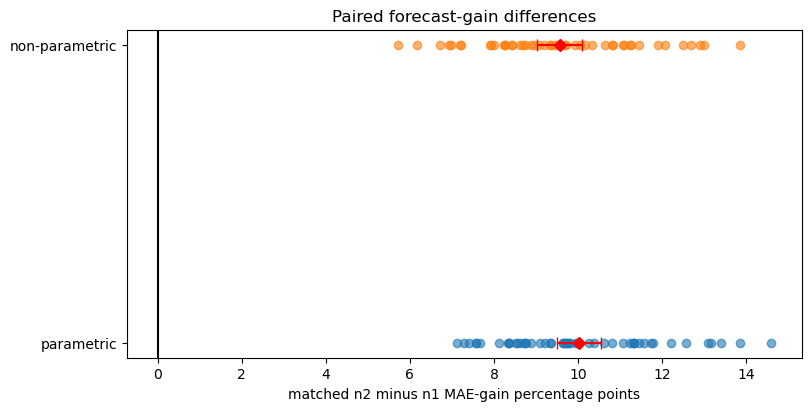

In [107]:
fig,ax=plt.subplots(figsize=(8,4),constrained_layout=True)
for y,metric in enumerate(['parametric_active_MAE_gain_pct','nonparametric_active_MAE_gain_pct']):
 d=scale_matched_paired_contrasts_raw.loc[scale_matched_paired_contrasts_raw.metric.eq(metric),'paired_difference_n2_minus_n1']; s=scale_matched_paired_contrast_summary.loc[scale_matched_paired_contrast_summary.metric.eq(metric)].iloc[0]; ax.scatter(d,np.full(len(d),y),alpha=.6); ax.errorbar(s.mean_difference,y,xerr=[[s.mean_difference-s.ci_95_lower],[s.ci_95_upper-s.mean_difference]],fmt='D',color='red',capsize=4)
ax.axvline(0,color='black'); ax.set(yticks=[0,1],yticklabels=['parametric','non-parametric'],xlabel='matched n2 minus n1 MAE-gain percentage points',title='Paired forecast-gain differences')
fig.savefig(SCALE_MATCHED_DIR/'scale_matched_paired_gain_differences.png',dpi=180,bbox_inches='tight'); plt.show()

## Figure 11 — Mean event-weight profiles

Truth and fitted event-weight profiles retain their common dimensionless interpretation; fitted 5th–95th percentile bands describe seed variation.

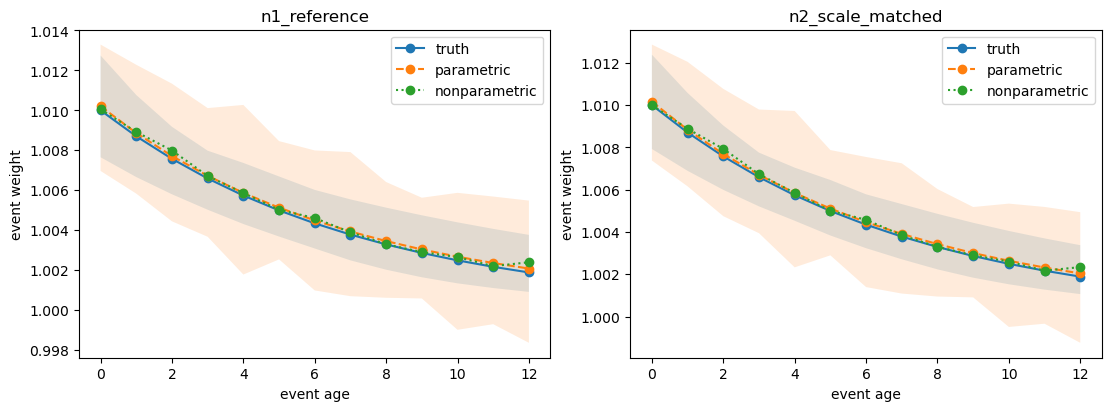

In [108]:
fig,axes=plt.subplots(1,2,figsize=(11,4),constrained_layout=True)
for ax,case in zip(axes,['n1_reference','n2_scale_matched']):
 for method,style in [('truth','-'),('parametric','--'),('nonparametric',':')]:
  d=profile_summary_sm.loc[(profile_summary_sm.case_name.eq(case)) & profile_summary_sm.profile_method.eq(method)].sort_values('event_age'); ax.plot(d.event_age,d['mean'],linestyle=style,marker='o',label=method)
  if method!='truth': ax.fill_between(d.event_age,d.q05,d.q95,alpha=.15)
 ax.set(title=case,xlabel='event age',ylabel='event weight'); ax.legend()
fig.savefig(SCALE_MATCHED_DIR/'scale_matched_event_weight_profiles.png',dpi=180,bbox_inches='tight'); plt.show()

## Scale-matched findings

### Matching validity

The configuration-derived local match used $\sigma_{\rm ref}=0.20$, $\theta_2=0.04$, $\nu_2=0.006$, $\rho_2=-0.35$, and the frozen $\kappa$. Initial and implied target volatility, local innovation scale ($0.015$), correlation, event parameters, timing, and transition count matched exactly. All 100 preflight simulations and all 50 matched n=2 pipelines succeeded; each matched result retained the stored n=1 forecast rows.

### Realised volatility comparability

The algebraic match did not make realised distributions identical. Matched n=2 minus n=1 mean volatility was $0.002385$ (95% Monte Carlo interval $[0.002210,0.002561]$), volatility standard deviation differed by $0.001714$ ($[0.001597,0.001832]$), median volatility by $0.002130$ ($[0.001765,0.002496]$), and the 95th percentile by $0.004700$ ($[0.004287,0.005114]$). The lower-tail difference was small but negative: $-0.000045$ ($[-0.000070,-0.000020]$). Parameter matching must therefore be evaluated against realised paths, not algebraic identities alone.

### Predictive detection and timing

Forward state-change GC detected in all seeds under both formulations. Mean forward state-change partial $R^2$ was $0.1375$ for n=1 and $0.1728$ for the locally matched n=2 formulation; the paired difference was $0.03529$ ($[0.03333,0.03725]$). TDMI change direct-window peaks occurred at $+1$ in 46% of n=1 seeds and 52% of matched n=2 seeds. These remain predictive/dependence diagnostics rather than structural causal identification.

### Event-profile recovery

Amplitude and decay relative errors remained centred near zero for both cases. However, matched n=2 had higher parametric and non-parametric event-weight profile RMSE: paired differences were $0.000338$ ($[0.000289,0.000387]$) and $0.000750$ ($[0.000704,0.000796]$). These profile errors are directly comparable because the event weight is dimensionless and common to both models.

### Forecast performance

Median parametric/non-parametric active MAE gains were $22.42\%/22.04\%$ for n=1 and $34.04\%/31.37\%$ for locally matched n=2. The corresponding paired gain differences were $10.03$ ($[9.51,10.55]$) and $9.56$ percentage points ($[9.03,10.09]$); all matched parametric and non-parametric gains were positive. Absolute sigma-space errors were also lower for the locally matched n=2 formulation. Thus a positive forecast-gain association remains after matching local innovation scale and $\rho_0$, but it is much smaller than in the dedicated-calibration comparison and cannot be attributed solely to n.

### Calibration and interpretation

Parametric 95% state-coverage error showed no clear paired difference: $-0.000176$ ($[-0.002016,0.001664]$). Non-parametric coverage error was higher for locally matched n=2 by $0.004791$ ($[0.002246,0.007336]$). Raw powered-state interval scores are not compared across formulations. The observed differences are associated with the locally scale-matched variance-state formulation; the nonlinear state transformation and locally, but not globally, matched volatility innovation mapping remain part of the experiment.

## Scale-matched limitations

The experiment uses 50 seeds. Its innovation match is first-order and local, so matched n=2 innovation scale varies with volatility; realised distributions may differ and Euler discretisation can affect the transformed state formulations differently. Powered-state errors retain different units, events remain dense and periodic, outcomes are synthetic, parameter interactions are not explored, and this is not interventionist causal identification.

## Scale-matched comparison summary

Notebook 09 now contains the dedicated $n=2$ analysis, the frozen $n=1$ reference and their paired dedicated-calibration comparison, together with the local scale-matched comparison. The targeted $n=2$ robustness section that follows examines how amplitude, innovation scale and decay change recovery, forecasting and calibration under the frozen workflow.

The timing remains $E_i\longrightarrow\omega_{i+1}\longrightarrow X_{i+1}$.

## Targeted n=2 scalar-parameter robustness

This final Notebook 09 experiment changes one scalar at a time around the dedicated n=2 benchmark: event amplitude $A$, powered-state innovation scale $\nu_0$, or event-decay rate $\lambda$. All remaining n=2 model, event-calendar, timing, fitting, forecasting, and evaluation choices remain frozen. The same seed-specific shock bank is used for every case within a seed, and the completed 50-seed `n2_benchmark` results are reused rather than recomputed. No parameter interactions or factorial combinations are studied.

The timing remains $E_i\longrightarrow\omega_{i+1}\longrightarrow X_{i+1}$, with event ages $0,\ldots,12$ corresponding to state lags $+1,\ldots,+13$.

### Construct the six one-at-a-time cases

The six configurations are created from a deep copy of the frozen dedicated n=2 benchmark. Each construction is checked against the expected single override, so the source configuration and all non-varied fields remain unchanged.

In [109]:
targeted_n2_source_snapshot=copy.deepcopy(n2_benchmark_case)
targeted_case_specs=[
    ('n2_amplitude_low','amplitude','low','events.amplitude',0.005),
    ('n2_amplitude_high','amplitude','high','events.amplitude',0.03),
    ('n2_nu_low','innovation_scale','low','model.nu_0',0.001),
    ('n2_nu_high','innovation_scale','high','model.nu_0',0.003),
    ('n2_decay_slow','decay','slow','events.decay_rate',17.5),
    ('n2_decay_fast','decay','fast','events.decay_rate',70.0),
]
def set_nested_value(config,path,value):
    cursor=config
    for key in path.split('.')[:-1]: cursor=cursor[key]
    cursor[path.split('.')[-1]]=value
case_records=[]
for case_name,family,level,path,value in targeted_case_specs:
    expected=copy.deepcopy(targeted_n2_source_snapshot); set_nested_value(expected,path,value); expected['_case_label']=case_name
    config=make_case_config(n2_benchmark_case,{path:value},label=case_name)
    assert config==expected
    case_records.append({'case_name':case_name,'parameter_family':family,'parameter_level':level,'varied_parameter':path,'parameter_value':value,'benchmark_value':targeted_n2_source_snapshot[path.split('.')[0]][path.split('.')[1]],'case_config':config})
targeted_case_registry=pd.DataFrame(case_records)
assert n2_benchmark_case==targeted_n2_source_snapshot
assert set(targeted_case_registry.case_name)=={x[0] for x in targeted_case_specs}
for record in case_records:
    config=record['case_config']; assert config['model']['n']==2
    assert config['model']['theta']==targeted_n2_source_snapshot['model']['theta']
    assert config['model']['rho_0']==targeted_n2_source_snapshot['model']['rho_0']
    assert config['model']['kappa']==targeted_n2_source_snapshot['model']['kappa']
    assert config['simulation']==targeted_n2_source_snapshot['simulation']
    assert derive_timing(config)==derive_timing(targeted_n2_source_snapshot)
assert n2_benchmark_case==targeted_n2_source_snapshot

### Targeted case registry

`implied_target_sigma=\theta^{1/n}` translates the powered-state target into volatility units. For $n=2$, the local volatility innovation scale at the benchmark initial volatility is $\nu_0/(2\sigma_0)$; it is a first-order local interpretation, not a refitted parameter.

In [110]:
targeted_registry_display=pd.DataFrame([{**{k:r[k] for k in ['case_name','parameter_family','parameter_level','varied_parameter','parameter_value','benchmark_value']},'n':r['case_config']['model']['n'],'kappa':r['case_config']['model']['kappa'],'theta_state':r['case_config']['model']['theta'],'nu_state':r['case_config']['model']['nu_0'],'rho_0':r['case_config']['model']['rho_0'],'event_amplitude':r['case_config']['events']['amplitude'],'event_decay_rate':r['case_config']['events']['decay_rate'],'implied_target_sigma':r['case_config']['model']['theta']**(1/r['case_config']['model']['n']),'local_sigma_innovation_scale':r['case_config']['model']['nu_0']/(2*targeted_n2_source_snapshot['simulation']['sigma0'])} for r in case_records])
display(targeted_registry_display)

,case_name,parameter_family,parameter_level,varied_parameter,parameter_value,benchmark_value,n,kappa,theta_state,nu_state,rho_0,event_amplitude,event_decay_rate,implied_target_sigma,local_sigma_innovation_scale
0,n2_amplitude_low,amplitude,low,events.amplitude,0.005,0.010,2,1.5,0.04,0.002,-0.25,0.005,35.0,0.2,0.0050
1,n2_amplitude_high,amplitude,high,events.amplitude,0.030,0.010,2,1.5,0.04,0.002,-0.25,0.030,35.0,0.2,0.0050
2,n2_nu_low,innovation_scale,low,model.nu_0,0.001,0.002,2,1.5,0.04,0.001,-0.25,0.010,35.0,0.2,0.0025
3,n2_nu_high,innovation_scale,high,model.nu_0,0.003,0.002,2,1.5,0.04,0.003,-0.25,0.010,35.0,0.2,0.0075
4,n2_decay_slow,decay,slow,events.decay_rate,17.500,35.000,2,1.5,0.04,0.002,-0.25,0.010,17.5,0.2,0.0050
5,n2_decay_fast,decay,fast,events.decay_rate,70.000,35.000,2,1.5,0.04,0.002,-0.25,0.010,70.0,0.2,0.0050


### Execution controls

The existing deterministic 50-seed set and results directories are reused. Checkpoint-loading mode never silently reruns the 300 new pipelines.

In [111]:
RUN_N2_TARGETED_ROBUSTNESS=False
TARGETED_N2_DIR=RESULTS_DIR/'targeted_n2_robustness'; TARGETED_N2_DIR.mkdir(exist_ok=True)
TARGETED_N2_FIGURES_DIR=TARGETED_N2_DIR/'figures'; TARGETED_N2_FIGURES_DIR.mkdir(exist_ok=True)
TARGETED_RUN_CHECKPOINT=TARGETED_N2_DIR/'targeted_n2_run_checkpoint.csv'
TARGETED_PROFILE_CHECKPOINT=TARGETED_N2_DIR/'targeted_n2_profile_checkpoint.csv'
TARGETED_FAILURE_CHECKPOINT=TARGETED_N2_DIR/'targeted_n2_failure_checkpoint.csv'
TARGETED_PREFLIGHT_CHECKPOINT=TARGETED_N2_DIR/'targeted_n2_simulation_preflight.csv'
assert len(REPLICATION_SEEDS)==N_REPLICATION_SEEDS==50

### One-seed common-shock smoke tests

One shared shock-bank object is passed to the benchmark and all six targeted cases. The tests compare innovations and timing only; they do not require prices, states, or volatility paths to coincide.

In [112]:
TARGETED_PROTOTYPE_SEED=REPLICATION_SEEDS[0]
targeted_prototype_shock_bank=make_shock_bank(n2_benchmark_case,seed=TARGETED_PROTOTYPE_SEED)
targeted_all_case_records=[{'case_name':'n2_benchmark','parameter_family':'benchmark','parameter_level':'benchmark','varied_parameter':'none','parameter_value':'benchmark','benchmark_value':'benchmark','case_config':n2_benchmark_case},*case_records]
targeted_smoke_rows=[]; targeted_smoke_simulations={}
for record in targeted_all_case_records:
    try:
        sim=simulate_case(record['case_config'],shock_bank=targeted_prototype_shock_bank)['simulation']; states,tr=sim['states'],sim['transitions']; timing=derive_timing(record['case_config'])
        assert np.isfinite(states[['S','sigma','x']].to_numpy()).all() and np.isfinite(tr[['F','x_next','sigma_next','omega_next','epsilon','eta']].to_numpy()).all()
        assert states[['S','sigma','x']].gt(0).all().all() and tr[['F','x_next','sigma_next','omega_next']].gt(0).all().all() and tr.omega_next.gt(0).all()
        assert (tr.loc[tr.event.eq(1),'target_i']==tr.loc[tr.event.eq(1),'i']+1).all() and tuple(timing['event_transition_ages'])==tuple(range(13)) and not timing['event_responses_overlap']
        assert np.allclose(states.x,states.sigma**2,rtol=0,atol=1e-12) and np.allclose(tr.x_next,tr.omega_next*tr.F,rtol=0,atol=1e-12)
        targeted_smoke_simulations[record['case_name']]=sim
        row={'case_name':record['case_name'],'parameter_family':record['parameter_family'],'parameter_level':record['parameter_level'],'simulation_success':True,'failure_stage':'','exception_type':'','failure_message':'','minimum_price':states.S.min(),'minimum_sigma':states.sigma.min(),'maximum_sigma':states.sigma.max(),'minimum_state':states.x.min(),'maximum_state':states.x.max(),'minimum_F':tr.F.min(),'state_identity_max_absolute_error':np.max(np.abs(states.x-states.sigma**2)),'transition_identity_max_absolute_error':np.max(np.abs(tr.x_next-tr.omega_next*tr.F))}
    except Exception as exc:
        row={'case_name':record['case_name'],'parameter_family':record['parameter_family'],'parameter_level':record['parameter_level'],'simulation_success':False,'failure_stage':'simulation smoke test','exception_type':type(exc).__name__,'failure_message':str(exc),'minimum_price':np.nan,'minimum_sigma':np.nan,'maximum_sigma':np.nan,'minimum_state':np.nan,'maximum_state':np.nan,'minimum_F':np.nan,'state_identity_max_absolute_error':np.nan,'transition_identity_max_absolute_error':np.nan}
    targeted_smoke_rows.append(row)
if len(targeted_smoke_simulations)==7:
    benchmark_tr=targeted_smoke_simulations['n2_benchmark']['transitions']
    for sim in targeted_smoke_simulations.values():
        tr=sim['transitions']; assert len(tr)==len(benchmark_tr)
        for column in ['epsilon','eta','event','i','target_i']: assert np.array_equal(tr[column].to_numpy(),benchmark_tr[column].to_numpy())
targeted_smoke_table=pd.DataFrame(targeted_smoke_rows)
display(targeted_smoke_table[['case_name','parameter_family','parameter_level','simulation_success','minimum_price','minimum_sigma','maximum_sigma','minimum_state','maximum_state','minimum_F','state_identity_max_absolute_error','transition_identity_max_absolute_error']])
if not targeted_smoke_table.simulation_success.all(): raise RuntimeError('At least one targeted smoke test failed; inspect the displayed failure before repeated execution.')

,case_name,parameter_family,parameter_level,simulation_success,minimum_price,minimum_sigma,maximum_sigma,minimum_state,maximum_state,minimum_F,state_identity_max_absolute_error,transition_identity_max_absolute_error
0,n2_benchmark,benchmark,benchmark,True,80.127606,0.197980,0.268791,0.039196,0.072249,0.039196,1.387779e-17,0.0
1,n2_amplitude_low,amplitude,low,True,82.064440,0.197980,0.229580,0.039196,0.052707,0.039196,6.938894e-18,0.0
2,n2_amplitude_high,amplitude,high,True,67.560640,0.197980,0.673127,0.039196,0.453100,0.039196,5.551115e-17,0.0
3,n2_nu_low,innovation_scale,low,True,80.015923,0.198993,0.268874,0.039598,0.072293,0.039598,1.387779e-17,0.0
4,n2_nu_high,innovation_scale,high,True,80.239350,0.196963,0.268709,0.038794,0.072204,0.038794,1.387779e-17,0.0
5,n2_decay_slow,decay,slow,True,78.462579,0.197980,0.308478,0.039196,0.095158,0.039196,1.387779e-17,0.0
6,n2_decay_fast,decay,fast,True,81.593229,0.197980,0.238334,0.039196,0.056803,0.039196,6.938894e-18,0.0


### One full-pipeline prototype per new case

Each new case is run once with the same prototype shock bank. The existing benchmark prototype supplies the ordered test identifiers; no benchmark pipeline is recomputed here.

In [113]:
targeted_prototype_rows=[]; targeted_prototype_failures=[]
targeted_prototype_forecast_ids=n2_prototype_result['forecasts'][['i','target_i']].reset_index(drop=True)
for record in case_records:
    started=perf_counter()
    try:
        result=run_full_pipeline(record['case_config'],shock_bank=targeted_prototype_shock_bank,include_causality=True,include_intervals=True,include_truth=True)
    except Exception as exc:
        targeted_prototype_failures.append({**{k:record[k] for k in ['case_name','parameter_family','parameter_level']},'failure_stage':'pipeline','exception_type':type(exc).__name__,'failure_message':str(exc)}); continue
    try:
        summary=summarise_case(result); ids=result['forecasts'][['i','target_i']].reset_index(drop=True)
        assert ids.equals(targeted_prototype_forecast_ids) and set(result['profiles']['nonparametric'].index)==set(range(13))
        assert (result['profiles']['parametric_multiplier'](np.arange(13))>0).all() and result['profiles']['nonparametric'].reindex(np.arange(13)).gt(0).all()
        intervals=result['evaluation']['intervals']; pairs=[(c,c.replace('lower_','upper_',1)) for c in intervals if c.startswith('lower_') and c.replace('lower_','upper_',1) in intervals]
        assert pairs and all((intervals[a]<=intervals[b]).all() for a,b in pairs)
        coverage=summary[[c for c in summary.index if c.endswith('_coverage')]].astype(float)
        assert coverage.between(0,1).all() and bool(summary['profile_converged']) and 'forecasts_frozen' in result['pipeline_stages']
        row=extract_repeated_run_summary(result,summary,record['case_config'],record['case_name'],'targeted n=2 one-at-a-time scalar variation',TARGETED_PROTOTYPE_SEED,True,perf_counter()-started)
        row.update({k:record[k] for k in ['parameter_family','parameter_level','varied_parameter','parameter_value','benchmark_value']}); targeted_prototype_rows.append(row)
    except Exception as exc:
        targeted_prototype_failures.append({**{k:record[k] for k in ['case_name','parameter_family','parameter_level']},'failure_stage':'summary, forecast-row validation, or extraction','exception_type':type(exc).__name__,'failure_message':str(exc)})
targeted_prototype_table=pd.DataFrame(targeted_prototype_rows)
if targeted_prototype_failures: display(pd.DataFrame(targeted_prototype_failures))
assert len(targeted_prototype_table)==6 and not targeted_prototype_failures
display(targeted_prototype_table[['case_name','parameter_family','parameter_level','A_true','A_hat','lambda_true','lambda_hat','parametric_profile_RMSE','nonparametric_profile_RMSE','gc_forward_change_p_value','tdmi_change_direct_peak_lag','parametric_active_MAE_gain_pct','nonparametric_active_MAE_gain_pct','parametric_active_95_state_coverage','known_dgp_active_state_RMSE']])

,case_name,parameter_family,parameter_level,A_true,A_hat,lambda_true,lambda_hat,parametric_profile_RMSE,nonparametric_profile_RMSE,gc_forward_change_p_value,tdmi_change_direct_peak_lag,parametric_active_MAE_gain_pct,nonparametric_active_MAE_gain_pct,parametric_active_95_state_coverage,known_dgp_active_state_RMSE
0,n2_amplitude_low,amplitude,low,0.005,0.004462,35.0,35.798691,0.000321,0.000887,4.355878e-13,1.0,39.732241,37.745338,0.945055,0.000115
1,n2_amplitude_high,amplitude,high,0.030,0.029616,35.0,34.712587,0.000170,0.020991,3.026150e-107,13.0,97.764365,-7.852114,0.923077,0.000116
2,n2_nu_low,innovation_scale,low,0.010,0.009753,35.0,35.046384,0.000140,0.003590,6.533219e-111,1.0,85.370271,38.763060,0.934066,0.000058
3,n2_nu_high,innovation_scale,high,0.010,0.009251,35.0,35.189172,0.000427,0.001710,2.925762e-27,1.0,59.051443,52.014314,0.945055,0.000173
4,n2_decay_slow,decay,slow,0.010,0.009613,17.5,17.316902,0.000252,0.005845,7.987513e-56,1.0,83.217180,33.008251,0.945055,0.000115
5,n2_decay_fast,decay,fast,0.010,0.009322,70.0,70.687669,0.000303,0.001268,3.503413e-42,1.0,53.674325,50.994107,0.934066,0.000115


### 50-seed simulation-only preflight

For each seed, one common shock bank is generated and passed to all seven n=2 cases. A failed simulation remains an explicit diagnostic row and only successful new seed-case combinations are eligible for the pipeline loop.

In [114]:
preflight_rows=[]
for seed in REPLICATION_SEEDS:
    try:
        common_shock_bank=make_shock_bank(n2_benchmark_case,seed=seed)
    except Exception as exc:
        for r in targeted_all_case_records: preflight_rows.append({'seed':seed,**{k:r[k] for k in ['case_name','parameter_family','parameter_level','varied_parameter','parameter_value']},'simulation_success':False,'failure_stage':'shock bank','exception_type':type(exc).__name__,'failure_message':str(exc)})
        continue
    seed_simulations={}
    for r in targeted_all_case_records:
        try:
            sim=simulate_case(r['case_config'],shock_bank=common_shock_bank)['simulation']; states,tr=sim['states'],sim['transitions']; seed_simulations[r['case_name']]=sim
            row={'seed':seed,**{k:r[k] for k in ['case_name','parameter_family','parameter_level','varied_parameter','parameter_value']},'simulation_success':True,'failure_stage':'','exception_type':'','failure_message':'','minimum_price':states.S.min(),'maximum_price':states.S.max(),'minimum_sigma':states.sigma.min(),'maximum_sigma':states.sigma.max(),'mean_sigma':states.sigma.mean(),'standard_deviation_sigma':states.sigma.std(ddof=1),'q05_sigma':states.sigma.quantile(.05),'median_sigma':states.sigma.median(),'q95_sigma':states.sigma.quantile(.95),'minimum_state':states.x.min(),'maximum_state':states.x.max(),'minimum_F':tr.F.min(),'all_finite':np.isfinite(states[['S','sigma','x']].to_numpy()).all() and np.isfinite(tr[['F','x_next','sigma_next','omega_next','epsilon','eta']].to_numpy()).all(),'all_prices_positive':states.S.gt(0).all(),'all_states_positive':states.x.gt(0).all(),'all_transition_quantities_positive':tr[['F','x_next','sigma_next','omega_next']].gt(0).all().all(),'state_identity_max_absolute_error':np.max(np.abs(states.x-states.sigma**2)),'transition_identity_max_absolute_error':np.max(np.abs(tr.x_next-tr.omega_next*tr.F))}
        except Exception as exc:
            row={'seed':seed,**{k:r[k] for k in ['case_name','parameter_family','parameter_level','varied_parameter','parameter_value']},'simulation_success':False,'failure_stage':'simulation','exception_type':type(exc).__name__,'failure_message':str(exc)}
        preflight_rows.append(row)
    if len(seed_simulations)==7:
        benchmark_tr=seed_simulations['n2_benchmark']['transitions']
        for sim in seed_simulations.values():
            tr=sim['transitions']; assert len(tr)==len(benchmark_tr)
            for column in ['epsilon','eta','event','i','target_i']: assert np.array_equal(tr[column].to_numpy(),benchmark_tr[column].to_numpy())
            assert (tr.loc[tr.event.eq(1),'target_i']==tr.loc[tr.event.eq(1),'i']+1).all()
targeted_preflight=pd.DataFrame(preflight_rows)
assert len(targeted_preflight)==350 and not targeted_preflight.duplicated(['seed','case_name']).any()
targeted_preflight.to_csv(TARGETED_PREFLIGHT_CHECKPOINT,index=False)
targeted_preflight.to_csv(TARGETED_N2_DIR/'notebook09_targeted_n2_simulation_preflight.csv',index=False)
targeted_preflight_status=pd.DataFrame([{'planned_simulations':350,'successful_simulations':int(targeted_preflight.simulation_success.sum()),'failed_simulations':int((~targeted_preflight.simulation_success).sum()),'success_rate':targeted_preflight.simulation_success.mean()}])
targeted_preflight_case_rates=targeted_preflight.groupby('case_name').simulation_success.agg(['count','sum','mean']).rename(columns={'count':'planned_simulations','sum':'successful_simulations','mean':'success_rate'}).reset_index()
display(targeted_preflight_status); display(targeted_preflight_case_rates)

,planned_simulations,successful_simulations,failed_simulations,success_rate
0,350,350,0,1.0


,case_name,planned_simulations,successful_simulations,success_rate
0,n2_amplitude_high,50,50,1.0
1,n2_amplitude_low,50,50,1.0
2,n2_benchmark,50,50,1.0
3,n2_decay_fast,50,50,1.0
4,n2_decay_slow,50,50,1.0
5,n2_nu_high,50,50,1.0
6,n2_nu_low,50,50,1.0


### Repeated-run design

The stored `repeated_results` and `repeated_profiles` already contain 50 completed `n2_benchmark` pipelines under the deterministic seeds used here. Regenerating `make_shock_bank(n2_benchmark_case, seed=seed)` reproduces that seed's benchmark shocks. The benchmark is therefore reused; only six targeted pipelines run per seed, and each new case is paired with its stored benchmark by seed.

### Execute or load the 300 new targeted pipelines

Every successful new seed-case contributes one run-level row and 39 profile rows. Failures are recorded with their actual stage and exception; loading mode raises a clear error if a checkpoint is absent.

In [115]:
def targeted_failure_row(seed,r,stage,exc,elapsed):
    return {'seed':seed,'case_name':r['case_name'],'n':2,'state_interpretation':'variance','calibration_interpretation':'targeted n=2 one-at-a-time scalar variation','run_success':False,'profile_converged':np.nan,'common_test_rows':np.nan,'failure_stage':stage,'exception_type':type(exc).__name__,'failure_message':str(exc),'seed_elapsed_seconds_at_case_completion':elapsed,**{k:r[k] for k in ['parameter_family','parameter_level','varied_parameter','parameter_value','benchmark_value']}}
def write_targeted_checkpoints(rows,profiles,failures):
    pd.DataFrame(rows).to_csv(TARGETED_RUN_CHECKPOINT,index=False)
    pd.DataFrame(profiles).to_csv(TARGETED_PROFILE_CHECKPOINT,index=False)
    pd.DataFrame(failures,columns=['seed','case_name','n','parameter_family','parameter_level','failure_stage','exception_type','failure_message','seed_elapsed_seconds_at_case_completion']).to_csv(TARGETED_FAILURE_CHECKPOINT,index=False)
def target_failure_output(row):
    return {k:row[k] for k in ['seed','case_name','n','parameter_family','parameter_level','failure_stage','exception_type','failure_message','seed_elapsed_seconds_at_case_completion']}

### Execute or load the targeted repeated experiment

When execution is enabled, each seed generates one common shock bank and runs the six targeted \(n=2\) cases. Each successful case contributes one run-level row and 39 event-profile rows, while failures are retained explicitly. In checkpoint-loading mode, the completed results are loaded without rerunning any full pipeline.

In [116]:
if RUN_N2_TARGETED_ROBUSTNESS:
    targeted_rows=[]; targeted_profile_rows=[]; targeted_failure_rows=[]
    eligible=set(map(tuple,targeted_preflight.loc[targeted_preflight.simulation_success,['seed','case_name']].to_numpy()))
    for position,seed in enumerate(REPLICATION_SEEDS,1):
        started=perf_counter()
        try:
            common_shock_bank=make_shock_bank(n2_benchmark_case,seed=seed)
        except Exception as exc:
            for r in case_records:
                row=targeted_failure_row(seed,r,'shock bank',exc,perf_counter()-started); targeted_rows.append(row); targeted_failure_rows.append(target_failure_output(row))
        else:
            for r in case_records:
                if (seed,r['case_name']) not in eligible:
                    row=targeted_failure_row(seed,r,'preflight',RuntimeError('simulation preflight failed for this seed-case combination'),perf_counter()-started); targeted_rows.append(row); targeted_failure_rows.append(target_failure_output(row)); continue
                try:
                    result=run_full_pipeline(r['case_config'],shock_bank=common_shock_bank,include_causality=True,include_intervals=True,include_truth=True)
                except Exception as exc:
                    row=targeted_failure_row(seed,r,'pipeline',exc,perf_counter()-started)
                else:
                    try:
                        summary=summarise_case(result)
                    except Exception as exc:
                        row=targeted_failure_row(seed,r,'summary',exc,perf_counter()-started)
                    else:
                        try:
                            assert result['forecasts'][['i','target_i']].reset_index(drop=True).equals(targeted_prototype_forecast_ids)
                        except Exception as exc:
                            row=targeted_failure_row(seed,r,'forecast-row validation',exc,perf_counter()-started)
                        else:
                            try:
                                row=extract_repeated_run_summary(result,summary,r['case_config'],r['case_name'],'targeted n=2 one-at-a-time scalar variation',seed,True,perf_counter()-started); row['seed_elapsed_seconds_at_case_completion']=row.pop('seed_pair_runtime_seconds'); row.update({k:r[k] for k in ['parameter_family','parameter_level','varied_parameter','parameter_value','benchmark_value']})
                            except Exception as exc:
                                row=targeted_failure_row(seed,r,'run extraction',exc,perf_counter()-started)
                            else:
                                try:
                                    profiles=extract_repeated_profile_rows(result,r['case_config'],r['case_name'],seed); assert len(profiles)==39
                                    targeted_profile_rows.extend([{**profile,**{k:r[k] for k in ['parameter_family','parameter_level','varied_parameter','parameter_value','benchmark_value']}} for profile in profiles])
                                except Exception as exc:
                                    row=targeted_failure_row(seed,r,'profile extraction',exc,perf_counter()-started)
                                else:
                                    targeted_rows.append(row); continue
                targeted_rows.append(row); targeted_failure_rows.append(target_failure_output(row))
        write_targeted_checkpoints(targeted_rows,targeted_profile_rows,targeted_failure_rows)
        print(f'Targeted n=2 seed {position}/50 | successful new runs: {sum(row.get("run_success",False) for row in targeted_rows)}/{len(targeted_rows)}')
    targeted_results=pd.DataFrame(targeted_rows); targeted_profiles=pd.DataFrame(targeted_profile_rows); targeted_failures=pd.DataFrame(targeted_failure_rows)
else:
    missing=[x for x in [TARGETED_RUN_CHECKPOINT,TARGETED_PROFILE_CHECKPOINT,TARGETED_FAILURE_CHECKPOINT] if not x.exists()]
    if missing: raise FileNotFoundError(f'Targeted n=2 checkpoint-loading mode requires: {missing}')
    targeted_results=pd.read_csv(TARGETED_RUN_CHECKPOINT); targeted_profiles=pd.read_csv(TARGETED_PROFILE_CHECKPOINT)
    try: targeted_failures=pd.read_csv(TARGETED_FAILURE_CHECKPOINT)
    except pd.errors.EmptyDataError: targeted_failures=pd.DataFrame(columns=['seed','case_name','n','parameter_family','parameter_level','failure_stage','exception_type','failure_message','seed_elapsed_seconds_at_case_completion'])
    targeted_schema_updated=False
    if 'seed_runtime_seconds' in targeted_results.columns:
        targeted_results=targeted_results.rename(columns={'seed_runtime_seconds':'seed_elapsed_seconds_at_case_completion'})
        targeted_schema_updated=True
    if 'seed_runtime_seconds' in targeted_failures.columns:
        targeted_failures=targeted_failures.rename(columns={'seed_runtime_seconds':'seed_elapsed_seconds_at_case_completion'})
        targeted_schema_updated=True
    if targeted_schema_updated:
        write_targeted_checkpoints(targeted_results.to_dict('records'),targeted_profiles.to_dict('records'),targeted_failures.to_dict('records'))

### Finalise and validate the raw targeted results

The checks use actual success counts per case, rather than assuming every case completed identically.

In [117]:
case_order=[r['case_name'] for r in case_records]
targeted_results=targeted_results.sort_values(['seed','parameter_family','parameter_level','case_name']).reset_index(drop=True)
targeted_profiles=targeted_profiles.sort_values(['seed','parameter_family','parameter_level','case_name','profile_method','event_age']).reset_index(drop=True)
targeted_success=targeted_results.loc[targeted_results.run_success.eq(True)].copy()
assert len(targeted_results)==300 and not targeted_results.duplicated(['seed','case_name']).any()
assert targeted_results.groupby('case_name').size().reindex(case_order).eq(50).all() and targeted_success.common_test_rows.eq(True).all() and targeted_success.profile_converged.eq(True).all()
coverage_columns=[c for c in targeted_success if c.endswith('_coverage')]; score_columns=[c for c in targeted_success if c.endswith('_interval_score')]
assert targeted_success[coverage_columns].apply(lambda v:v.dropna().between(0,1).all()).all() and targeted_success[score_columns].apply(lambda v:v.dropna().ge(0).all()).all()
assert not targeted_profiles.duplicated(['seed','case_name','event_age','profile_method']).any() and set(targeted_profiles.event_age)==set(range(13)) and set(targeted_profiles.profile_method)=={'truth','parametric','nonparametric'}
assert np.allclose(targeted_profiles.state_multiplier,targeted_profiles.event_weight**(targeted_profiles.n/2),rtol=0,atol=1e-12) and np.allclose(targeted_profiles.volatility_multiplier,np.sqrt(targeted_profiles.event_weight),rtol=0,atol=1e-12) and targeted_profiles[['event_weight','state_multiplier','volatility_multiplier']].gt(0).all().all()
success_count_by_case=targeted_success.groupby('case_name').size().reindex(case_order,fill_value=0); profile_count_by_case=targeted_profiles.groupby('case_name').size().reindex(case_order,fill_value=0)
assert profile_count_by_case.equals((39*success_count_by_case).rename_axis('case_name'))
if len(targeted_profiles): assert targeted_profiles.groupby(['seed','case_name']).size().eq(39).all()
targeted_results.to_csv(TARGETED_N2_DIR/'notebook09_targeted_n2_run_results.csv',index=False); targeted_profiles.to_csv(TARGETED_N2_DIR/'notebook09_targeted_n2_profiles.csv',index=False); targeted_failures.to_csv(TARGETED_N2_DIR/'notebook09_targeted_n2_failures.csv',index=False)
targeted_execution_status=pd.DataFrame([{'case_name':r['case_name'],'planned_runs':50,'successful_runs':int(success_count_by_case.loc[r['case_name']]),'failed_runs':int(50-success_count_by_case.loc[r['case_name']]),'success_rate':success_count_by_case.loc[r['case_name']]/50,'profile_rows':int(profile_count_by_case.loc[r['case_name']])} for r in case_records]); display(targeted_execution_status)

,case_name,planned_runs,successful_runs,failed_runs,success_rate,profile_rows
0,n2_amplitude_low,50,50,0,1.0,1950
1,n2_amplitude_high,50,50,0,1.0,1950
2,n2_nu_low,50,50,0,1.0,1950
3,n2_nu_high,50,50,0,1.0,1950
4,n2_decay_slow,50,50,0,1.0,1950
5,n2_decay_fast,50,50,0,1.0,1950


### Combine with the stored n=2 benchmark

The primary raw exports contain only new cases. A separate analysis frame repeats the stored benchmark only within each family-specific comparison, leaving `repeated_results` and `repeated_profiles` unchanged.

In [118]:
benchmark_results=repeated_results.loc[(repeated_results.case_name.eq('n2_benchmark')) & repeated_results.run_success.eq(True)].copy(); benchmark_profiles=repeated_profiles.loc[repeated_profiles.case_name.eq('n2_benchmark')].copy()
assert len(benchmark_results)==50 and not benchmark_results.seed.duplicated().any() and len(benchmark_profiles)==1950 and not benchmark_profiles.duplicated(['seed','event_age','profile_method']).any()
benchmark_metadata={'parameter_family':'benchmark','parameter_level':'benchmark','varied_parameter':'none','parameter_value':'benchmark','benchmark_value':'benchmark'}
for key,value in benchmark_metadata.items(): benchmark_results[key]=value; benchmark_profiles[key]=value
targeted_results_with_benchmark=pd.concat([benchmark_results,targeted_success],ignore_index=True,sort=False); targeted_profiles_with_benchmark=pd.concat([benchmark_profiles,targeted_profiles],ignore_index=True,sort=False)
assert set(benchmark_results.seed)==set(REPLICATION_SEEDS)
family_case_order={'amplitude':['n2_amplitude_low','n2_benchmark','n2_amplitude_high'],'innovation_scale':['n2_nu_low','n2_benchmark','n2_nu_high'],'decay':['n2_decay_slow','n2_benchmark','n2_decay_fast']}
family_frames=[]; family_profile_frames=[]; family_paths={'amplitude':'events.amplitude','innovation_scale':'model.nu_0','decay':'events.decay_rate'}
for family,ordered in family_case_order.items():
    new=targeted_success.loc[targeted_success.parameter_family.eq(family)].copy(); bench=benchmark_results.copy(); bench['parameter_family']=family; bench['parameter_level']='benchmark'; bench['varied_parameter']=family_paths[family]; bench['parameter_value']={'amplitude':n2_benchmark_case['events']['amplitude'],'innovation_scale':n2_benchmark_case['model']['nu_0'],'decay':n2_benchmark_case['events']['decay_rate']}[family]; bench['benchmark_value']=bench['parameter_value']; family_frames.append(pd.concat([new,bench],ignore_index=True,sort=False))
    new_profiles=targeted_profiles.loc[targeted_profiles.parameter_family.eq(family)].copy(); bp=benchmark_profiles.copy()
    for key in ['parameter_family','parameter_level','varied_parameter','parameter_value','benchmark_value']: bp[key]=bench.iloc[0][key]
    family_profile_frames.append(pd.concat([new_profiles,bp],ignore_index=True,sort=False))
targeted_family_results=pd.concat(family_frames,ignore_index=True,sort=False); targeted_family_profiles=pd.concat(family_profile_frames,ignore_index=True,sort=False)
assert targeted_family_results.groupby(['parameter_family','case_name']).size().eq(50).all() and targeted_family_profiles.groupby(['parameter_family','case_name']).size().eq(1950).all()

### Derived indicators and numeric/rate summaries

Indicators use the frozen Notebook 09 definitions. Positive `parametric_profile_advantage` means lower parametric profile RMSE; it is descriptive rather than a significance test.

In [119]:
def add_targeted_indicators(frame):
    frame=frame.copy()
    frame['gc_forward_change_detected_5pct']=np.where(frame.gc_forward_change_p_value.notna(),frame.gc_forward_change_p_value.lt(.05),np.nan)
    frame['tdmi_change_peak_at_plus_1']=np.where(frame.tdmi_change_direct_peak_lag.notna(),frame.tdmi_change_direct_peak_lag.eq(1),np.nan)
    frame['parametric_positive_MAE_gain']=np.where(frame.parametric_active_MAE_gain_pct.notna(),frame.parametric_active_MAE_gain_pct.gt(0),np.nan)
    frame['nonparametric_positive_MAE_gain']=np.where(frame.nonparametric_active_MAE_gain_pct.notna(),frame.nonparametric_active_MAE_gain_pct.gt(0),np.nan)
    frame['parametric_95_state_coverage_error']=(frame.parametric_active_95_state_coverage-.95).abs(); frame['nonparametric_95_state_coverage_error']=(frame.nonparametric_active_95_state_coverage-.95).abs(); frame['known_dgp_95_state_coverage_error']=(frame.known_dgp_active_95_state_coverage-.95).abs()
    frame['parametric_profile_advantage']=frame.nonparametric_profile_RMSE-frame.parametric_profile_RMSE
    return frame
targeted_results=add_targeted_indicators(targeted_results); targeted_results_with_benchmark=add_targeted_indicators(targeted_results_with_benchmark); targeted_family_results=add_targeted_indicators(targeted_family_results)
summary_keys=['parameter_family','case_name','parameter_level','parameter_value']
targeted_metrics=['conditional_partial_r_squared','gc_forward_level_partial_r_squared','gc_forward_change_partial_r_squared','tdmi_level_direct_peak','tdmi_change_direct_peak','A_hat','A_relative_error','lambda_hat','lambda_relative_error','parametric_profile_MAE','parametric_profile_RMSE','nonparametric_profile_MAE','nonparametric_profile_RMSE','parametric_profile_advantage','baseline_active_sigma_MAE','baseline_active_sigma_RMSE','parametric_active_sigma_MAE','parametric_active_sigma_RMSE','nonparametric_active_sigma_MAE','nonparametric_active_sigma_RMSE','parametric_active_MAE_gain_pct','parametric_active_RMSE_gain_pct','nonparametric_active_MAE_gain_pct','nonparametric_active_RMSE_gain_pct','parametric_active_95_state_coverage','parametric_95_state_coverage_error','parametric_active_95_state_interval_score','nonparametric_active_95_state_coverage','nonparametric_95_state_coverage_error','nonparametric_active_95_state_interval_score','known_dgp_active_95_state_coverage','known_dgp_95_state_coverage_error','known_dgp_active_95_state_interval_score','known_dgp_active_state_MAE','known_dgp_active_state_RMSE']
targeted_numeric_summary=pd.DataFrame([{**dict(zip(summary_keys,keys)),'metric':metric,**summarise_numeric_series(group[metric])} for keys,group in targeted_family_results.groupby(summary_keys) for metric in targeted_metrics])
rate_metrics=['gc_forward_change_detected_5pct','tdmi_change_peak_at_plus_1','parametric_positive_MAE_gain','nonparametric_positive_MAE_gain']
targeted_rate_summary=pd.DataFrame([{**dict(zip(summary_keys,keys)),'metric':metric,**summarise_binary_series(group[metric])} for keys,group in targeted_family_results.groupby(summary_keys) for metric in rate_metrics])
targeted_numeric_summary.to_csv(TARGETED_N2_DIR/'notebook09_targeted_n2_numeric_summary.csv',index=False); targeted_rate_summary.to_csv(TARGETED_N2_DIR/'notebook09_targeted_n2_rate_summary.csv',index=False); targeted_results.to_csv(TARGETED_N2_DIR/'notebook09_targeted_n2_run_results.csv',index=False)

### Same-seed paired contrasts and aggregate event profiles

Each new case is paired with the stored benchmark on seed. State-space units are common because all cases use $n=2$.

In [120]:
paired_metrics=['conditional_partial_r_squared','gc_forward_level_partial_r_squared','gc_forward_change_partial_r_squared','tdmi_level_direct_peak','tdmi_change_direct_peak','A_relative_error','lambda_relative_error','parametric_profile_RMSE','nonparametric_profile_RMSE','baseline_active_sigma_MAE','baseline_active_sigma_RMSE','parametric_active_sigma_MAE','parametric_active_sigma_RMSE','nonparametric_active_sigma_MAE','nonparametric_active_sigma_RMSE','parametric_active_MAE_gain_pct','parametric_active_RMSE_gain_pct','nonparametric_active_MAE_gain_pct','nonparametric_active_RMSE_gain_pct','parametric_95_state_coverage_error','nonparametric_95_state_coverage_error','known_dgp_95_state_coverage_error','parametric_active_95_state_interval_score','nonparametric_active_95_state_interval_score','known_dgp_active_95_state_interval_score','known_dgp_active_state_MAE','known_dgp_active_state_RMSE']
benchmark_indexed=add_targeted_indicators(benchmark_results).set_index('seed'); assert len(benchmark_indexed)==50 and not benchmark_indexed.index.duplicated().any()
paired_rows=[]
for r in case_records:
    case=add_targeted_indicators(targeted_success.loc[targeted_success.case_name.eq(r['case_name'])]).set_index('seed'); paired=benchmark_indexed[paired_metrics].join(case[paired_metrics],lsuffix='_benchmark',rsuffix='_case',how='inner'); assert len(paired)==len(case) and not paired.index.duplicated().any()
    for metric in paired_metrics:
        paired_rows.extend({'seed':seed,'parameter_family':r['parameter_family'],'case_name':r['case_name'],'parameter_level':r['parameter_level'],'parameter_value':r['parameter_value'],'metric':metric,'benchmark_value':row[metric+'_benchmark'],'case_value':row[metric+'_case'],'paired_difference_case_minus_benchmark':row[metric+'_case']-row[metric+'_benchmark']} for seed,row in paired.iterrows())
targeted_paired_contrasts_raw=pd.DataFrame(paired_rows)
targeted_paired_contrast_summary=pd.DataFrame([{**dict(zip(summary_keys,keys)),'metric':metric,**{('mean_difference' if key=='mean' else 'median_difference' if key=='median' else key):value for key,value in summarise_numeric_series(group.paired_difference_case_minus_benchmark).items()}} for (*keys,metric),group in targeted_paired_contrasts_raw.groupby(summary_keys+['metric'])])
profile_keys=['parameter_family','case_name','parameter_level','parameter_value','profile_method','event_age']
targeted_profile_summary=pd.DataFrame([{**dict(zip(profile_keys,keys)),**{f'{metric}_{stat}':value for metric in ['event_weight','state_multiplier','volatility_multiplier'] for stat,value in {'count':len(group[metric]),'mean':group[metric].mean(),'median':group[metric].median(),'q05':group[metric].quantile(.05),'q25':group[metric].quantile(.25),'q75':group[metric].quantile(.75),'q95':group[metric].quantile(.95)}.items()}} for keys,group in targeted_family_profiles.groupby(profile_keys)])
assert targeted_profile_summary.groupby(['parameter_family','case_name','profile_method']).size().eq(13).all()
for family,case_name in targeted_family_results[['parameter_family','case_name']].drop_duplicates().itertuples(index=False):
    expected=len(targeted_family_results.loc[(targeted_family_results.parameter_family.eq(family)) & targeted_family_results.case_name.eq(case_name)]); assert targeted_family_profiles.loc[(targeted_family_profiles.parameter_family.eq(family)) & targeted_family_profiles.case_name.eq(case_name)].groupby('profile_method').size().eq(expected*13).all()
targeted_paired_contrasts_raw.to_csv(TARGETED_N2_DIR/'notebook09_targeted_n2_paired_contrasts_raw.csv',index=False); targeted_paired_contrast_summary.to_csv(TARGETED_N2_DIR/'notebook09_targeted_n2_paired_contrast_summary.csv',index=False); targeted_profile_summary.to_csv(TARGETED_N2_DIR/'notebook09_targeted_n2_profile_summary.csv',index=False)

### Realised volatility distributions and compact tables

The simulation-only preflight quantifies same-seed differences from the benchmark because changes in $A$, $\nu_0$, and $\lambda$ also change the realised volatility distribution.

In [121]:
targeted_preflight_success=targeted_preflight.loc[targeted_preflight.simulation_success].copy(); benchmark_preflight=targeted_preflight_success.loc[targeted_preflight_success.case_name.eq('n2_benchmark')].set_index('seed')
sigma_metrics=['mean_sigma','standard_deviation_sigma','q05_sigma','median_sigma','q95_sigma']; sigma_rows=[]
for r in case_records:
    case=targeted_preflight_success.loc[targeted_preflight_success.case_name.eq(r['case_name'])].set_index('seed'); paired=benchmark_preflight[sigma_metrics].join(case[sigma_metrics],lsuffix='_benchmark',rsuffix='_case',how='inner'); assert len(paired)==len(case) and not paired.index.duplicated().any()
    for metric in sigma_metrics: sigma_rows.append({'parameter_family':r['parameter_family'],'case_name':r['case_name'],'parameter_level':r['parameter_level'],'parameter_value':r['parameter_value'],'metric':metric,**{('mean_difference' if key=='mean' else 'median_difference' if key=='median' else key):value for key,value in summarise_numeric_series(paired[metric+'_case']-paired[metric+'_benchmark']).items()}})
targeted_sigma_distribution_contrasts=pd.DataFrame(sigma_rows); targeted_sigma_distribution_contrasts.to_csv(TARGETED_N2_DIR/'notebook09_targeted_n2_sigma_distribution_contrasts.csv',index=False)
def metric_stat(metric,stat): return targeted_numeric_summary.loc[targeted_numeric_summary.metric.eq(metric),summary_keys+[stat]].rename(columns={stat:metric})
def rate_stat(metric,label): return targeted_rate_summary.loc[targeted_rate_summary.metric.eq(metric),summary_keys+['rate','ci_95_lower','ci_95_upper']].rename(columns={'rate':label,'ci_95_lower':label+'_Wilson_lower','ci_95_upper':label+'_Wilson_upper'})
targeted_detection_display=rate_stat('gc_forward_change_detected_5pct','forward_GC_detection_rate').merge(rate_stat('tdmi_change_peak_at_plus_1','TDMI_plus_1_rate'),on=summary_keys)
targeted_recovery_display=metric_stat('A_relative_error','median').merge(metric_stat('lambda_relative_error','median'),on=summary_keys).merge(metric_stat('parametric_profile_RMSE','median'),on=summary_keys).merge(metric_stat('nonparametric_profile_RMSE','median'),on=summary_keys)
targeted_forecast_display=metric_stat('parametric_active_MAE_gain_pct','median').merge(rate_stat('parametric_positive_MAE_gain','parametric_positive_gain_rate'),on=summary_keys).merge(metric_stat('nonparametric_active_MAE_gain_pct','median'),on=summary_keys).merge(rate_stat('nonparametric_positive_MAE_gain','nonparametric_positive_gain_rate'),on=summary_keys)
targeted_calibration_display=metric_stat('parametric_active_95_state_coverage','mean').merge(metric_stat('parametric_95_state_coverage_error','mean'),on=summary_keys).merge(metric_stat('nonparametric_active_95_state_coverage','mean'),on=summary_keys).merge(metric_stat('nonparametric_95_state_coverage_error','mean'),on=summary_keys)
main_metrics=['conditional_partial_r_squared','parametric_profile_RMSE','nonparametric_profile_RMSE','parametric_active_MAE_gain_pct','nonparametric_active_MAE_gain_pct','parametric_95_state_coverage_error','nonparametric_95_state_coverage_error']
targeted_main_contrasts=targeted_paired_contrast_summary.loc[targeted_paired_contrast_summary.metric.isin(main_metrics),summary_keys+['metric','mean_difference','ci_95_lower','ci_95_upper','median_difference']]
display(targeted_execution_status); display(targeted_detection_display); display(targeted_recovery_display); display(targeted_forecast_display); display(targeted_calibration_display)
for family in family_case_order: display(targeted_main_contrasts.loc[targeted_main_contrasts.parameter_family.eq(family)])

,case_name,planned_runs,successful_runs,failed_runs,success_rate,profile_rows
0,n2_amplitude_low,50,50,0,1.0,1950
1,n2_amplitude_high,50,50,0,1.0,1950
2,n2_nu_low,50,50,0,1.0,1950
3,n2_nu_high,50,50,0,1.0,1950
4,n2_decay_slow,50,50,0,1.0,1950
5,n2_decay_fast,50,50,0,1.0,1950


,parameter_family,case_name,parameter_level,parameter_value,forward_GC_detection_rate,forward_GC_detection_rate_Wilson_lower,forward_GC_detection_rate_Wilson_upper,TDMI_plus_1_rate,TDMI_plus_1_rate_Wilson_lower,TDMI_plus_1_rate_Wilson_upper
0,amplitude,n2_amplitude_high,high,0.030,1.0,0.928652,1.0,0.00,6.938894e-18,0.071348
1,amplitude,n2_amplitude_low,low,0.005,1.0,0.928652,1.0,0.68,5.418970e-01,0.792418
2,amplitude,n2_benchmark,benchmark,0.010,1.0,0.928652,1.0,0.94,8.378291e-01,0.979385
3,decay,n2_benchmark,benchmark,35.000,1.0,0.928652,1.0,0.94,8.378291e-01,0.979385
4,decay,n2_decay_fast,fast,70.000,1.0,0.928652,1.0,1.00,9.286524e-01,1.000000
5,decay,n2_decay_slow,slow,17.500,1.0,0.928652,1.0,0.84,7.148578e-01,0.916626
6,innovation_scale,n2_benchmark,benchmark,0.002,1.0,0.928652,1.0,0.94,8.378291e-01,0.979385
7,innovation_scale,n2_nu_high,high,0.003,1.0,0.928652,1.0,0.86,7.381381e-01,0.930492
8,innovation_scale,n2_nu_low,low,0.001,1.0,0.928652,1.0,1.00,9.286524e-01,1.000000


,parameter_family,case_name,parameter_level,parameter_value,A_relative_error,lambda_relative_error,parametric_profile_RMSE,nonparametric_profile_RMSE
0,amplitude,n2_amplitude_high,high,0.030,0.000367,-0.002738,0.000162,0.000381
1,amplitude,n2_amplitude_low,low,0.005,-0.003964,0.001191,0.000296,0.000709
2,amplitude,n2_benchmark,benchmark,0.010,-0.000932,-0.000461,0.000263,0.000620
3,decay,n2_benchmark,benchmark,35.000,-0.000932,-0.000461,0.000263,0.000620
4,decay,n2_decay_fast,fast,70.000,-0.006487,-0.005907,0.000281,0.000682
5,decay,n2_decay_slow,slow,17.500,0.003113,-0.006563,0.000241,0.000554
6,innovation_scale,n2_benchmark,benchmark,0.002,-0.000932,-0.000461,0.000263,0.000620
7,innovation_scale,n2_nu_high,high,0.003,-0.002489,-0.000563,0.000391,0.000924
8,innovation_scale,n2_nu_low,low,0.001,-0.000132,-0.000214,0.000133,0.000310


,parameter_family,case_name,parameter_level,parameter_value,parametric_active_MAE_gain_pct,parametric_positive_gain_rate,parametric_positive_gain_rate_Wilson_lower,parametric_positive_gain_rate_Wilson_upper,nonparametric_active_MAE_gain_pct,nonparametric_positive_gain_rate,nonparametric_positive_gain_rate_Wilson_lower,nonparametric_positive_gain_rate_Wilson_upper
0,amplitude,n2_amplitude_high,high,0.030,97.868234,1.0,0.928652,1.0,97.144568,1.0,0.928652,1.0
1,amplitude,n2_amplitude_low,low,0.005,36.450231,1.0,0.928652,1.0,35.101780,1.0,0.928652,1.0
2,amplitude,n2_benchmark,benchmark,0.010,71.507180,1.0,0.928652,1.0,70.027592,1.0,0.928652,1.0
3,decay,n2_benchmark,benchmark,35.000,71.507180,1.0,0.928652,1.0,70.027592,1.0,0.928652,1.0
4,decay,n2_decay_fast,fast,70.000,51.739643,1.0,0.928652,1.0,50.742963,1.0,0.928652,1.0
5,decay,n2_decay_slow,slow,17.500,83.426911,1.0,0.928652,1.0,82.293582,1.0,0.928652,1.0
6,innovation_scale,n2_benchmark,benchmark,0.002,71.507180,1.0,0.928652,1.0,70.027592,1.0,0.928652,1.0
7,innovation_scale,n2_nu_high,high,0.003,59.165432,1.0,0.928652,1.0,57.279422,1.0,0.928652,1.0
8,innovation_scale,n2_nu_low,low,0.001,85.454389,1.0,0.928652,1.0,84.740328,1.0,0.928652,1.0


,parameter_family,case_name,parameter_level,parameter_value,parametric_active_95_state_coverage,parametric_95_state_coverage_error,nonparametric_active_95_state_coverage,nonparametric_95_state_coverage_error
0,amplitude,n2_amplitude_high,high,0.030,0.901099,0.054198,0.794286,0.155714
1,amplitude,n2_amplitude_low,low,0.005,0.945714,0.022681,0.933187,0.023912
2,amplitude,n2_benchmark,benchmark,0.010,0.942857,0.023297,0.927253,0.029560
3,decay,n2_benchmark,benchmark,35.000,0.942857,0.023297,0.927253,0.029560
4,decay,n2_decay_fast,fast,70.000,0.943077,0.022198,0.932747,0.023912
5,decay,n2_decay_slow,slow,17.500,0.940220,0.024967,0.920879,0.034374
6,innovation_scale,n2_benchmark,benchmark,0.002,0.942857,0.023297,0.927253,0.029560
7,innovation_scale,n2_nu_high,high,0.003,0.943956,0.023516,0.927912,0.028264
8,innovation_scale,n2_nu_low,low,0.001,0.941758,0.023473,0.926813,0.030000


,parameter_family,case_name,parameter_level,parameter_value,metric,mean_difference,ci_95_lower,ci_95_upper,median_difference
3,amplitude,n2_amplitude_high,high,0.030,conditional_partial_r_squared,0.129333,0.122360,0.136306,0.127982
11,amplitude,n2_amplitude_high,high,0.030,nonparametric_95_state_coverage_error,0.126154,0.109396,0.142911,0.115385
13,amplitude,n2_amplitude_high,high,0.030,nonparametric_active_MAE_gain_pct,27.244454,26.473470,28.015438,26.672225
17,amplitude,n2_amplitude_high,high,0.030,nonparametric_profile_RMSE,-0.000238,-0.000256,-0.000220,-0.000235
18,amplitude,n2_amplitude_high,high,0.030,parametric_95_state_coverage_error,0.030901,0.014271,0.047531,0.010989
20,amplitude,n2_amplitude_high,high,0.030,parametric_active_MAE_gain_pct,26.614363,25.911348,27.317378,26.336931
24,amplitude,n2_amplitude_high,high,0.030,parametric_profile_RMSE,-0.000112,-0.000131,-0.000093,-0.000104
30,amplitude,n2_amplitude_low,low,0.005,conditional_partial_r_squared,-0.373492,-0.379125,-0.367858,-0.371975
38,amplitude,n2_amplitude_low,low,0.005,nonparametric_95_state_coverage_error,-0.005648,-0.008952,-0.002345,0.000000
40,amplitude,n2_amplitude_low,low,0.005,nonparametric_active_MAE_gain_pct,-36.053750,-37.482303,-34.625198,-35.437371


,parameter_family,case_name,parameter_level,parameter_value,metric,mean_difference,ci_95_lower,ci_95_upper,median_difference
111,innovation_scale,n2_nu_high,high,0.003,conditional_partial_r_squared,-0.182453,-0.186435,-0.178471,-0.180118
119,innovation_scale,n2_nu_high,high,0.003,nonparametric_95_state_coverage_error,-0.001297,-0.002925,0.000331,0.000000
121,innovation_scale,n2_nu_high,high,0.003,nonparametric_active_MAE_gain_pct,-13.424357,-13.998074,-12.850641,-12.910906
125,innovation_scale,n2_nu_high,high,0.003,nonparametric_profile_RMSE,0.000306,0.000288,0.000323,0.000305
126,innovation_scale,n2_nu_high,high,0.003,parametric_95_state_coverage_error,0.000220,-0.000776,0.001215,0.000000
128,innovation_scale,n2_nu_high,high,0.003,parametric_active_MAE_gain_pct,-12.855239,-13.382668,-12.327810,-12.550687
132,innovation_scale,n2_nu_high,high,0.003,parametric_profile_RMSE,0.000139,0.000121,0.000158,0.000127
138,innovation_scale,n2_nu_low,low,0.001,conditional_partial_r_squared,0.206947,0.201905,0.211988,0.203307
146,innovation_scale,n2_nu_low,low,0.001,nonparametric_95_state_coverage_error,0.000440,-0.000179,0.001058,0.000000
148,innovation_scale,n2_nu_low,low,0.001,nonparametric_active_MAE_gain_pct,14.858493,14.370898,15.346088,14.556381


,parameter_family,case_name,parameter_level,parameter_value,metric,mean_difference,ci_95_lower,ci_95_upper,median_difference
57,decay,n2_decay_fast,fast,70.0,conditional_partial_r_squared,-0.111439,-0.114585,-0.108294,-0.112540
65,decay,n2_decay_fast,fast,70.0,nonparametric_95_state_coverage_error,-0.005648,-0.008499,-0.002798,0.000000
67,decay,n2_decay_fast,fast,70.0,nonparametric_active_MAE_gain_pct,-20.224525,-20.880891,-19.568159,-19.753790
71,decay,n2_decay_fast,fast,70.0,nonparametric_profile_RMSE,0.000068,0.000062,0.000073,0.000070
72,decay,n2_decay_fast,fast,70.0,parametric_95_state_coverage_error,-0.001099,-0.003318,0.001120,0.000000
74,decay,n2_decay_fast,fast,70.0,parametric_active_MAE_gain_pct,-19.886467,-20.490774,-19.282161,-19.525295
78,decay,n2_decay_fast,fast,70.0,parametric_profile_RMSE,0.000024,0.000012,0.000036,0.000029
84,decay,n2_decay_slow,slow,17.5,conditional_partial_r_squared,0.093333,0.090394,0.096271,0.092546
92,decay,n2_decay_slow,slow,17.5,nonparametric_95_state_coverage_error,0.004813,0.001975,0.007651,0.000000
94,decay,n2_decay_slow,slow,17.5,nonparametric_active_MAE_gain_pct,12.464039,12.054832,12.873246,12.153059


### Figures 12-15 - Detection, recovery, forecasting, and calibration

The benchmark is repeated only within each family panel, providing low/benchmark/high or slow/benchmark/fast references for the one-at-a-time contrasts.

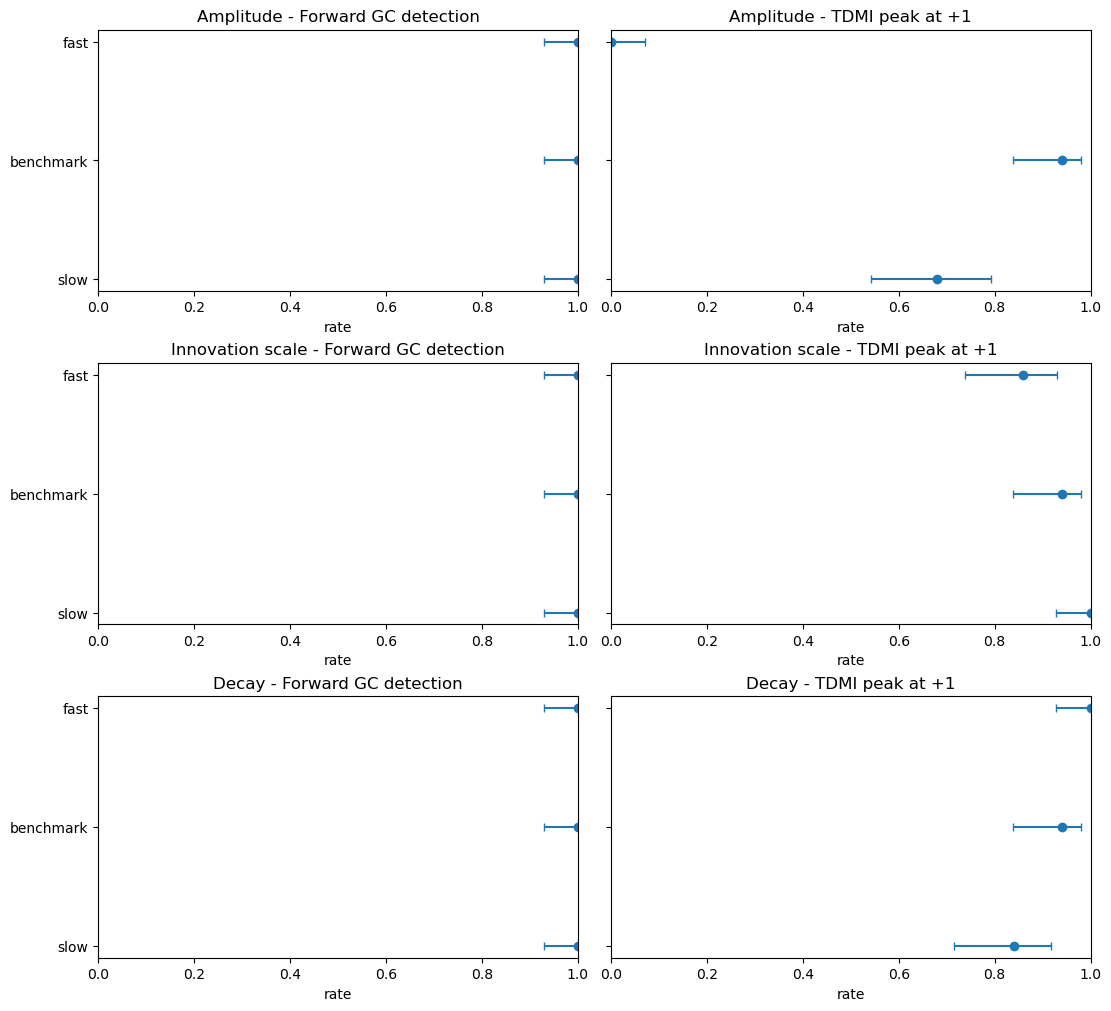

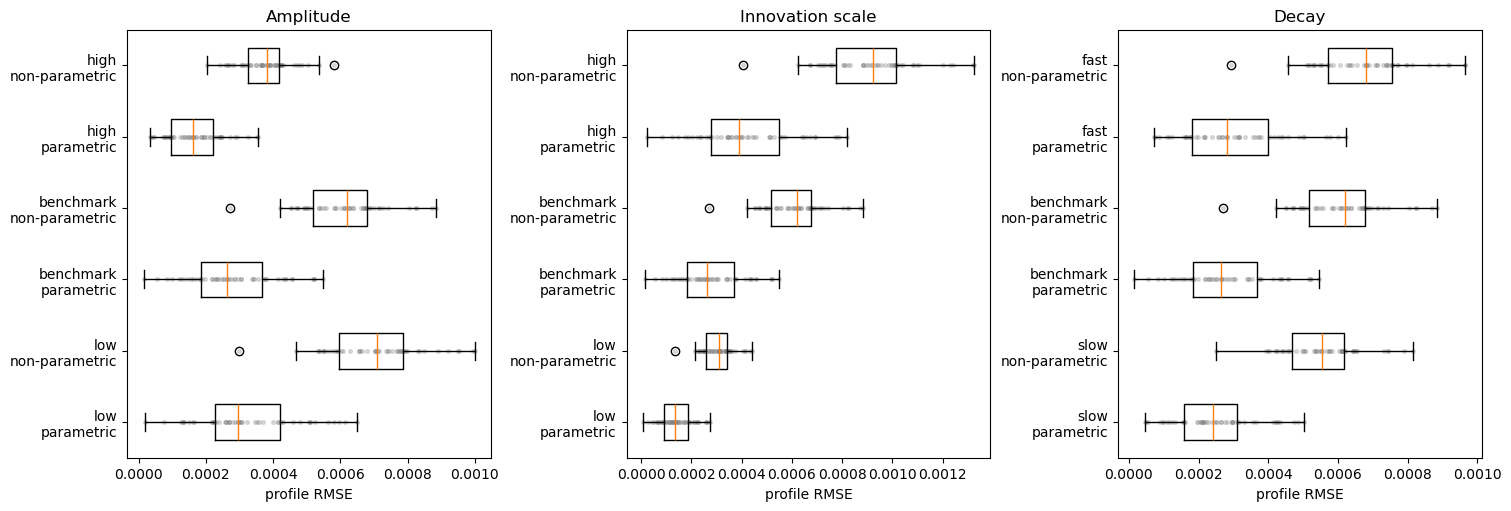

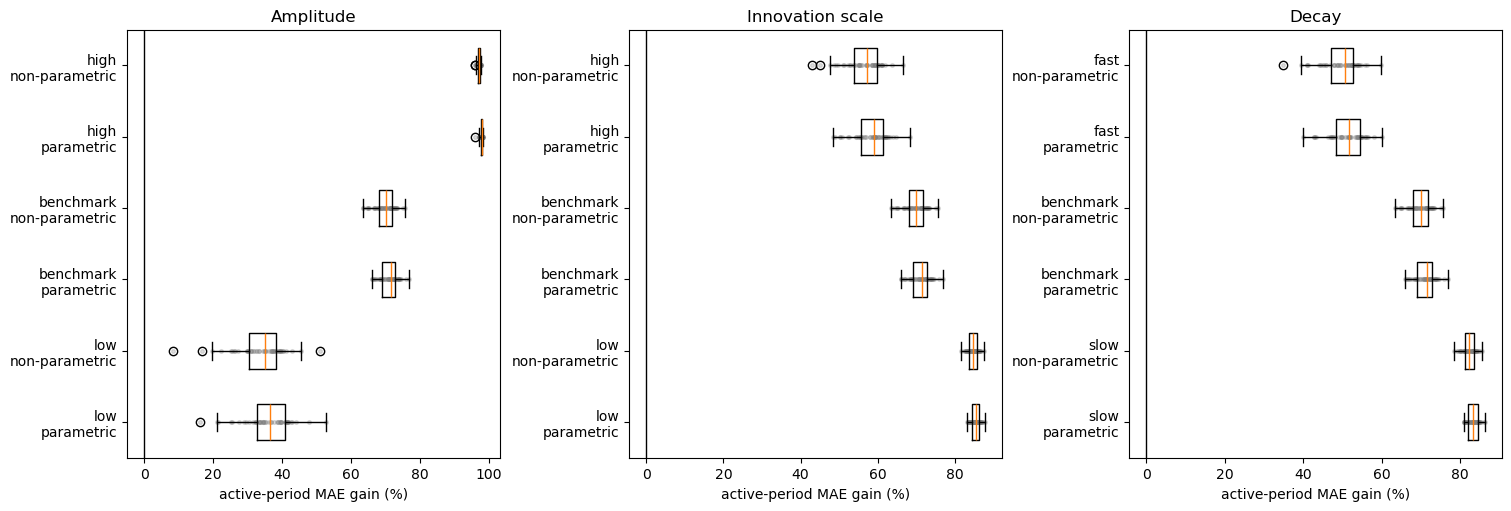

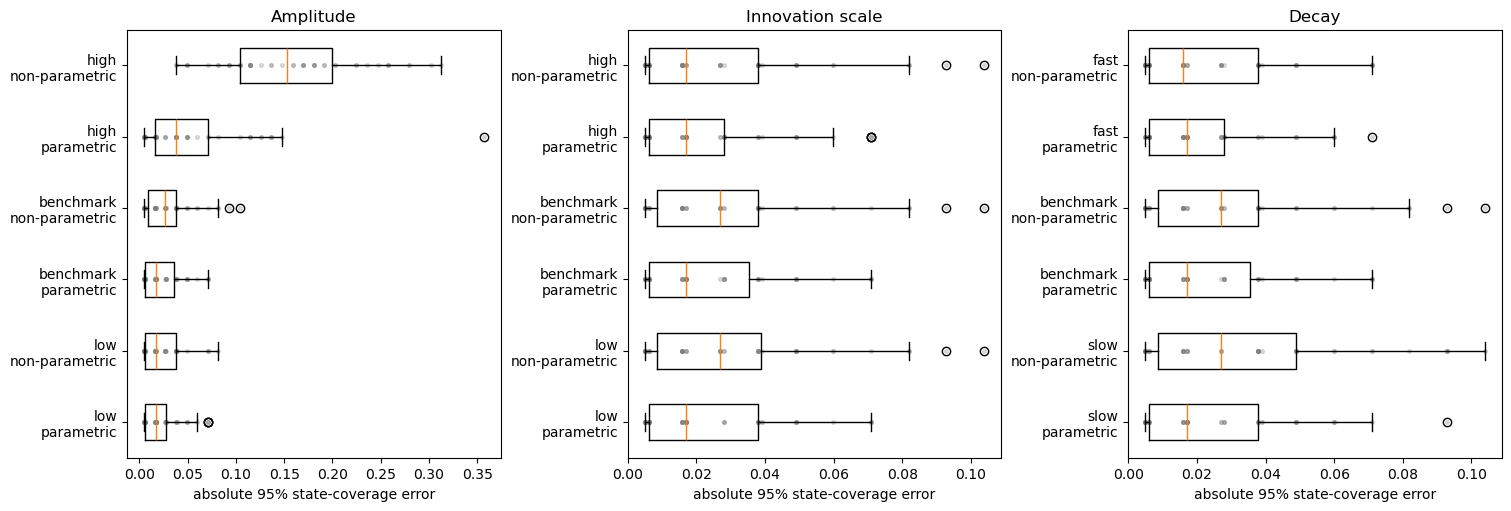

In [122]:
family_labels={'amplitude':'Amplitude','innovation_scale':'Innovation scale','decay':'Decay'}; level_labels={'low':'low','benchmark':'benchmark','high':'high','slow':'slow','fast':'fast'}
fig,axes=plt.subplots(3,2,figsize=(11,10),sharey=True,constrained_layout=True)
for row,(family,ordered) in enumerate(family_case_order.items()):
    rates=targeted_rate_summary.loc[targeted_rate_summary.parameter_family.eq(family)]
    for col,(metric,title) in enumerate([('gc_forward_change_detected_5pct','Forward GC detection'),('tdmi_change_peak_at_plus_1','TDMI peak at +1')]):
        ax=axes[row,col]; data=rates.loc[rates.metric.eq(metric)].set_index('case_name').loc[ordered]; y=np.arange(3)
        ax.errorbar(data.rate,y,xerr=[np.maximum(0,data.rate-data.ci_95_lower),np.maximum(0,data.ci_95_upper-data.rate)],fmt='o',capsize=3); ax.set(xlim=(0,1),yticks=y,yticklabels=[level_labels[data.loc[name,'parameter_level']] for name in ordered],title=f'{family_labels[family]} - {title}',xlabel='rate')
fig.savefig(TARGETED_N2_FIGURES_DIR/'targeted_n2_detection_timing.png',dpi=180,bbox_inches='tight'); plt.show()
def family_boxplot(metrics,names,xlabel,filename,zero=False):
    fig,axes=plt.subplots(1,3,figsize=(15,5),constrained_layout=True)
    for ax,(family,ordered) in zip(axes,family_case_order.items()):
        frame=targeted_family_results.loc[targeted_family_results.parameter_family.eq(family)]; values=[]; labels=[]
        for case_name in ordered:
            level=level_labels[frame.loc[frame.case_name.eq(case_name),'parameter_level'].iloc[0]]
            for metric,name in zip(metrics,names): values.append(frame.loc[frame.case_name.eq(case_name),metric].dropna()); labels.append(f'{level}\n{name}')
        ax.boxplot(values,vert=False,tick_labels=labels,showfliers=True)
        for pos,value in enumerate(values,1): ax.scatter(value,np.full(len(value),pos),s=7,alpha=.25,color='tab:gray')
        if zero: ax.axvline(0,color='black',linewidth=1)
        ax.set(title=family_labels[family],xlabel=xlabel)
    fig.savefig(TARGETED_N2_FIGURES_DIR/filename,dpi=180,bbox_inches='tight'); plt.show()
family_boxplot(['parametric_profile_RMSE','nonparametric_profile_RMSE'],['parametric','non-parametric'],'profile RMSE','targeted_n2_profile_rmse.png')
family_boxplot(['parametric_active_MAE_gain_pct','nonparametric_active_MAE_gain_pct'],['parametric','non-parametric'],'active-period MAE gain (%)','targeted_n2_forecast_gains.png',True)
family_boxplot(['parametric_95_state_coverage_error','nonparametric_95_state_coverage_error'],['parametric','non-parametric'],'absolute 95% state-coverage error','targeted_n2_state_coverage_error.png')

### Figures 16-18 - Parameter recovery, event-weight profiles, and realised volatility

For amplitude and decay the true event profiles vary by construction. For the innovation-scale family the true profile remains common, while fitted profiles may change with signal-to-noise.

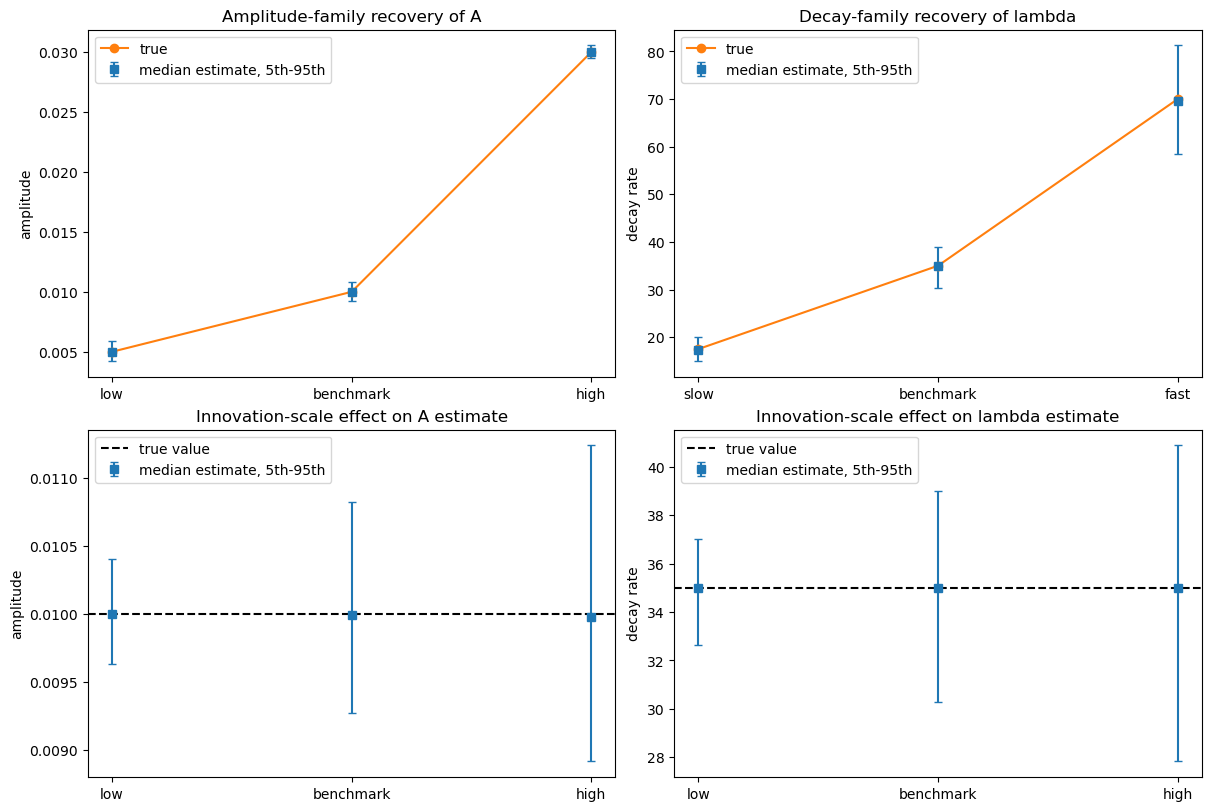

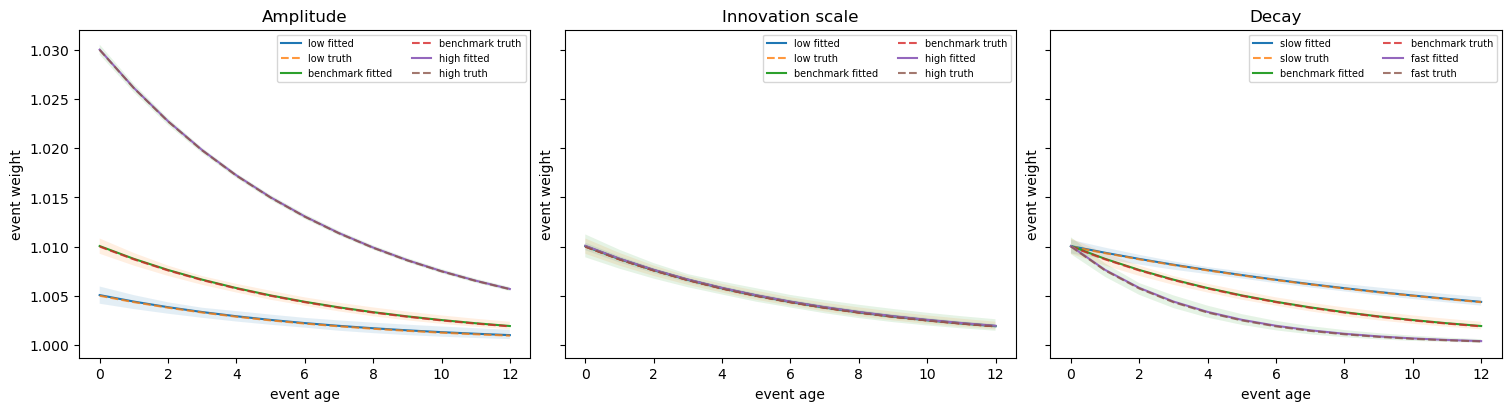

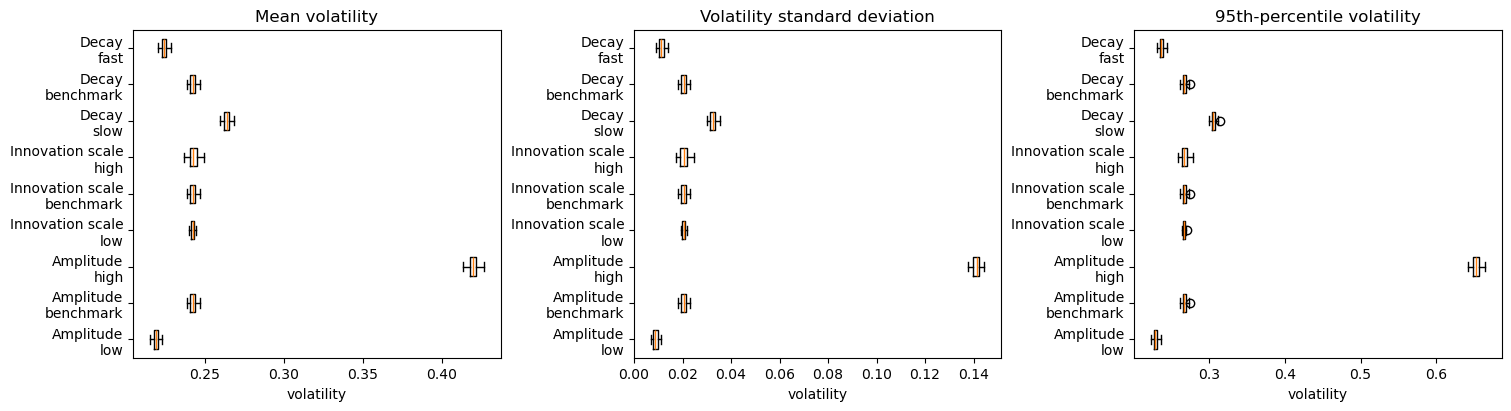

In [123]:
fig,axes=plt.subplots(2,2,figsize=(12,8),constrained_layout=True)
def recovery_panel(ax,family,estimate,true_column,title,ylabel,reference_line=False):
    frame=targeted_family_results.loc[targeted_family_results.parameter_family.eq(family)]
    ordered=family_case_order[family]; groups=frame.groupby('case_name'); x=np.arange(len(ordered))
    median=np.array([groups.get_group(name)[estimate].median() for name in ordered])
    low=np.array([groups.get_group(name)[estimate].quantile(.05) for name in ordered])
    high=np.array([groups.get_group(name)[estimate].quantile(.95) for name in ordered])
    ax.errorbar(x,median,yerr=[median-low,high-median],fmt='s',capsize=3,label='median estimate, 5th-95th')
    if reference_line:
        ax.axhline(frame[true_column].iloc[0],color='black',linestyle='--',label='true value')
    else:
        truth=np.array([groups.get_group(name)[true_column].iloc[0] for name in ordered])
        ax.plot(x,truth,'o-',label='true')
    ax.set(xticks=x,xticklabels=[level_labels[frame.loc[frame.case_name.eq(name),'parameter_level'].iloc[0]] for name in ordered],title=title,ylabel=ylabel)
    ax.legend()
recovery_panel(axes[0,0],'amplitude','A_hat','A_true','Amplitude-family recovery of A','amplitude')
recovery_panel(axes[0,1],'decay','lambda_hat','lambda_true','Decay-family recovery of lambda','decay rate')
recovery_panel(axes[1,0],'innovation_scale','A_hat','A_true','Innovation-scale effect on A estimate','amplitude',reference_line=True)
recovery_panel(axes[1,1],'innovation_scale','lambda_hat','lambda_true','Innovation-scale effect on lambda estimate','decay rate',reference_line=True)
fig.savefig(TARGETED_N2_FIGURES_DIR/'targeted_n2_parameter_recovery.png',dpi=180,bbox_inches='tight'); plt.show()
fig,axes=plt.subplots(1,3,figsize=(15,4),sharey=True,constrained_layout=True)
for ax,(family,ordered) in zip(axes,family_case_order.items()):
    data=targeted_profile_summary.loc[targeted_profile_summary.parameter_family.eq(family)]
    for case_name in ordered:
        level=level_labels[data.loc[data.case_name.eq(case_name),'parameter_level'].iloc[0]]; fit=data.loc[(data.case_name.eq(case_name)) & data.profile_method.eq('parametric')].sort_values('event_age'); truth=data.loc[(data.case_name.eq(case_name)) & data.profile_method.eq('truth')].sort_values('event_age')
        ax.plot(fit.event_age,fit.event_weight_mean,label=f'{level} fitted'); ax.fill_between(fit.event_age,fit.event_weight_q05,fit.event_weight_q95,alpha=.12); ax.plot(truth.event_age,truth.event_weight_mean,'--',alpha=.8,label=f'{level} truth')
    ax.set(title=family_labels[family],xlabel='event age',ylabel='event weight'); ax.legend(fontsize=7,ncol=2)
fig.savefig(TARGETED_N2_FIGURES_DIR/'targeted_n2_event_weight_profiles.png',dpi=180,bbox_inches='tight'); plt.show()
fig,axes=plt.subplots(1,3,figsize=(15,4),constrained_layout=True)
for ax,metric,label in zip(axes,['mean_sigma','standard_deviation_sigma','q95_sigma'],['Mean volatility','Volatility standard deviation','95th-percentile volatility']):
    values=[]; labels=[]
    for family,ordered in family_case_order.items():
        for case_name in ordered:
            case_frame=targeted_preflight_success.loc[targeted_preflight_success.case_name.eq(case_name)]
            level='benchmark' if case_name=='n2_benchmark' else case_frame.parameter_level.iloc[0]
            values.append(case_frame[metric]); labels.append(f'{family_labels[family]}\n{level_labels[level]}')
    ax.boxplot(values,vert=False,tick_labels=labels,showfliers=True); ax.set(title=label,xlabel='volatility')
fig.savefig(TARGETED_N2_FIGURES_DIR/'targeted_n2_sigma_distributions.png',dpi=180,bbox_inches='tight'); plt.show()

## Targeted n=2 scalar-parameter robustness findings

### Numerical robustness

All 350 simulation-only attempts succeeded. All 300 new full pipelines completed, retained the common benchmark test identifiers, converged in both profile fits, and generated 11,700 event-profile rows (39 per successful seed-case). No simulation or pipeline failures clustered by case.

### Event amplitude

Forward state-change GC was detected in every seed at all three amplitude levels. Median parametric active-MAE gain rose from 36.45% at $A=0.005$, through 71.51% at the benchmark, to 97.87% at $A=0.03$; the paired high-minus-benchmark gain difference was 26.61 percentage points (95% Monte Carlo interval [25.91, 27.32]). The corresponding low-minus-benchmark difference was -35.26 points [-36.60, -33.92]. Higher amplitude also increased forward change-GC partial $R^2$ by 0.2029 [0.1943, 0.2116], reduced parametric profile RMSE by 0.00011 [-0.00013, -0.00009], but worsened parametric state-coverage error by 0.0309 [0.0143, 0.0475]. It materially increased realised volatility: the paired mean-volatility difference was 0.1773 [0.1769, 0.1777]. This makes the response easier to predict, not intrinsically better.

TDMI $+1$ timing was not monotonic in amplitude: its rate was 68% at low amplitude, 94% at benchmark, and 0% at high amplitude. Thus high GC detection alone should not be read as successful recovery of one individual lag.

### Innovation scale

Lower innovation scale strengthened the event signal: its forward change-GC partial-$R^2$ contrast was 0.2375 [0.2330, 0.2421], parametric profile RMSE fell by 0.00014 [-0.00016, -0.00012], and median parametric gain rose to 85.45% (+14.22 points [13.77, 14.67]). Higher innovation scale reduced partial $R^2$ by 0.1404 [-0.1424, -0.1384], raised profile RMSE by 0.00014 [0.00012, 0.00016], and lowered median parametric gain to 59.17% (-12.86 points [-13.38, -12.33]). TDMI $+1$ rates were 100% and 86%, respectively. The paired realised-volatility distribution changes were small at this scale, but Known-DGP state RMSE was lower under low $\nu_0$ and higher under high $\nu_0$, consistent with altered innovation noise.

### Decay rate

Slower decay increased persistence and strengthened the average response: the forward change-GC partial-$R^2$ contrast was 0.0263 [0.0234, 0.0291], parametric profile RMSE fell by 0.00003 [-0.00004, -0.00002], and median parametric gain was 83.43% (+12.17 points [11.80, 12.55]). Faster decay reduced partial $R^2$ by 0.0433 [-0.0453, -0.0412], raised profile RMSE by 0.00002 [0.00001, 0.00004], and lowered median gain to 51.74% (-19.89 points [-20.49, -19.28]). TDMI $+1$ rates were 84% for slow and 100% for fast decay, so GC history order should not be interpreted as a single recovered event lag. Slow/fast decay also changed paired mean volatility by +0.02137 and -0.01810, respectively.

### Cross-family interpretation

The tested amplitude range had the largest effect on realised volatility, predictive structure, gains, and calibration. Innovation scale most directly controlled signal-to-noise and profile recovery, while decay governed persistence and the distribution of response across ages. Parametric event profiles had lower RMSE than non-parametric profiles throughout the tested cases, and both event-aware forecasts had positive active-MAE gains in every seed. Calibration was broadly stable outside the high-amplitude case, where increased coverage error is material.

### Robustness conclusion and limitations

The dedicated n=2 conclusions are robust across the tested scalar range in the limited sense that simulations and pipeline fits remained successful, forward GC was detected in every seed, and event-aware active-window forecasts retained positive gains. The magnitude of those gains, profile recovery, TDMI timing, and calibration are nevertheless sensitive to $A$, $\nu_0$, and $\lambda$. This remains a synthetic 50-seed, one-at-a-time experiment with no interactions, a dense periodic known event calendar, directly observed volatility, and a limited parameter range. GC and TDMI are predictive/dependence measures; the Known-DGP reference is simulation-only.

## Notebook 09 final synthesis

Notebook 09 supports the frozen variance-state ($n=2$) workflow: the simulation identities, timing, positivity, full pipeline, event-weight recovery, conditional forecasts, interval evaluation, and Known-DGP diagnostics all passed. The dedicated n=2 findings are stable over 50 seeds, but the large dedicated n=2 forecasting advantage is not an isolated $n$ effect because the dedicated calibration changes state-scale parameters. The local scale-matched comparison retains a smaller positive forecast-gain association.

The targeted experiment shows that amplitude most strongly changes the realised volatility regime, gain magnitude, and calibration; innovation scale changes event signal-to-noise and recovery; and decay controls persistence and response-age structure. Event-profile recovery deteriorates when high innovation noise, weak amplitude, or fast decay makes the event response less identifiable. Across all tested cases, event-aware forecasts remained useful on active transitions, but their magnitude and calibration should not be extrapolated beyond this dense periodic synthetic setting.

The next step is `10_event_frequency_and_schedule_robustness.ipynb`, motivated by the known regular event calendar, one-at-a-time scalar design, no interactions, and simulation-only evidence. Notebook 10 is not started here.

## Final Notebook 09 checkpoint

Notebook 09 is complete: n=2 simulation validation; one-seed full-pipeline validation; repeated dedicated-calibration analysis; paired n=1/n=2 analysis; local scale matching; targeted n=2 scalar robustness; event-profile recovery; forecasting; calibration; Known-DGP evaluation; repeated-seed uncertainty; and final exports and figures.

The next notebook is `10_event_frequency_and_schedule_robustness.ipynb`. It is not started here.